# Group Work Project 2 (GWP2)
## Submitted by: Vikas, Gaurav, Miklos
## Date: 11/3/2025

## Step 1 - Exploratory Data Analysis

In [1]:
!pip install arch

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D,LSTM, Dense, Dropout, BatchNormalization, Flatten,Attention
from tensorflow.keras.layers import Input, LSTM, Dense, MultiHeadAttention, LayerNormalization
from tensorflow.keras.layers import     Dropout, Add, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from arch import arch_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
# import matplotlib as plt
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the ETFs and the date range
ETFs = [
        "SPY",  # SPDR SP500 ETF:                       Broad market equity
        "TLT",  # iShares 20+ Year Treasury Bond ETF:   Fixed-income like
        "SHY",  # iShares 1-3 Year Treasury Bond ETF:   Cash-like
        "GLD",  # SPDR Gold Shares:                     Precious metal
        "DBO",  # Invesco DB Oil Fund:                  Crude Oil, Global commodity
        "TSLA", # Tesla stock:                          Single tech stock for reference
        ]

start_date = "2011-01-01"
end_date = "2024-12-31"

# Check available columns in the datasource
for etf in ETFs:
    ticker = yf.Ticker(etf)
    info = ticker.info       # Dictionary of metadata about the company or fund
    hist = ticker.history()  # Historical prices
    print(f"Available colums in yfinance for ticker {etf}")
    print(hist.columns)      # Check what columns are available

# Download data
df = yf.download(ETFs, start=start_date, end=end_date)
df_volume = df['Volume'] # Extracting Volume info, because we might want to use it later
df = df['Close']

print(df.info())
print(df.head())

Available colums in yfinance for ticker SPY
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Capital Gains'],
      dtype='object')
Available colums in yfinance for ticker TLT
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Capital Gains'],
      dtype='object')
Available colums in yfinance for ticker SHY
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Capital Gains'],
      dtype='object')
Available colums in yfinance for ticker GLD
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Capital Gains'],
      dtype='object')
Available colums in yfinance for ticker DBO
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Capital Gains'],
      dtype='object')
Available colums in yfinance for ticker TSLA
Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')
YF.download() h

[*********************100%***********************]  6 of 6 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3521 entries, 2011-01-03 to 2024-12-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DBO     3521 non-null   float64
 1   GLD     3521 non-null   float64
 2   SHY     3521 non-null   float64
 3   SPY     3521 non-null   float64
 4   TLT     3521 non-null   float64
 5   TSLA    3521 non-null   float64
dtypes: float64(6)
memory usage: 192.6 KB
None
Ticker            DBO         GLD        SHY        SPY        TLT      TSLA
Date                                                                        
2011-01-03  24.909943  138.000000  70.192558  98.334229  63.773674  1.774667
2011-01-04  24.497412  134.750000  70.175835  98.280060  63.848694  1.778000
2011-01-05  24.839725  134.369995  70.050438  98.790886  62.442226  1.788667
2011-01-06  24.462303  133.830002  70.125732  98.597404  62.715401  1.858667
2011-01-07  24.295534  133.580002  70.225990  98.403870  63.049931  1.8

Summary Statistics:
Ticker          DBO          GLD          SHY          SPY          TLT  \
count   3521.000000  3521.000000  3521.000000  3521.000000  3521.000000   
mean      14.461885   148.499426    74.380814   260.148566   100.381930   
std        6.665739    31.593363     2.986824   130.186841    18.823988   
min        4.713807   100.500000    69.931404    86.321251    60.421749   
25%        8.712765   121.339996    71.773445   160.263107    88.231560   
50%       13.008358   143.750000    73.066269   231.186447    97.501572   
75%       21.776451   169.490005    76.585060   373.893005   106.684341   
max       30.070986   257.500000    81.660286   605.771179   151.411880   

Ticker         TSLA  
count   3521.000000  
mean      84.385474  
std      108.347091  
min        1.455333  
25%       13.093333  
50%       18.945333  
75%      182.919998  
max      479.859985  


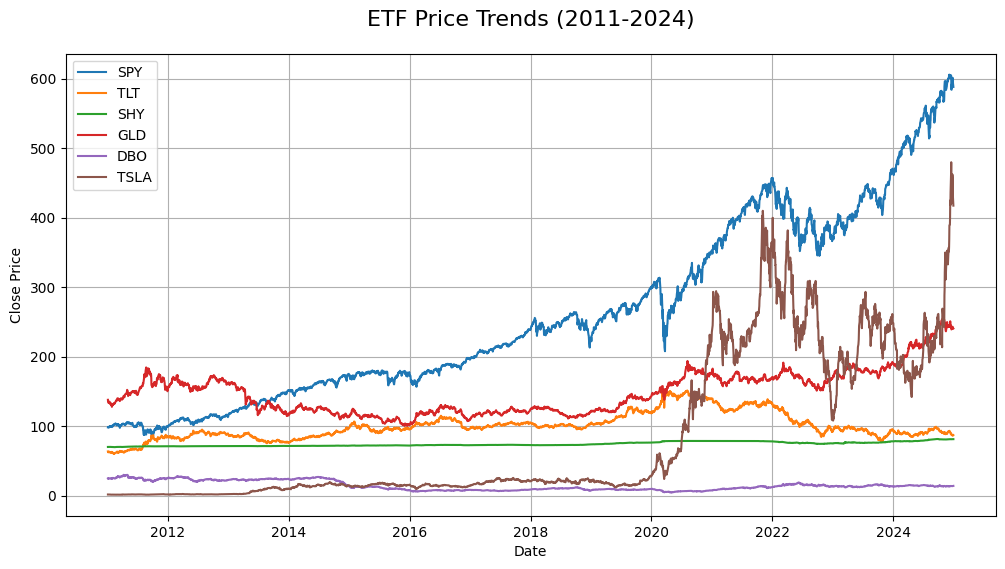

In [4]:
# Display summary statistics
print("Summary Statistics:")
print(df.describe())

# Plot price trends
plt.figure(figsize=(12, 6))
for etf in ETFs:
    plt.plot(df.index, df[etf], label=etf)
plt.title("ETF Price Trends (2011-2024)",fontsize=16, pad=20 )
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid()
plt.show()


In [5]:
# Compute daily returns
daily_returns = df.pct_change().dropna()
daily_returns.head()

Ticker,DBO,GLD,SHY,SPY,TLT,TSLA
Date,,,,,,
2011-01-04,-0.016561,-0.023551,-0.000238,-0.000551,0.001176,0.001878
2011-01-05,0.013973,-0.002820,-0.001787,0.005198,-0.022028,0.005999
2011-01-06,-0.015194,-0.004019,0.001075,-0.001958,0.004375,0.039135
2011-01-07,-0.006817,-0.001868,0.001430,-0.001963,0.005334,0.012912
2011-01-10,0.017702,0.004042,0.000476,-0.001258,0.005414,0.007436


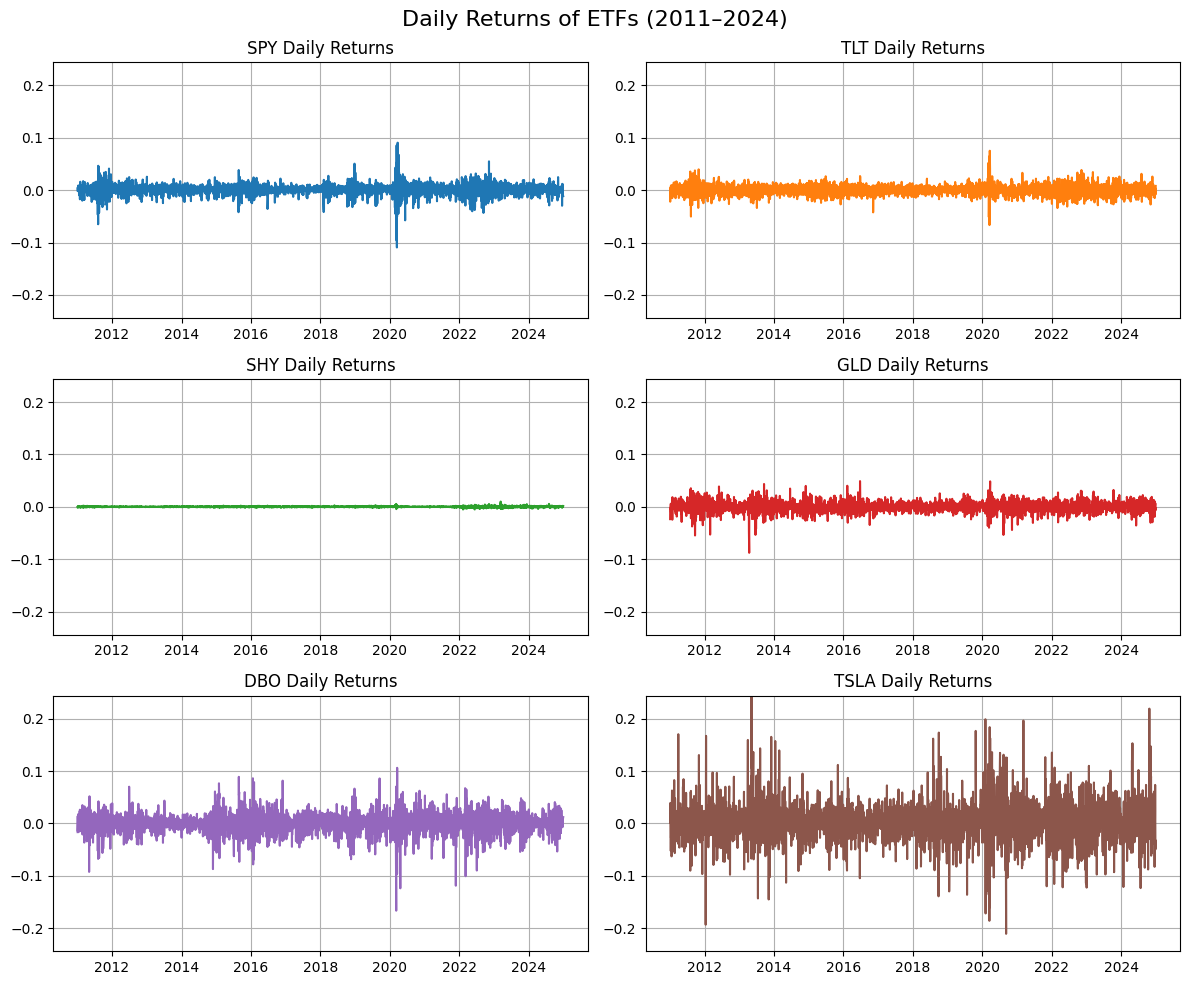

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()  # Flatten into a 1D array for easier iteration

# Get the maximum values of returns, to scale the y axis properly
global_min = daily_returns.min().min()
global_max = daily_returns.max().max()

# Abs max to get y-limits symmetric to zero
max_abs_value = max(abs(global_min), abs(global_max))

# Get some nice colors
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, etf in enumerate(ETFs):
    # Get the nice colors from the usual color cyle to match the price chart
    color = color_cycle[i % len(color_cycle)]

    axes[i].plot(daily_returns.index, daily_returns[etf], label=etf, color=color)
    axes[i].set_title(f"{etf} Daily Returns")
    axes[i].set_ylim(-max_abs_value, max_abs_value)
    axes[i].grid(True)

fig.suptitle("Daily Returns of ETFs (2011–2024)", fontsize=16)

plt.tight_layout()
plt.show()

## Correlation heatmap on daily returns - unordered



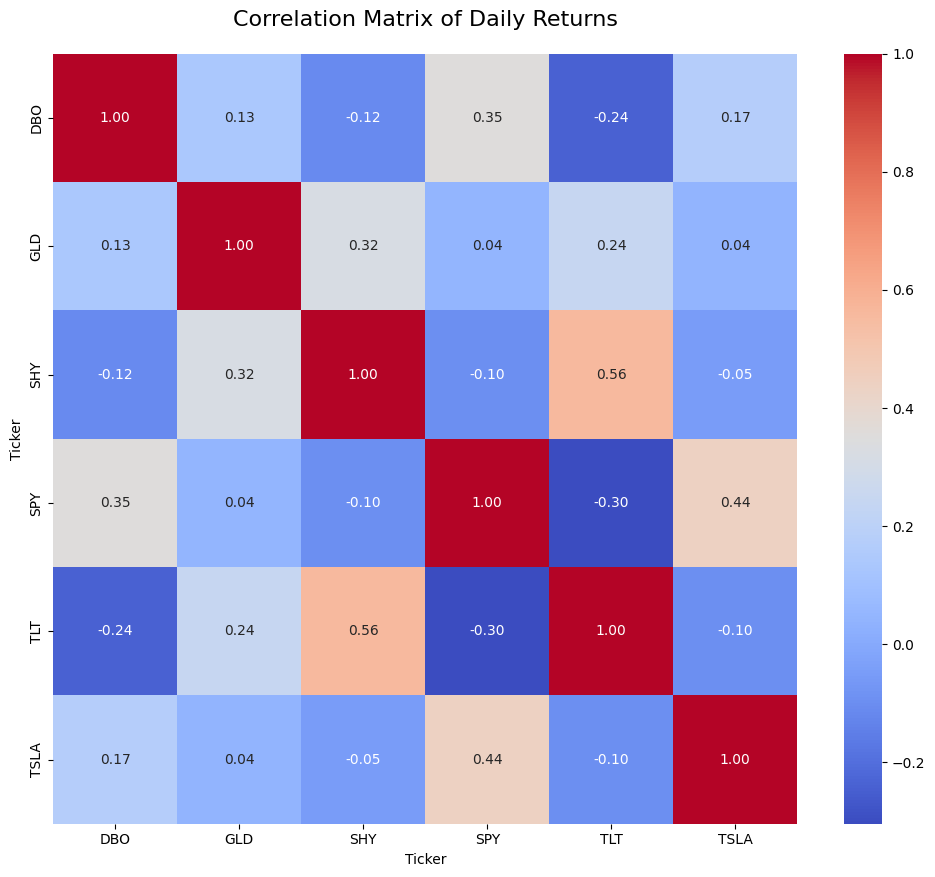

In [7]:
# Correlation matrix
correlation_matrix = daily_returns.corr()

# Display correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Daily Returns", pad=20, fontsize=16)
plt.show()

## Correlation heatmap on daily returns with clustering for better visibility

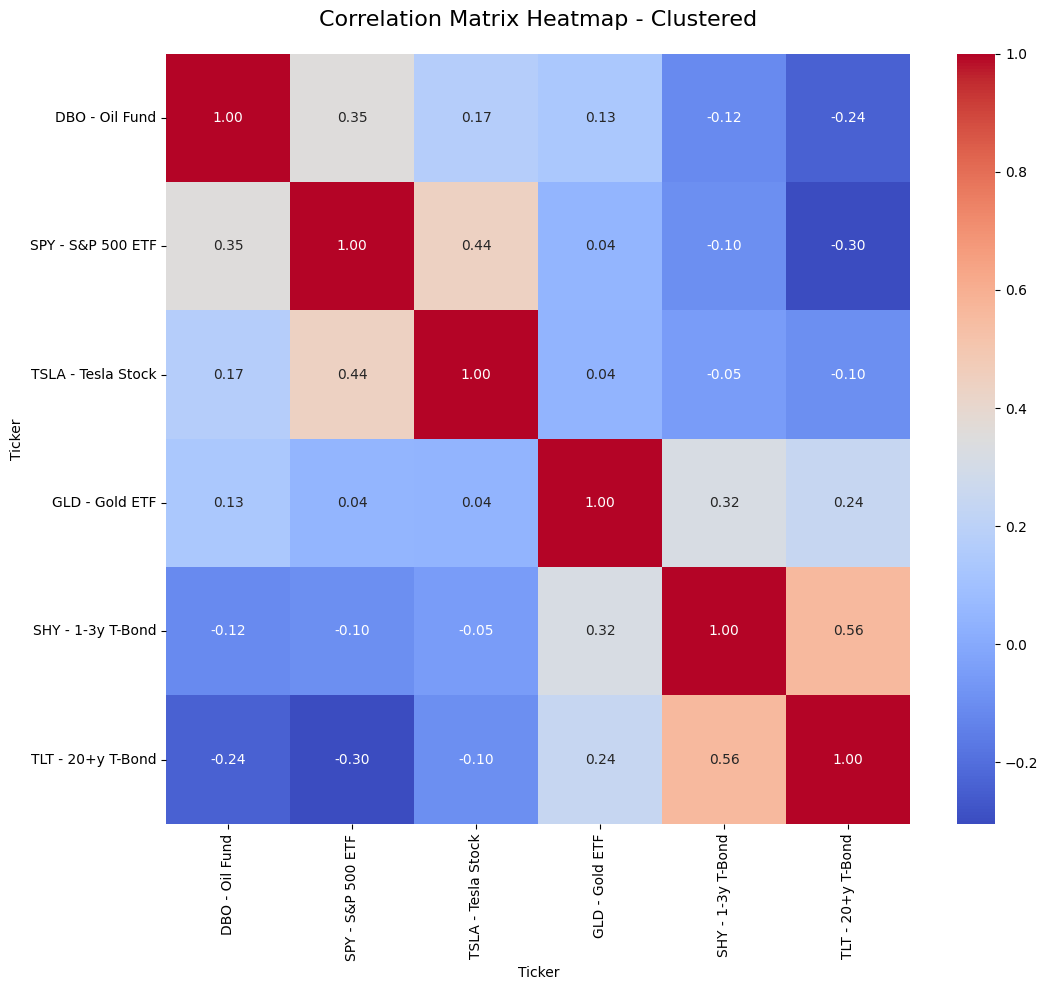

In [218]:
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list

rename_dict = {
    "GLD" : "GLD - Gold ETF",
    "SPY" : "SPY - S&P 500 ETF",
    "SHY" : "SHY - 1-3y T-Bond",
    "TLT" : "TLT - 20+y T-Bond",
    "DBO" : "DBO - Oil Fund",
    "TSLA": "TSLA - Tesla Stock",
}

# Compute linkage matrix
linkage_matrix = linkage(1 - correlation_matrix, method='average')

# Get the order of the leaves
dendro = dendrogram(linkage_matrix, no_plot=True)
dendro_order = dendro['leaves']
sorted_tickers = [correlation_matrix.index[i] for i in dendro_order]



# Reorder the correlation matrix
sorted_correlation_matrix_clustering = correlation_matrix.loc[sorted_tickers, sorted_tickers]

sorted_correlation_matrix_clustering = sorted_correlation_matrix_clustering.rename(index=rename_dict, columns=rename_dict)

# Plot the heatmap
plt.figure(figsize=(12, 10))
ax = sns.heatmap(sorted_correlation_matrix_clustering, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap - Clustered', pad=20, fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()

## Covariance

### Covariance on daily returns - sorted representation

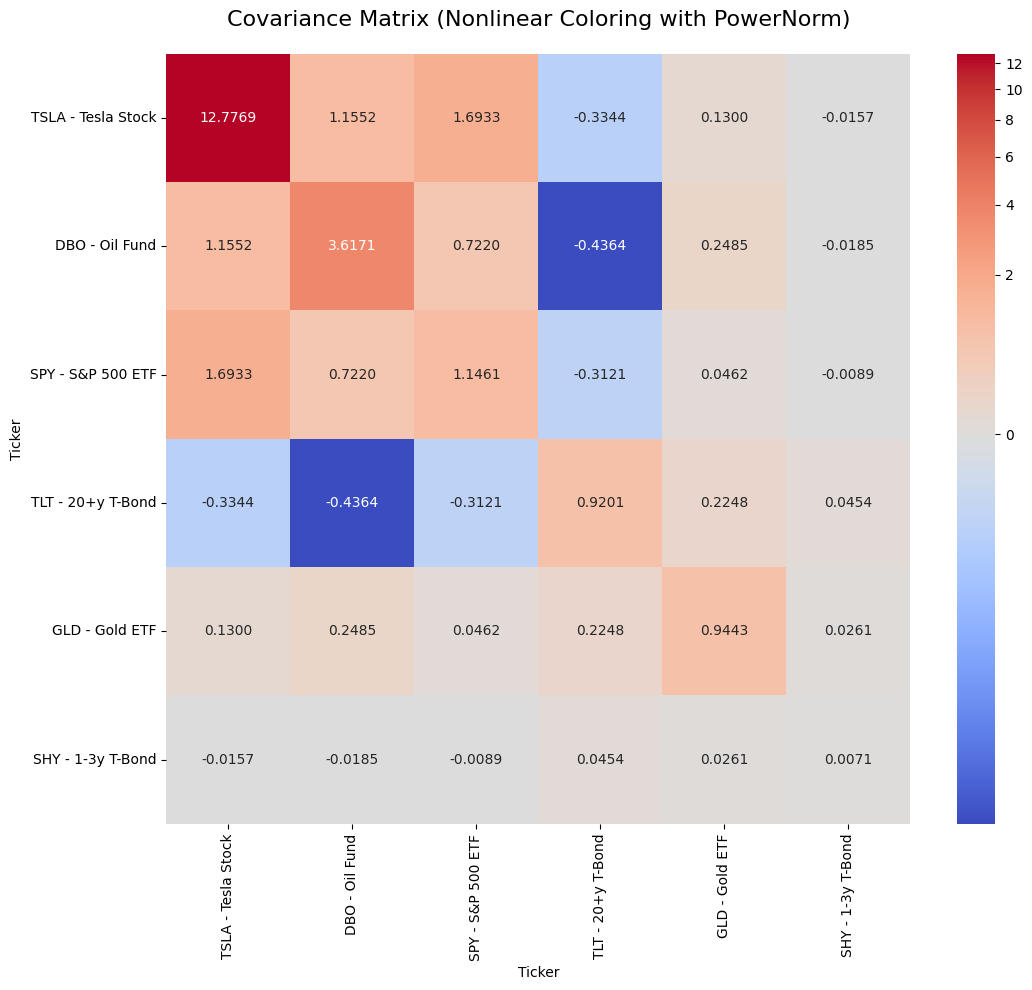

In [219]:
from matplotlib.colors import LogNorm, PowerNorm

daily_returns_percent = daily_returns * 100
cov_matrix_daily_returns = daily_returns_percent.cov()


# Compute linkage matrix
linkage_matrix = linkage(1 - cov_matrix_daily_returns, method='average')

# Get the order of the leaves
dendro = dendrogram(linkage_matrix, no_plot=True)
dendro_order = dendro['leaves']
sorted_tickers = [cov_matrix_daily_returns.index[i] for i in dendro_order]

# Reorder the correlation matrix
sorted_cov_matrix_clustering = cov_matrix_daily_returns.loc[sorted_tickers, sorted_tickers]
sorted_cov_matrix_clustering = sorted_cov_matrix_clustering.rename(index=rename_dict, columns=rename_dict)


plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    sorted_cov_matrix_clustering,
    annot=True,
    cmap='coolwarm',
    fmt=".4f",
    norm=PowerNorm(gamma=0.2, vmin=sorted_cov_matrix_clustering.min().min(), vmax=sorted_cov_matrix_clustering.max().max())
)
plt.title("Covariance Matrix (Nonlinear Coloring with PowerNorm)", pad=20, fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()

### Checking for a better visual representation of covariance - PowerNorm gamma values

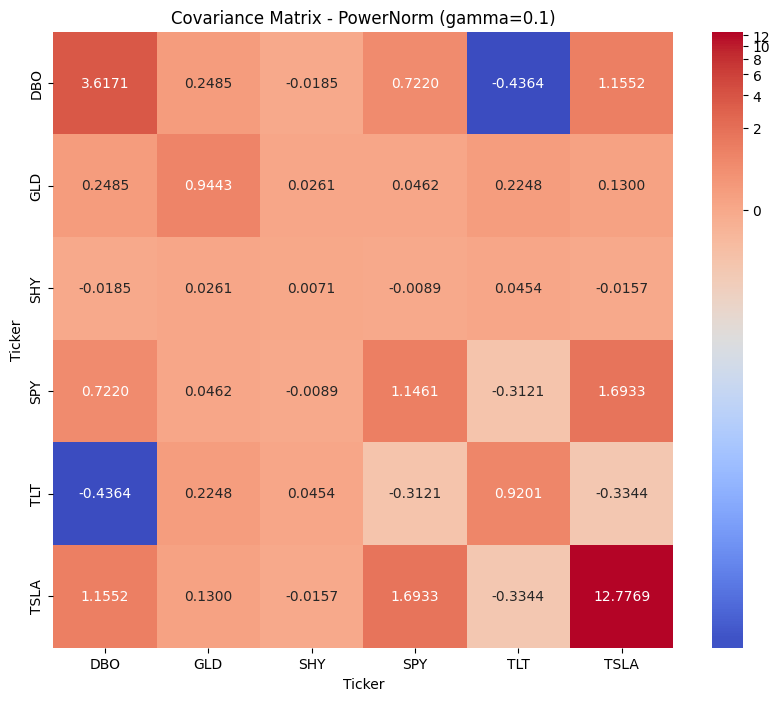

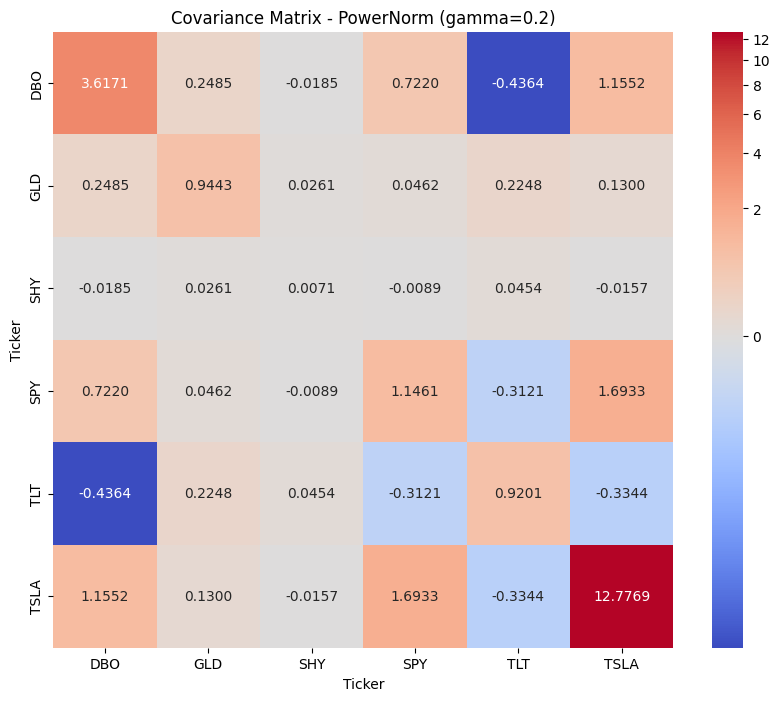

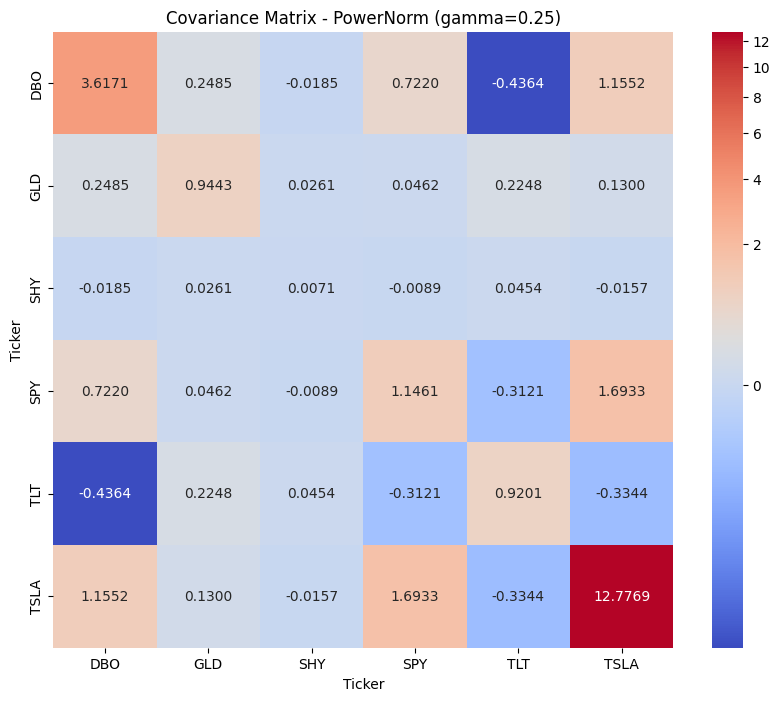

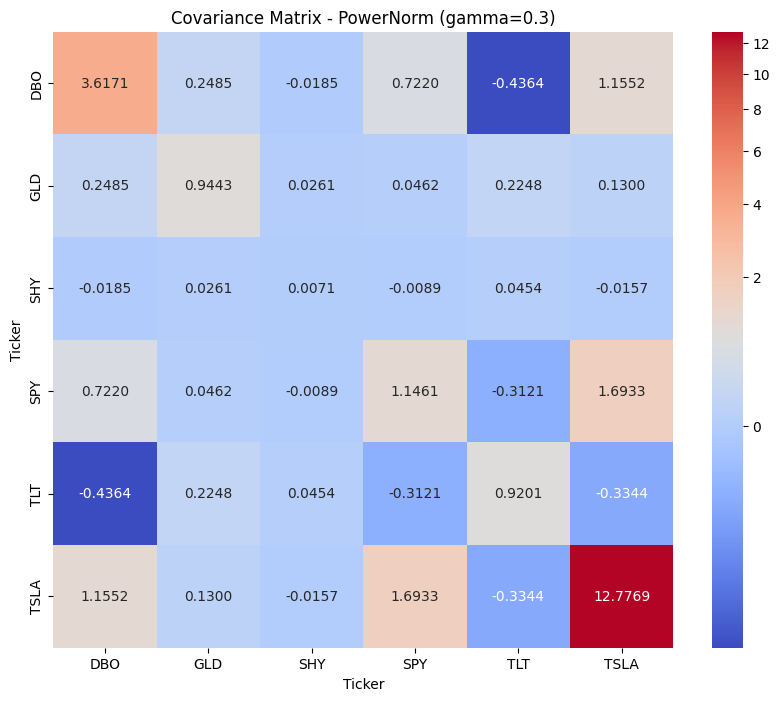

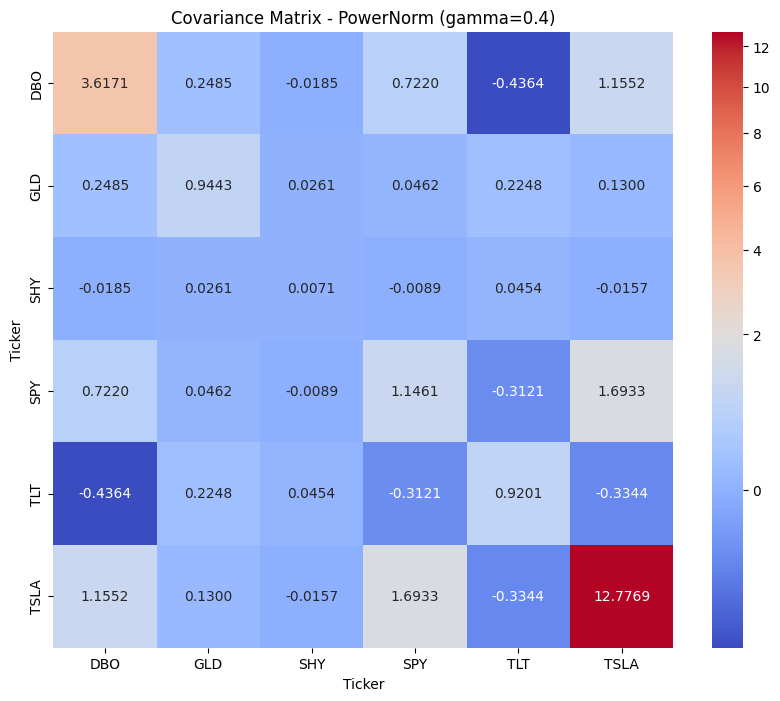

In [220]:
gamma_values = [0.1, 0.2, 0.25, 0.3, 0.4]

for gamma in gamma_values:
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cov_matrix_daily_returns,
        annot=True,
        cmap='coolwarm',
        fmt=".4f",
        norm=PowerNorm(gamma=gamma, vmin=cov_matrix_daily_returns.min().min(), vmax=cov_matrix_daily_returns.max().max())
    )
    plt.title(f"Covariance Matrix - PowerNorm (gamma={gamma})")
    plt.show()

## Checking normality of the daily returns

### Checking normality visually

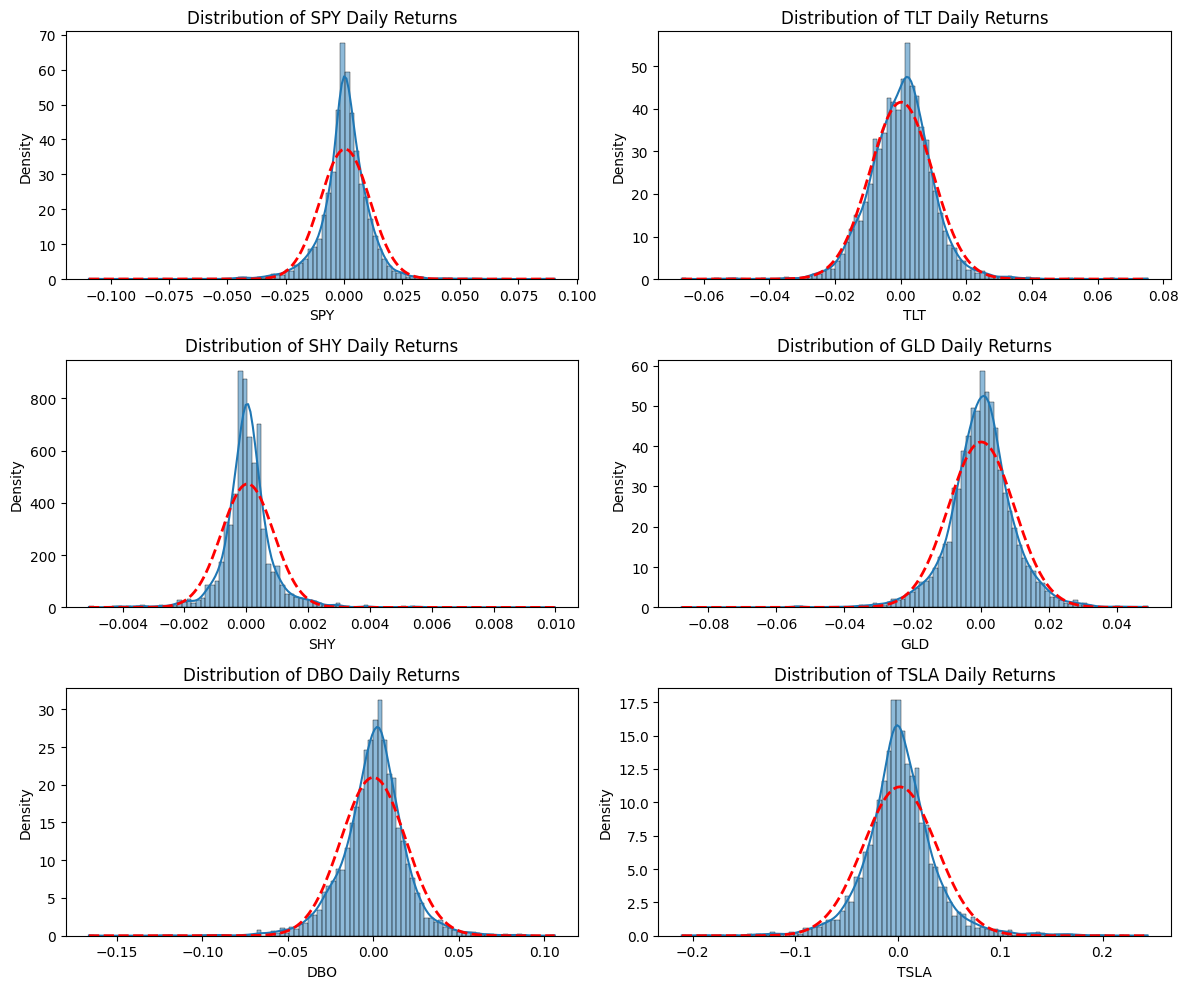

In [11]:
from scipy.stats import norm

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()  # Flatten into a 1D array for easier iteration

for i, etf in enumerate(ETFs):
    sns.histplot(data=daily_returns[etf], bins=100, stat="density", kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {etf} Daily Returns")

    # Calculate mean and std
    mu = daily_returns[etf].mean()
    sigma = daily_returns[etf].std()

    x_vals = np.linspace(daily_returns[etf].min(), daily_returns[etf].max(), 200)
    pdf = norm.pdf(x_vals, mu, sigma)

    # Plot the normal curve
    axes[i].plot(x_vals, pdf, "r--", linewidth=2, label="Normal PDF")



plt.tight_layout()
plt.show()

### Checking normality of the daily return distribution - numerical representation of skewness and kurtosis

In [12]:
for etf in ETFs:
    print(f"Skewness and kurtosis for the daily returns on {etf}:")
    print(f"Skewness: {daily_returns[etf].skew():.2f}")
    print(f"Kurtosis: {daily_returns[etf].kurtosis():.2f}")

Skewness and kurtosis for the daily returns on SPY:
Skewness: -0.55
Kurtosis: 11.54
Skewness and kurtosis for the daily returns on TLT:
Skewness: 0.07
Kurtosis: 3.81
Skewness and kurtosis for the daily returns on SHY:
Skewness: 0.83
Kurtosis: 12.74
Skewness and kurtosis for the daily returns on GLD:
Skewness: -0.41
Kurtosis: 4.66
Skewness and kurtosis for the daily returns on DBO:
Skewness: -0.51
Kurtosis: 4.86
Skewness and kurtosis for the daily returns on TSLA:
Skewness: 0.39
Kurtosis: 4.91


### Checking normality of the daily return distribution - Shapiro-Wilk and Kolgomorov-Smirnov

In [165]:
from scipy.stats import shapiro, kstest, norm

for etf in ETFs:
    # Shapiro-Wilk Test (for small sample sizes, n < 5000)
    shapiro_stat, shapiro_p = shapiro(daily_returns[etf])

    # Kolmogorov-Smirnov Test (for larger datasets)
    ks_stat, ks_p = kstest(daily_returns[etf], 'norm', args=(daily_returns[etf].mean(), daily_returns[etf].std()))

    # Print results
    # print(f"Shapiro-Wilk Test: Statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
    # print(f"Kolmogorov-Smirnov Test: Statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

    # Interpretation
    if shapiro_p < 0.05:
        print(f"{etf} NOT follows a normal distribution according Shapiro-Wilk test.")
    else:
        print(f"{etf} may follow a normal distribution according to Shapiro-Wilk test.")

    if ks_p < 0.05:
        print(f"{etf} NOT follows a normal distribution according Kolmogorov-Smirnov test")
    else:
        print(f"{etf} may follow a normal distribution according to Kolmogorov-Smirnov test.")

SPY NOT follows a normal distribution according Shapiro-Wilk test.
SPY NOT follows a normal distribution according Kolmogorov-Smirnov test
TLT NOT follows a normal distribution according Shapiro-Wilk test.
TLT NOT follows a normal distribution according Kolmogorov-Smirnov test
SHY NOT follows a normal distribution according Shapiro-Wilk test.
SHY NOT follows a normal distribution according Kolmogorov-Smirnov test
GLD NOT follows a normal distribution according Shapiro-Wilk test.
GLD NOT follows a normal distribution according Kolmogorov-Smirnov test
DBO NOT follows a normal distribution according Shapiro-Wilk test.
DBO NOT follows a normal distribution according Kolmogorov-Smirnov test
TSLA NOT follows a normal distribution according Shapiro-Wilk test.
TSLA NOT follows a normal distribution according Kolmogorov-Smirnov test


## Checking stationarity

### Stationarity of the close price time series

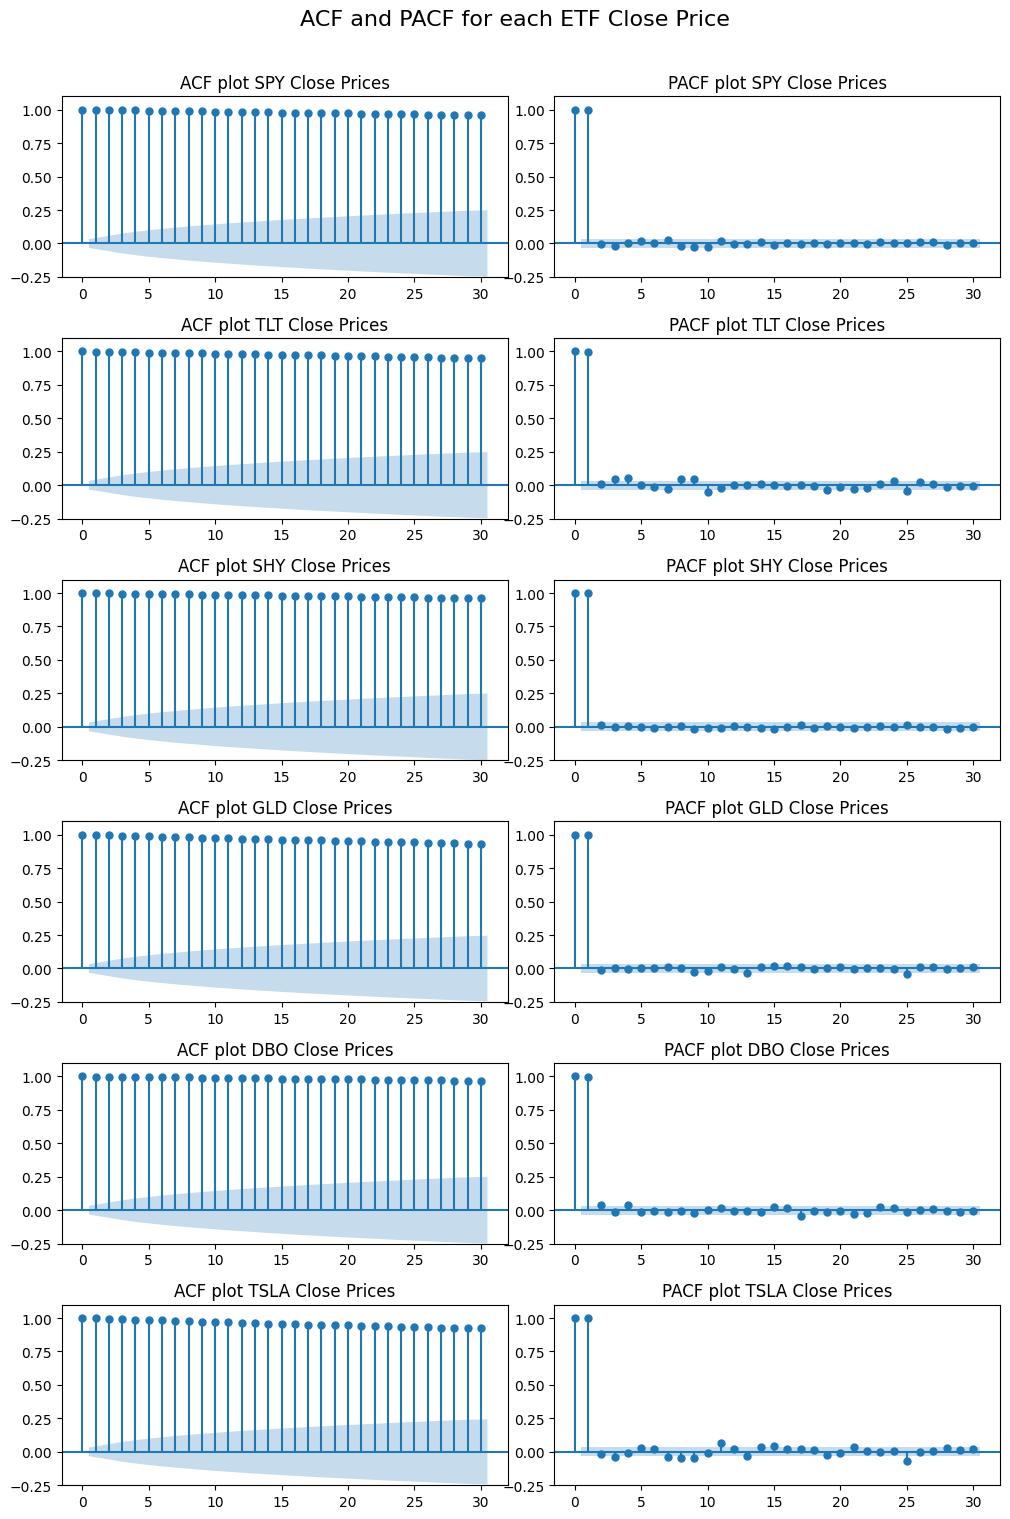

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(10, 15))
fig.suptitle("ACF and PACF for each ETF Close Price", fontsize=16, y=1.01)
axes = axes.reshape((6, 2))  # 2D array of Axes (5 rows × 2 cols)

for i, etf in enumerate(ETFs):
    # Plot ACF in the first column
    plot_acf(df[etf], ax=axes[i, 0], lags=30, alpha=0.05, title=f"ACF plot {etf} Close Prices")

    axes[i][0].set_ylim(-0.25, 1.1)  # Shift the plot a bit down
    # axes[i].set_title(f"ACF of {etf} Close prices")


    # Plot PACF in the second column
    plot_pacf(df[etf], ax=axes[i, 1], lags=30, alpha=0.05, title=f"PACF plot {etf} Close Prices")
    axes[i][1].set_ylim(-0.25, 1.1)  # Shift the plot a bit down

    # axes[i+1].set_title(f"PACF of {etf} Close prices")

plt.tight_layout()
plt.show()


### Nurmerical analysis of stationarity of the close price time series

In [192]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings

# Stationarity Tests
def adf_test(series, asset_name):
    result = adfuller(series, autolag='AIC')
    if result[1] < 0.05:
        print(f"{asset_name} YES stationary accoriding to ADF (Reject H0)")
    else:
        print(f"{asset_name} time series is non-stationary (Fail to reject H0)")
    print(f"ADF Stat: {result[0]:.4f}, p-value: {result[1]:.4f}")

def kpss_test(series, asset_name):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)  # 👈 suppress only this warning
        result = kpss(series, regression="c", nlags="auto")

    if result[1] > 0.05:
        print(f"{asset_name} YES stationary according to KPSS (Fail to reject H0)")
    else:
        print(f"{asset_name} time series is non-stationary (Reject H0)")
    print(f"KPSS Stat: {result[0]:.4f}, p-value: {result[1]:.4f}")

for etf in ETFs:
    adf_test(df[etf], etf)
    kpss_test(df[etf], etf)
    print("\n")

SPY time series is non-stationary (Fail to reject H0)
ADF Stat: 1.7802, p-value: 0.9983
SPY time series is non-stationary (Reject H0)
KPSS Stat: 8.4642, p-value: 0.0100


TLT time series is non-stationary (Fail to reject H0)
ADF Stat: -2.1770, p-value: 0.2147
TLT time series is non-stationary (Reject H0)
KPSS Stat: 3.5782, p-value: 0.0100


SHY time series is non-stationary (Fail to reject H0)
ADF Stat: 0.1557, p-value: 0.9697
SHY time series is non-stationary (Reject H0)
KPSS Stat: 7.6425, p-value: 0.0100


GLD time series is non-stationary (Fail to reject H0)
ADF Stat: 0.0722, p-value: 0.9641
GLD time series is non-stationary (Reject H0)
KPSS Stat: 4.3239, p-value: 0.0100


DBO time series is non-stationary (Fail to reject H0)
ADF Stat: -1.5995, p-value: 0.4839
DBO time series is non-stationary (Reject H0)
KPSS Stat: 4.2100, p-value: 0.0100


TSLA time series is non-stationary (Fail to reject H0)
ADF Stat: -0.0824, p-value: 0.9512
TSLA time series is non-stationary (Reject H0)
KPSS S

### Stationarity test of the relative differenced (daily return) timeseries.

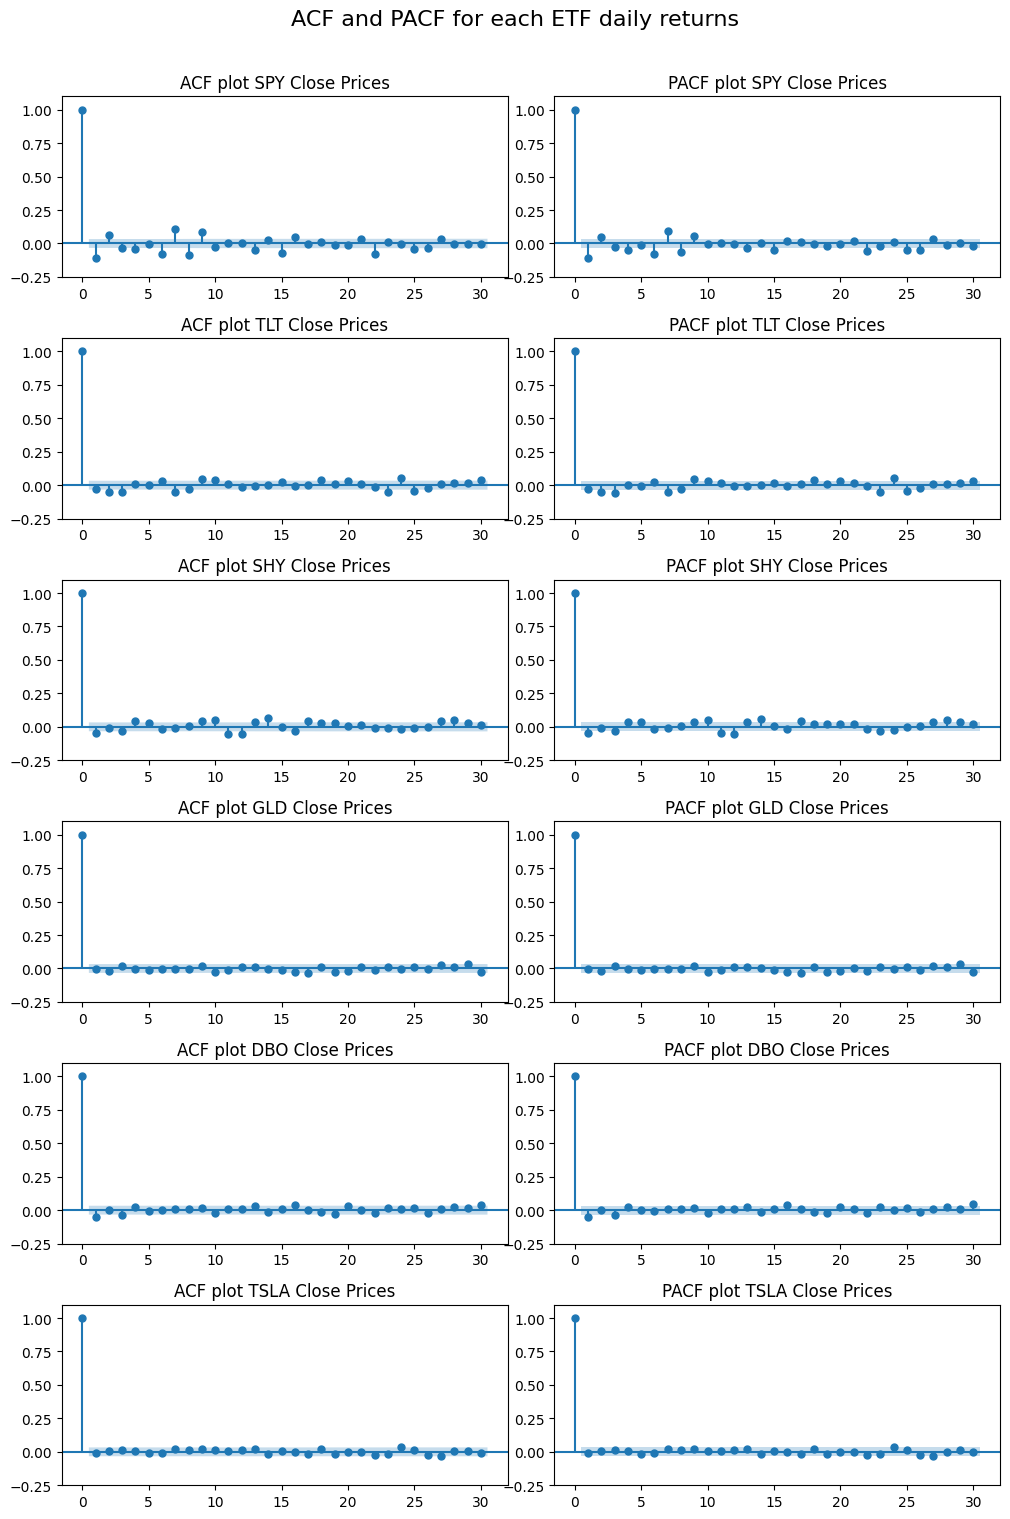

In [14]:
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(10, 15))
fig.suptitle("ACF and PACF for each ETF daily returns", fontsize=16, y=1.01)
axes = axes.reshape((6, 2))  # 2D array of Axes (5 rows × 2 cols)

for i, etf in enumerate(ETFs):
    # Plot ACF in the first column
    plot_acf(daily_returns[etf], ax=axes[i, 0], lags=30, alpha=0.05, title=f"ACF plot {etf} Close Prices")

    axes[i][0].set_ylim(-0.25, 1.1)  # Shift the plot a bit down
    # axes[i].set_title(f"ACF of {etf} Close prices")


    # Plot PACF in the second column
    plot_pacf(daily_returns[etf], ax=axes[i, 1], lags=30, alpha=0.05, title=f"PACF plot {etf} Close Prices")
    axes[i][1].set_ylim(-0.25, 1.1)  # Shift the plot a bit down

    # axes[i+1].set_title(f"PACF of {etf} Close prices")

plt.tight_layout()
plt.show()

### Numerical examination of the relative differenced (daily return) time series

In [193]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings

# Stationarity Tests
def adf_test(series, asset_name):
    result = adfuller(series, autolag='AIC')
    if result[1] < 0.05:
        print(f"{asset_name} YES stationary accoriding to ADF (Reject H0)")
    else:
        print(f"{asset_name} time series is non-stationary (Fail to reject H0)")
    print(f"ADF Stat: {result[0]:.4f}, p-value: {result[1]:.4f}")

def kpss_test(series, asset_name):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)  # 👈 suppress only this warning
        result = kpss(series, regression="c", nlags="auto")

    if result[1] > 0.05:
        print(f"{asset_name} YES stationary according to KPSS (Fail to reject H0)")
    else:
        print(f"{asset_name} time series is non-stationary (Reject H0)")
    print(f"KPSS Stat: {result[0]:.4f}, p-value: {result[1]:.4f}")

for etf in ETFs:
    adf_test(daily_returns[etf], etf)
    kpss_test(daily_returns[etf], etf)
    print("\n")

SPY YES stationary accoriding to ADF (Reject H0)
ADF Stat: -12.9815, p-value: 0.0000
SPY YES stationary according to KPSS (Fail to reject H0)
KPSS Stat: 0.0329, p-value: 0.1000


TLT YES stationary accoriding to ADF (Reject H0)
ADF Stat: -11.2196, p-value: 0.0000
TLT YES stationary according to KPSS (Fail to reject H0)
KPSS Stat: 0.3680, p-value: 0.0910


SHY YES stationary accoriding to ADF (Reject H0)
ADF Stat: -8.7168, p-value: 0.0000
SHY YES stationary according to KPSS (Fail to reject H0)
KPSS Stat: 0.2783, p-value: 0.1000


GLD YES stationary accoriding to ADF (Reject H0)
ADF Stat: -59.4565, p-value: 0.0000
GLD YES stationary according to KPSS (Fail to reject H0)
KPSS Stat: 0.2380, p-value: 0.1000


DBO YES stationary accoriding to ADF (Reject H0)
ADF Stat: -30.0981, p-value: 0.0000
DBO YES stationary according to KPSS (Fail to reject H0)
KPSS Stat: 0.2889, p-value: 0.1000


TSLA YES stationary accoriding to ADF (Reject H0)
ADF Stat: -59.7326, p-value: 0.0000
TSLA YES stationary 

## Seasonal decomposition

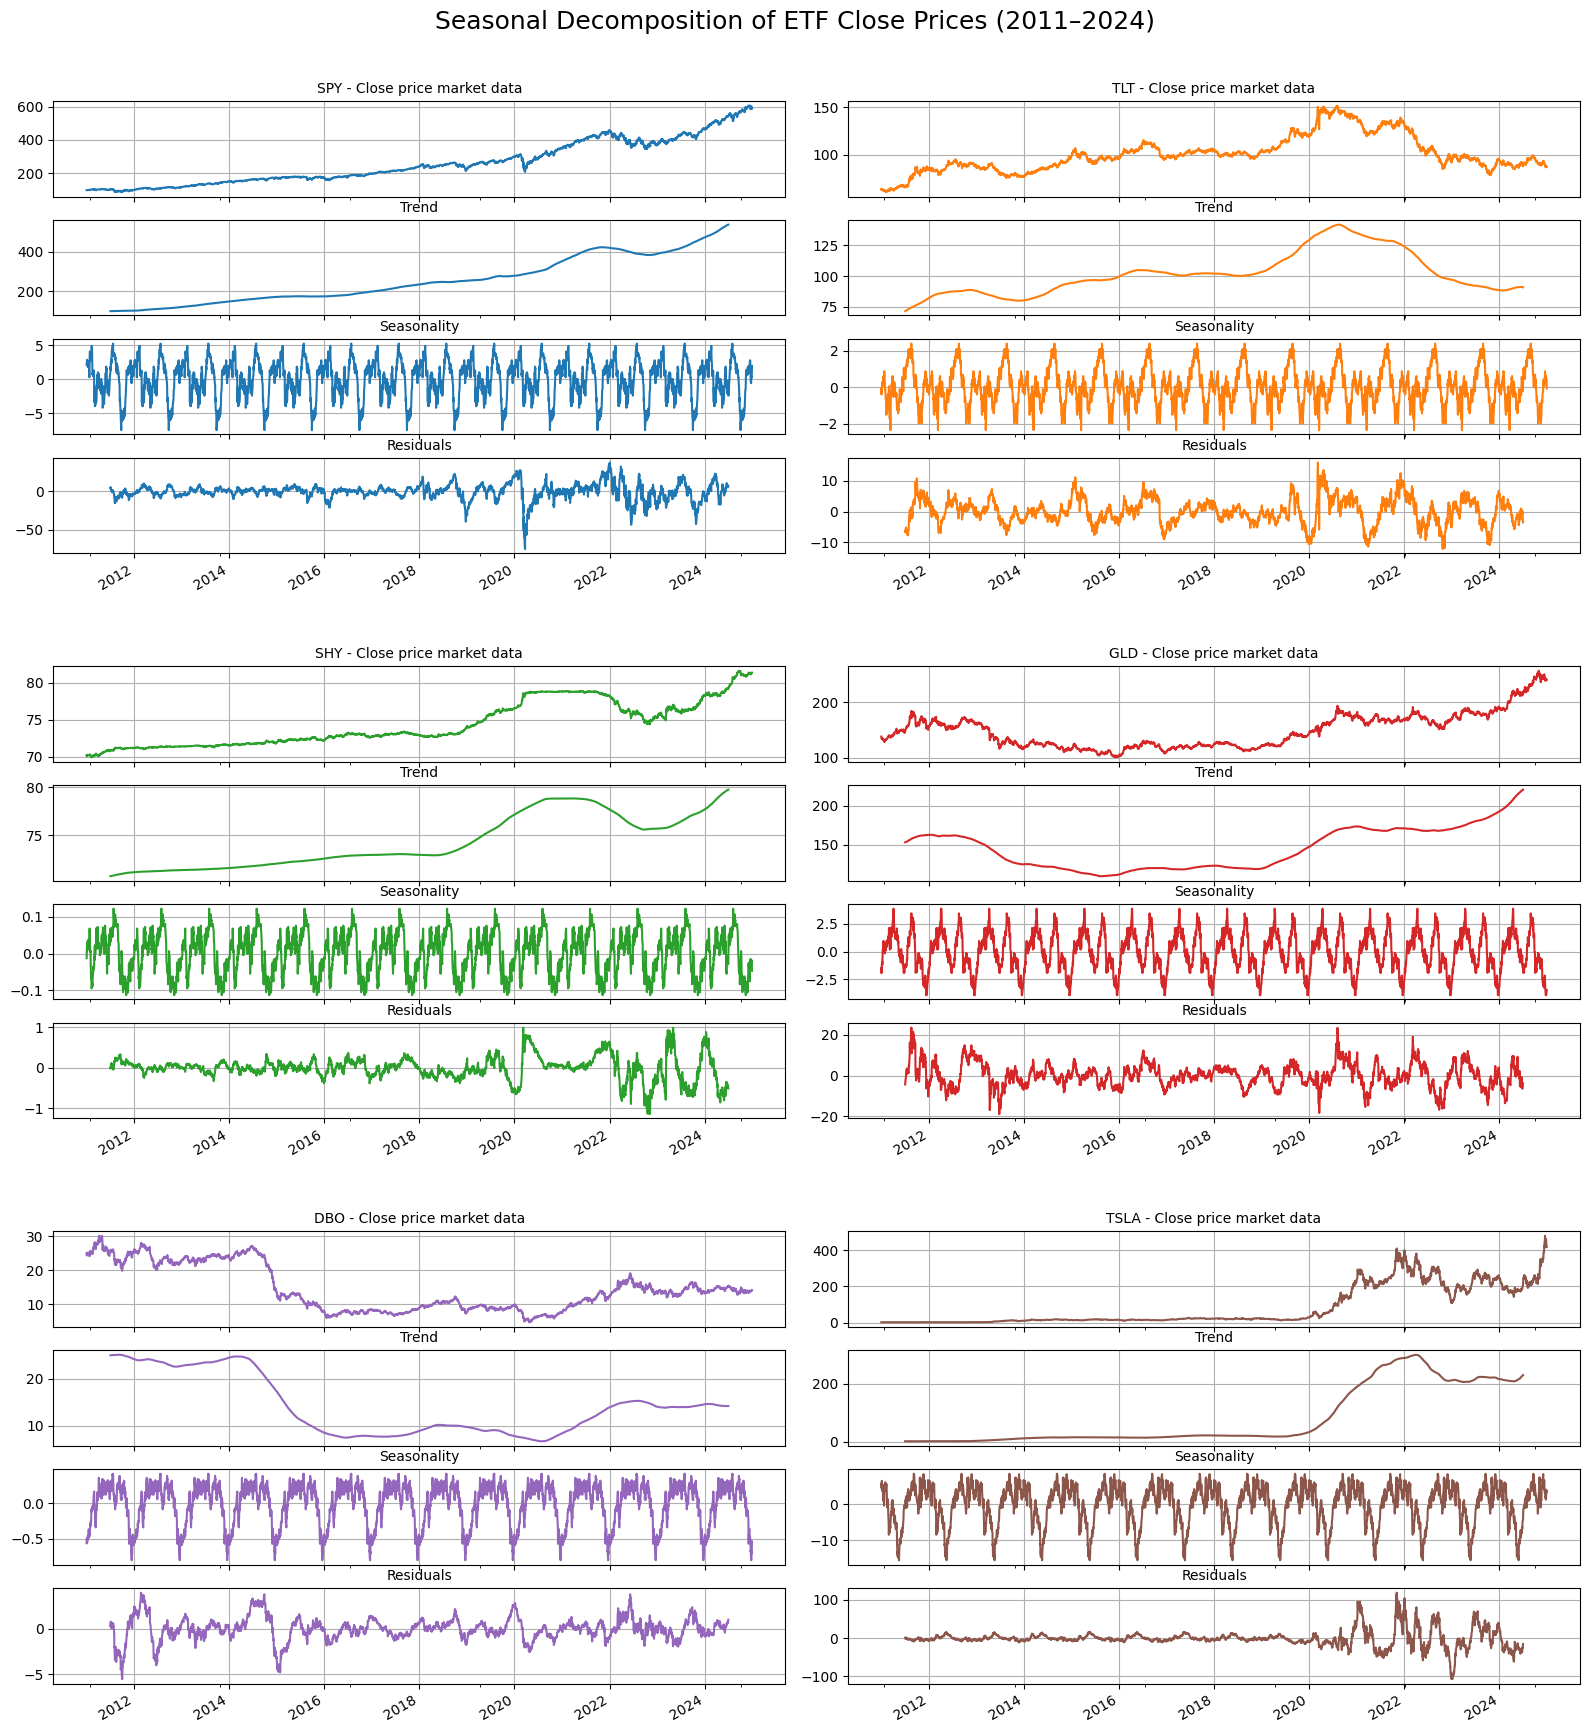

In [158]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from statsmodels.tsa.seasonal import seasonal_decompose

ETFs = ["SPY", "TLT", "SHY", "GLD", "DBO", "TSLA"]  # example list
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Create the main figure with 3 rows and 2 columns
fig = plt.figure(figsize=(16, 18))
fig.suptitle("Seasonal Decomposition of ETF Close Prices (2011–2024)", fontsize=18, y=0.96)

# Define the main grid (3x2) using GridSpec
gs = GridSpec(3, 2, figure=fig)

for i, etf in enumerate(ETFs):
    row = i // 2
    col = i % 2
    color = color_cycle[i % len(color_cycle)]

    # Decompose the time series
    decompose = seasonal_decompose(df[etf], model='additive', period=252)

    # Subdivide each grid cell into 4 vertical plots
    inner_gs = GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[row, col])

    # Titles for components
    components = [
        (decompose.observed, f"{etf} - Close price market data"),
        (decompose.trend, "Trend"),
        (decompose.seasonal, "Seasonality"),
        (decompose.resid, "Residuals")
    ]

    axes_subgroup = []  # collect subplots for sharing x-axis

    for j, (component, title) in enumerate(components):
        if j == 0:
            ax = fig.add_subplot(inner_gs[j])
        else:
            ax = fig.add_subplot(inner_gs[j], sharex=axes_subgroup[0])  # share x-axis with first one

        axes_subgroup.append(ax)

        component.plot(ax=ax, color=color)
        ax.set_title(title, fontsize=10)
        ax.grid(True)
        if j < 4:
            ax.set_xlabel("")  # Hide x-axis labels except last one

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
plt.subplots_adjust(hspace=0.25)  # Adjust vertical spacing
plt.show()


## Experimenting on detecting seasonality on other datasets

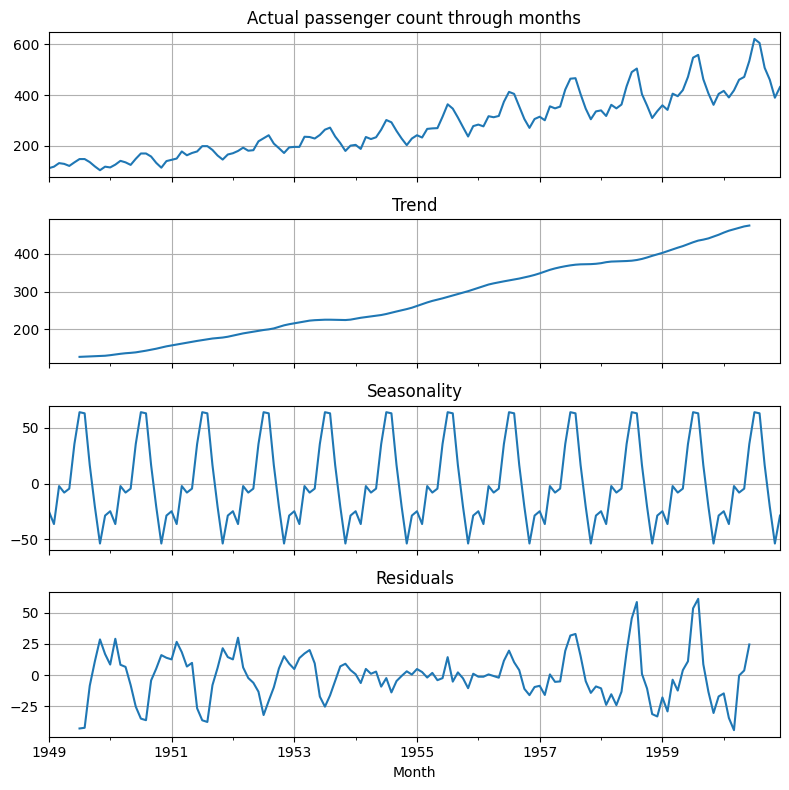

In [174]:
from statsmodels.tsa.seasonal import seasonal_decompose
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df_air = pd.read_csv(url)


# Convert to datetime and set as index
df_air['Month'] = pd.to_datetime(df_air['Month'])
df_air.set_index('Month', inplace=True)
df_air = df_air.rename(columns={'Passengers': 'AirPassengers'})


# Decompose air passanger count
decompose_air = seasonal_decompose(df_air['AirPassengers'], model='additive', period=12)  # 12months

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
decompose_air.observed.plot(ax=axes[0], title='Actual passenger count through months')
axes[0].grid(True)
decompose_air.trend.plot(ax=axes[1], title='Trend')
axes[1].grid(True)
decompose_air.seasonal.plot(ax=axes[2], title='Seasonality')
axes[2].grid(True)
decompose_air.resid.plot(ax=axes[3], title='Residuals')
axes[3].grid(True)
plt.tight_layout()
plt.show()

In [177]:
!pip install meteostat
# Example with Meteostat
from meteostat import Point, Daily
import datetime

start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2023, 1, 1)
location = Point(40.7128, -74.0060)  # New York City

meteo_data = Daily(location, start, end)
meteo_data = meteo_data.fetch()
print(type(meteo_data))

<class 'pandas.core.frame.DataFrame'>


In [178]:
meteo_data.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
time,,,,,,,,,,
2010-01-01,2.7,0.6,6.1,0.3,25.0,NaN,8.3,NaN,1011.9,NaN
2010-01-02,-2.9,-8.3,1.1,0.0,0.0,310.0,33.5,NaN,1005.5,NaN
2010-01-03,-6.4,-8.3,-3.9,0.0,0.0,298.0,35.3,NaN,1001.6,NaN
2010-01-04,-4.6,-7.2,-0.6,0.0,0.0,302.0,22.3,NaN,1006.4,NaN
2010-01-05,-3.3,-6.7,0.6,0.0,0.0,300.0,20.9,NaN,1007.0,NaN


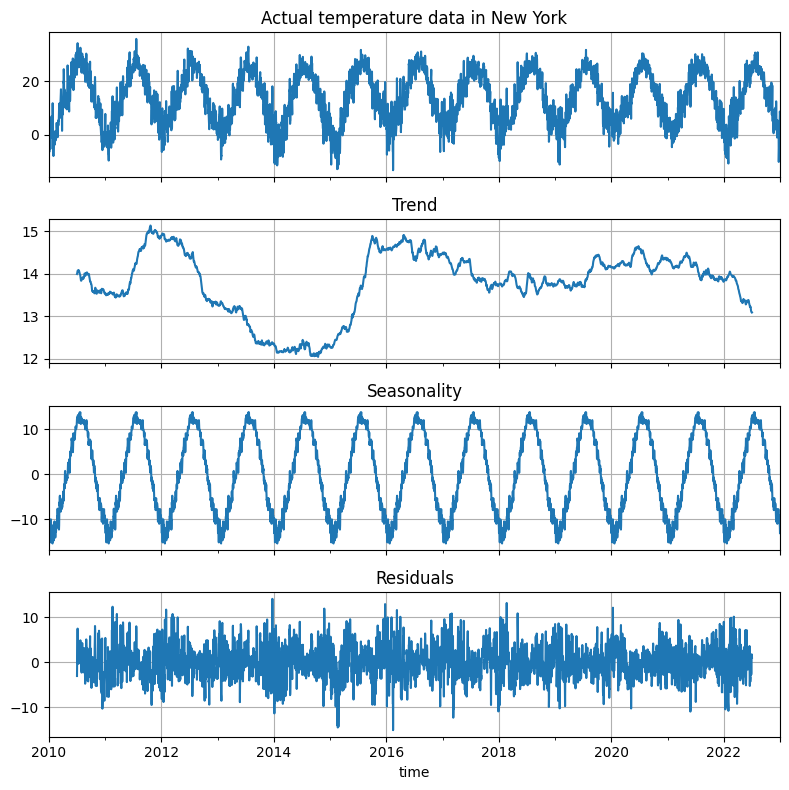

In [221]:
# Decompose temperature data
decompose_meteo_temp = seasonal_decompose(meteo_data['tavg'], model='additive', period=365)  # 365 days

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
decompose_meteo_temp.observed.plot(ax=axes[0], title='Actual temperature data in New York')
axes[0].grid(True)
decompose_meteo_temp.trend.plot(ax=axes[1], title='Trend')
axes[1].grid(True)
decompose_meteo_temp.seasonal.plot(ax=axes[2], title='Seasonality')
axes[2].grid(True)
decompose_meteo_temp.resid.plot(ax=axes[3], title='Residuals')
axes[3].grid(True)
plt.tight_layout()
plt.show()

# STEP 2

In [15]:

# Download SPY data from 2014 to 2022
vspy1 = yf.download('SPY', start='2010-01-01', end='2023-12-31')

# Use only the 'Adj Close' for simplicity
#vspy1 = vspy1[['Close']].rename(columns={'Close, SPY': 'Close'})
vspy1.columns = vspy1.columns.droplevel(1)
vspy1['Open_diff'] = vspy1['Open'].diff()
vspy1['Returns'] = vspy1['Close'].pct_change()
vspy1['Returns'] = vspy1['Returns']*100
vspy1['MA7'] = vspy1['Returns'].rolling(window=5).mean().pct_change()
vspy1['MA11'] = vspy1['Returns'].rolling(window=11).mean().pct_change()
vspy1['MA21'] = vspy1['Returns'].rolling(window=21).mean().pct_change()
vspy1['MA31'] = vspy1['Returns'].rolling(window=31).mean().pct_change()
vspy1['VA7'] = vspy1['Close'].rolling(window=5).std()
vspy1['VA11'] = vspy1['Close'].rolling(window=11).std()
vspy1['VA21'] = vspy1['Close'].rolling(window=21).std()
vspy1['VA31'] = vspy1['Close'].rolling(window=31).std()
vspy1['Volume_MA7'] = vspy1['Volume'].rolling(window=7).mean().pct_change()

returns = vspy1['Returns'].dropna()

garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# === Shift vspy1 to align with GARCH output ===
vspy1 = vspy1.iloc[1:].copy()  # Drop first row to match returns length


vspy1['GARCH_vol'] = garch_result.conditional_volatility

# === Optional: Forward fill any possible edge NaNs ===
vspy1['GARCH_vol'] = vspy1['GARCH_vol'].fillna(method='bfill')
vspy1['GARCH_vol']=vspy1['GARCH_vol']*100
# # === Add Volatility Regime Indicator ===
vspy1['Volatility_Regime'] = (vspy1['GARCH_vol'] > vspy1['GARCH_vol'].rolling(window=3).median()).astype(int)
vspy1['Volatility_Regime2'] = (vspy1['GARCH_vol'] > vspy1['GARCH_vol'].rolling(window=5).median()).astype(int)
vspy1['Volatility_Regime3'] =  (vspy1['GARCH_vol'] > vspy1['GARCH_vol'].rolling(window=10).median()).astype(int)
vspy1['Volatility_Regime4'] = (vspy1['GARCH_vol'] > vspy1['GARCH_vol'].rolling(window=15).median()).astype(int)
vspy1['Volatility_Regime5'] =  (vspy1['GARCH_vol'] > vspy1['GARCH_vol'].rolling(window=25).median()).astype(int)
# # One-hot encode the Volatility_Regime column
volatility_dummies = pd.get_dummies(vspy1['Volatility_Regime'], prefix='Volatility_Regime')
vspy1['Noise1'] = vspy1['Close'] - vspy1['Close'].rolling(window=3).mean()
vspy1['GARCH2'] = vspy1['GARCH_vol'].astype(int).rolling(window=5).max()
vspy1['GARCH3'] = vspy1['GARCH_vol'].astype(int).rolling(window=5).min()
vspy1['GARCH4'] = vspy1['GARCH_vol'].rolling(window=10).max()
vspy1['GARCH5'] = vspy1['GARCH_vol'].rolling(window=10).min()

# # Concatenate the one-hot columns back to the dataframe
vspy1 = pd.concat([vspy1, volatility_dummies], axis=1)

# === Define Volatility Regimes (4 Classes) ===
quantiles = vspy1['GARCH_vol'].quantile([0.1, 0.25, 0.5, 0.75,0.9])

def classify_volatility(vol):
    if vol <= quantiles[0.1]:
        return "Very Low"
    elif vol <= quantiles[0.25]:
        return "Low"
    elif vol <= quantiles[0.50]:
        return "Medium"
    elif vol <= quantiles[0.75]:
        return "High"
    elif vol <= quantiles[0.9]:
        return "Very High"
    else:
        return "Very Very High"

vspy1['Volatility_Regime'] = vspy1['GARCH_vol'].apply(classify_volatility)

# === One-Hot Encode the 4 Classes ===
volatility_dummies = pd.get_dummies(vspy1['Volatility_Regime'], prefix='Volatility_Regime')

# === Add One-Hot Columns to DataFrame ===
vspy1 = pd.concat([vspy1, volatility_dummies], axis=1)



# Drop the original 'Volatility_Regime' column if you don't need it anymore
vspy1 = vspy1.drop(columns=['Volatility_Regime'])
# === Add GARCH Residuals ===
vspy1['GARCH_residuals3'] = vspy1['Returns'].shift(3) - vspy1['GARCH_vol']
vspy1['GARCH_residuals10'] = vspy1['Returns'].shift(10) - vspy1['GARCH_vol']
vspy1['GARCH_residuals20'] = vspy1['Returns'].shift(20) - vspy1['GARCH_vol']
vspy1['GARCH_residuals30'] = vspy1['Returns'].shift(30) - vspy1['GARCH_vol']

# === Add Rolling Volatility (alternative to GARCH if you want) ===
vspy1['RollingVolatility_11d'] = vspy1['Returns'].rolling(window=11).std()
vspy1['RollingVolatility_21d'] = vspy1['Returns'].rolling(window=21).std()
vspy1['RollingVolatility_5d'] = vspy1['Returns'].rolling(window=5).std()
#del vspy1["Volume"]

vspy1['Return+25'] = vspy1['Close'].shift(-25) / vspy1['Close'] - 1

vspy1['Return+25'] = vspy1['Return+25']*100
vspy1['Return+25_Denoised']= vspy1['Return+25'].ewm(span=5, adjust=False).mean()
vspy1['Noise'] = vspy1['Return+25'] - vspy1['Return+25_Denoised']
#vshy1['Output'] = vshy1['Return+25_Denoised']
vspy1["Trend"] = vspy1['Return+25_Denoised']

vspy1=pd.DataFrame(vspy1)
# Create additional features

# Split into training, validation, and test
vtrainspy1 = vspy1.loc['2010-01-01':'2017-12-31']
vtestspy1 = vspy1.loc['2018-01-01':'2023-12-30']
vtestspy1=vtestspy1[:-25]
# Create Validation Set (20% of Training Data)
vval_size1 = int(0.2 * len(vtrainspy1))
vtrainspy_set1 = vtrainspy1.iloc[:-vval_size1]
vvalspy_set1 = vtrainspy1.iloc[-vval_size1:]

# Confirm Data Split
print ()
print(f"Training Set: {vtrainspy_set1.index.min()} to {vtrainspy_set1.index.max()}")
print(f"Validation Set: {vvalspy_set1.index.min()} to {vvalspy_set1.index.max()}")
print(f"Test Set: {vtestspy1.index.min()} to {vtestspy1.index.max()}")

[*********************100%***********************]  1 of 1 completed
<ipython-input-15-105fa8b6f6b3>:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vspy1['GARCH_vol'] = vspy1['GARCH_vol'].fillna(method='bfill')



Training Set: 2010-01-05 00:00:00 to 2016-05-26 00:00:00
Validation Set: 2016-05-27 00:00:00 to 2017-12-29 00:00:00
Test Set: 2018-01-02 00:00:00 to 2023-11-22 00:00:00


In [16]:
# Drop NaN values
vtrainspy_set1.dropna(inplace=True)
vvalspy_set1.dropna(inplace=True)
vtestspy1.dropna(inplace=True)
# Prepare features
featuresspy = ['Open', 'Open_diff','Returns', 'MA7', 'MA11','MA21', 'MA31',
            'VA7', 'VA11','VA21', 'VA31','GARCH_vol',
             'Volatility_Regime2', 'Volatility_Regime3', 'Volatility_Regime4','Volatility_Regime5',
            'Volatility_Regime_0','Volatility_Regime_1',
            'Noise1','GARCH2','GARCH3',
            'GARCH4','GARCH5',
            'GARCH_residuals10', 'GARCH_residuals3',
            'GARCH_residuals20','GARCH_residuals30',
            'RollingVolatility_5d','RollingVolatility_11d',
            'RollingVolatility_21d',
            'Volatility_Regime_Very Low',
            'Volatility_Regime_Low',
            'Volatility_Regime_Medium',
            'Volatility_Regime_High',
            'Volatility_Regime_Very High','Volatility_Regime_Very Very High'
            ]
targetspy = ["Trend","Noise"]

<ipython-input-16-fbbce8e53190>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vtrainspy_set1.dropna(inplace=True)
<ipython-input-16-fbbce8e53190>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vvalspy_set1.dropna(inplace=True)


In [17]:
nfeatspy3=vtrainspy_set1.shape[1]
nfeatspy3
window_size = 25  # How many daily prices do I want to incorporate in the input sequence for the network?

test_timespy = vtestspy1.index[window_size :]
test_timespy[:5]

DatetimeIndex(['2018-02-07', '2018-02-08', '2018-02-09', '2018-02-12',
               '2018-02-13'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [18]:
Xtrainspy, Xvalspy,Xtestspy = vtrainspy_set1.iloc[:, 0:nfeatspy3]-2, vvalspy_set1.iloc[:,0:nfeatspy3-2],vtestspy1.iloc[:,0:nfeatspy3-2]
ytrainspy, yvalspy, ytestspy = vtrainspy_set1.iloc[:, -2:nfeatspy3], vvalspy_set1.iloc[:,-3:nfeatspy3],vtestspy1.iloc[:,-3:nfeatspy3]
Xtrainspy = Xtrainspy.astype("float32")
Xvalspy = Xvalspy.astype("float32")
Xtestspy = Xtestspy.astype("float32")
ytrainspy = ytrainspy.astype("float32")
yvalspy = yvalspy.astype("float32")
ytestspy = ytestspy.astype("float32")


In [19]:
ytrainspy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1579 entries, 2010-02-19 to 2016-05-26
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Noise   1579 non-null   float32
 1   Trend   1579 non-null   float32
dtypes: float32(2)
memory usage: 24.7 KB


In [20]:
# Third, we proceed with scaling inputs to the model. Note how this is specially important now (compare to past tasks) because we are no longer dealing with returns, but with prices!
scaler_inputspy = MinMaxScaler(feature_range=(-1, 1))
scaler_inputspy.fit(Xtrainspy[featuresspy])
X_trainspy_scaled = scaler_inputspy.transform(Xtrainspy[featuresspy])
X_valspy_scaled =scaler_inputspy.transform(Xvalspy[featuresspy])
X_testspy_scaled = scaler_inputspy.transform(Xtestspy[featuresspy])

In [21]:
mean_retspy = np.mean(ytrainspy)

scaler_outputspy = MinMaxScaler(feature_range=(-1,1))
ytrainspy_reset = ytrainspy.reset_index(drop=True)
yvalspy_reset = yvalspy.reset_index(drop=True)
ytestspy_reset = ytestspy.reset_index(drop=True)
#ytrainsetspy = ytrainspy_reset.values.reshape(len(ytrainspy), 2)
#yvalsetspy = yvalspy_reset.values.reshape(len(yvalspy), 2)
#ytestsetspy = ytestspy_reset.values.reshape(len(ytestspy), 2)
scaler_outputspy.fit(ytrainspy_reset[targetspy])
y_trainspy_scaled = scaler_outputspy.transform(ytrainspy_reset[targetspy])
y_valspy_scaled = scaler_outputspy.transform(yvalspy_reset[targetspy])
y_testspy_scaled = scaler_outputspy.transform(ytestspy_reset[targetspy])

In [22]:
X_trainspy = []
y_trainspy = []
X_valspy=[]
y_valspy=[]
for i in range(window_size, y_trainspy_scaled.shape[0]):
    X_trainspy.append(X_trainspy_scaled[i - window_size : i, :])
    y_trainspy.append(y_trainspy_scaled[i])
for i in range(window_size, y_valspy_scaled.shape[0]):
    X_valspy.append(X_valspy_scaled[i - window_size : i, :])
    y_valspy.append(y_valspy_scaled[i])
X_trainspy, y_trainspy = np.array(X_trainspy), np.array(y_trainspy)
X_valspy, y_valspy = np.array(X_valspy), np.array(y_valspy)
print ()
print("Size of X vector in training:", X_trainspy.shape)
print("Size of Y vector in training:", y_trainspy.shape)
print ()
print("Size of X vector in Validation:", X_valspy.shape)
print("Size of Y vector in Validation:", y_valspy.shape)
X_testspy = []
y_testspy = y_testspy_scaled[window_size:]

for i in range(window_size, y_testspy_scaled.shape[0]):
    X_testspy.append(X_testspy_scaled[i - window_size : i, :])


X_testspy, y_testspy = np.array(X_testspy), np.array(y_testspy)
print("Size of X vector in test:", X_testspy.shape)
print("Size of Y vector in test:", y_testspy.shape)



Size of X vector in training: (1554, 25, 36)
Size of Y vector in training: (1554, 2)

Size of X vector in Validation: (377, 25, 36)
Size of Y vector in Validation: (377, 2)
Size of X vector in test: (1459, 25, 36)
Size of Y vector in test: (1459, 2)


In [23]:
def fluctuation_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # Difference between consecutive days (fluctuations)
    fluct_true = y_true[:, 1:] - y_true[:, :-1]
    fluct_pred = y_pred[:, 1:] - y_pred[:, :-1]

    # Penalize difference between actual and predicted fluctuations
    fluct_penalty = tf.reduce_mean(tf.square(fluct_true - fluct_pred))

    # Combine both losses
def build_advanced_model(window_size, num_features):
    inputs = Input(shape=(window_size, num_features))

    # 1️⃣ Local feature extraction (short-term fluctuations)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='relu')(inputs)

    # 2️⃣ Long-term memory (trend)
    x = LSTM(64, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
    # 3️⃣ Transformer-like Attention Block (for importance weighting)
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x, x)
    attn = Add()([x, attn])
    attn = LayerNormalization()(attn)

    # 4️⃣ More dense layers to learn complex mapping
    x = GlobalAveragePooling1D()(attn)
    x = Dense(128, activation='tanh')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='tanh')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='linear')(x)  # Predict 25-day return

    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=fluctuation_loss, metrics=['mae'])

    return model

# # Build and Compile
# modelspy = build_advanced_model(X_trainspy.shape[1],X_trainspy.shape[2])
# modelspy.summary()




In [24]:
def fluctuation_loss2(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # Difference between consecutive days (fluctuations)
    fluct_true = y_true[:, 1:] - y_true[:, :-1]
    fluct_pred = y_pred[:, 1:] - y_pred[:, :-1]

    # Penalize difference between actual and predicted fluctuations
    fluct_penalty = tf.reduce_mean(tf.square(fluct_true - fluct_pred))

    # Combine both losses

def build_advanced_model2(window_size, num_features):
    # Input layer
    inputs = Input(shape=(window_size, num_features))

    # Conv1D Layer
    x = Conv1D(filters=64, kernel_size=3, activation='tanh', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    # LSTM Layer
    x = LSTM(64, return_sequences=True)(x)
    x = LSTM(64, return_sequences=True)(x)

    # Attention Mechanism
    attention = Attention()([x, x])
    x = Add()([x, attention])
    x = LayerNormalization()(x)

    # 4️⃣ More dense layers to learn complex mapping

    # Flatten before fully connected layers
    x = LSTM(64)(x)

    x = Dense(128, activation='tanh')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='tanh')(x)
    x = Dropout(0.3)(x)

    # Three outputs
    trend_output = Dense(1, name='Trend_Output')(x)  # Denoised return
    noise_output = Dense(1, name='Noise_Output')(x)  # Random fluctuations
    #final_output = Add(name='Final_Return')([trend_output, noise_output])  # Sum of trend + noise

    # Define model with three outputs
    model = Model(inputs=inputs, outputs=[trend_output, noise_output])

    # Compile model
    model.compile(
        optimizer='adam',
        loss={'Noise_Output': 'mse','Trend_Output': 'mse', },
        loss_weights={'Noise_Output': 0.3,'Trend_Output': 0.5, }
    )

    return model

In [25]:

# Build and Compile
modelspy = build_advanced_model2(X_trainspy.shape[1],X_trainspy.shape[2])
modelspy.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 25, 36)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 25, 64)         │          6,976 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 25, 64)         │            256 │ conv1d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 25, 64)         │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 25, 32)         │          6,176 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 25, 32)         │            128 │ conv1d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 25, 32)         │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 25, 64)         │         24,832 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 25, 64)         │         33,024 │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention (Attention)     │ (None, 25, 64)         │              0 │ lstm_1[0][0],          │
│                           │                        │                │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 25, 64)         │              0 │ lstm_1[0][0],          │
│                           │                        │                │ attention[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 25, 64)         │            128 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_2 (LSTM)             │ (None, 64)             │         33,024 │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │          8,320 │ lstm_2[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 128)            │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │          8,256 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 64)             │              0 │ dense_1[0][0]          │
├──────────────────────

 Total params: 121,250 (473.63 KB)

 Trainable params: 121,058 (472.88 KB)

 Non-trainable params: 192 (768.00 B)

In [26]:
def custom_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    fluct_penalty = tf.reduce_mean(tf.square(tf.abs(y_true - y_pred) - tf.abs(y_true.shift(1) - y_true)))
    return mse + 0.5 * fluct_penalty
hp_lr = 1e-4
# modelspy.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr), loss="mean_absolute_error", metrics=["mean_absolute_error"]
# )

es = EarlyStopping(
    monitor="val_loss", mode="min", verbose=1, patience=25, restore_best_weights=True
)

In [27]:
X_trainspy.shape

(1554, 25, 36)

In [28]:
y_trainspy.shape

(1554, 2)

In [29]:
y_trainspy = np.array(y_trainspy)
y_valspy = np.array(y_valspy)
y_trainspy_split=[y_trainspy[:,0].reshape(-1,1),y_trainspy[:,1].reshape(-1,1)]
y_valspy_split=[y_valspy[:,0].reshape(-1,1),y_valspy[:,1].reshape(-1,1)]
# fit the models
historyspy=modelspy.fit(
    X_trainspy,
    y_trainspy_split,
    validation_data=(X_valspy, y_valspy_split),
    epochs=500,
    batch_size=64,
    verbose=1,
    callbacks=[es],
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 364ms/step - Noise_Output_loss: 0.2214 - Trend_Output_loss: 0.2571 - loss: 0.1951 - val_Noise_Output_loss: 0.0193 - val_Trend_Output_loss: 0.0331 - val_loss: 0.0219
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - Noise_Output_loss: 0.0938 - Trend_Output_loss: 0.1268 - loss: 0.0916 - val_Noise_Output_loss: 0.0083 - val_Trend_Output_loss: 0.0249 - val_loss: 0.0148
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - Noise_Output_loss: 0.0513 - Trend_Output_loss: 0.0861 - loss: 0.0585 - val_Noise_Output_loss: 0.0098 - val_Trend_Output_loss: 0.0743 - val_loss: 0.0406
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - Noise_Output_loss: 0.0421 - Trend_Output_loss: 0.0630 - loss: 0.0441 - val_Noise_Output_loss: 0.0106 - val_Trend_Output_loss: 0.0455 - val_loss: 0.0262
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - Noise_Output_loss: 0.0410 - Trend_Output_loss: 0.0553 - loss: 0.0399 - val_Noise_Output_loss: 0.0100 - val_Trend_Outp

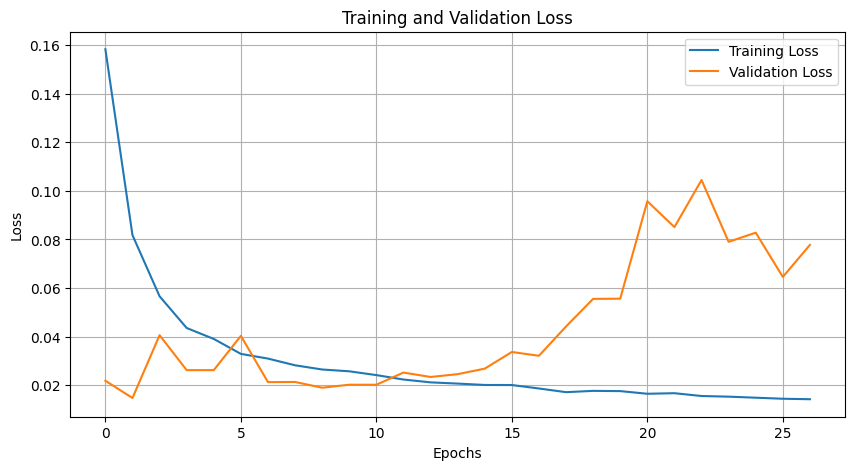

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(historyspy.history['loss'], label='Training Loss')
plt.plot(historyspy.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
predictionspyt,predictionspyn = modelspy.predict(X_testspy)
combined_preds = np.column_stack((predictionspyt, predictionspyn))
prediction_invspy = scaler_outputspy.inverse_transform(combined_preds)
prediction_invspyt = prediction_invspy[0].flatten()
# y_test_invspy = scaler_outputspy.inverse_transform(y_testspy)

valuesspy = np.array(ytestspy_reset[window_size:])


46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step


In [32]:
# Extract the actual components
actual_trend = valuesspy[:, 0]
actual_noise = valuesspy[:, 1]
actual_final = actual_trend + actual_noise

# Extract the predicted components
pred_trend = prediction_invspy[:, 0]
pred_noise = prediction_invspy[:, 1]
pred_final = pred_trend + pred_noise

# Calculate metrics for Trend
r2_trend = r2_score(actual_trend, pred_trend)
mae_trend = mean_absolute_error(actual_trend, pred_trend)

# Calculate metrics for Noise
r2_noise = r2_score(actual_noise, pred_noise)
mae_noise = mean_absolute_error(actual_noise, pred_noise)

# Calculate metrics for Final (Trend + Noise)
r2_final = r2_score(actual_final, pred_final)
mae_final = mean_absolute_error(actual_final, pred_final)

print("Trend:   R2 = {:.4f}, MAE = {:.4f}".format(r2_trend, mae_trend))
print("Noise:   R2 = {:.4f}, MAE = {:.4f}".format(r2_noise, mae_noise))
print("Final:   R2 = {:.4f}, MAE = {:.4f}".format(r2_final, mae_final))

Trend:   R2 = -0.0051, MAE = 3.7737
Noise:   R2 = -0.0467, MAE = 1.1254
Final:   R2 = -0.0129, MAE = 4.0187


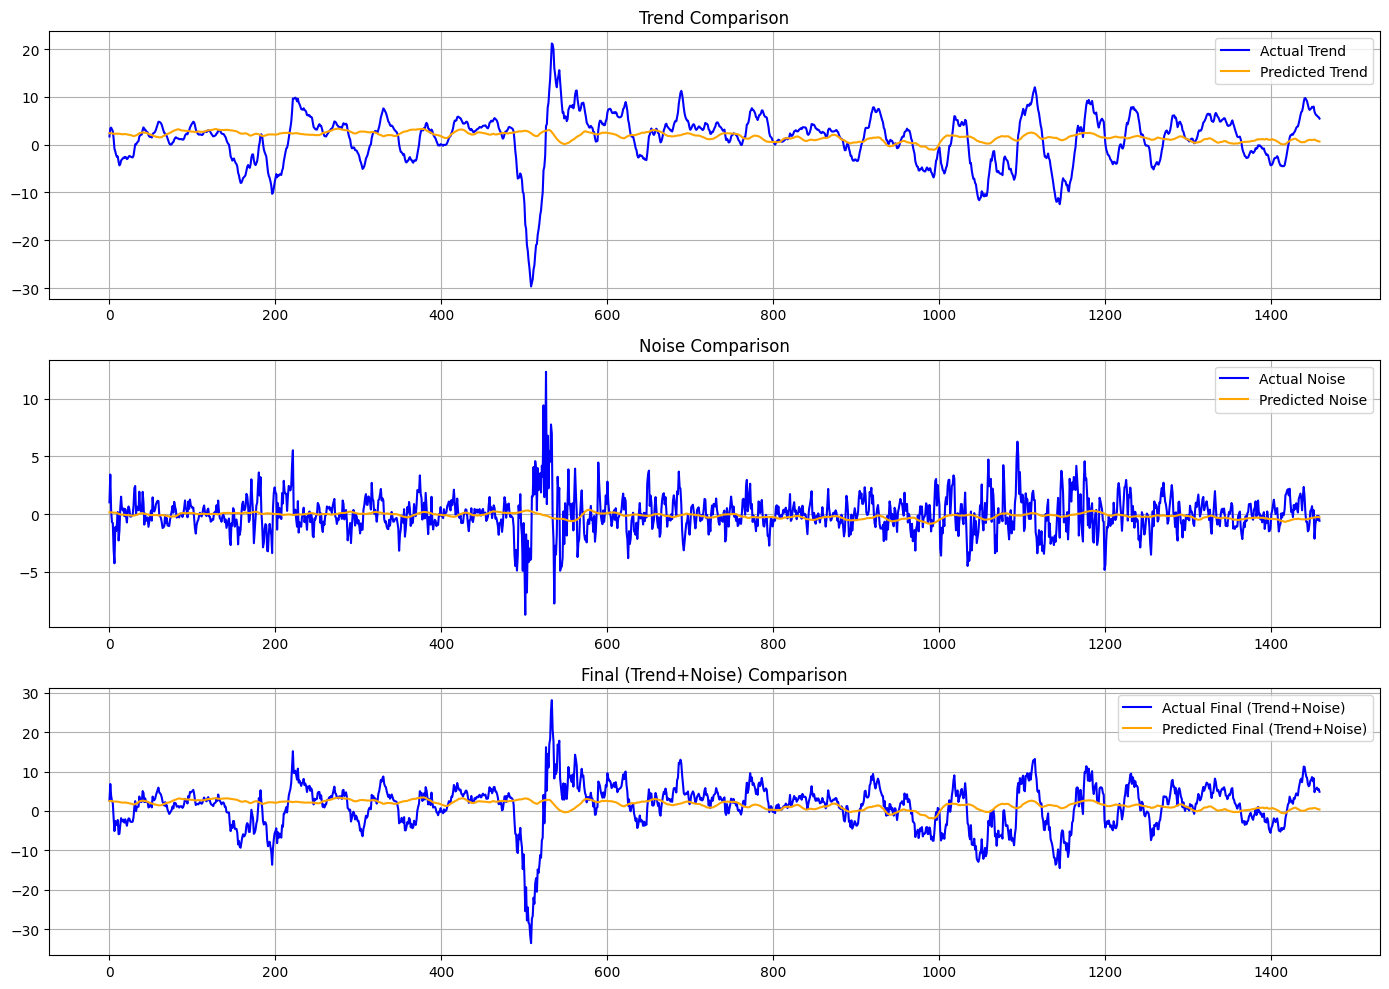

In [33]:
# Plotting the Actual vs. Predicted for Trend, Noise, and Final
plt.figure(figsize=(14, 10))

# Trend plot
plt.subplot(3, 1, 1)
plt.plot(actual_trend, label="Actual Trend", color="blue")
plt.plot(pred_trend, label="Predicted Trend", color="orange")
plt.title("Trend Comparison")
plt.legend()
plt.grid(True)

# Noise plot
plt.subplot(3, 1, 2)
plt.plot(actual_noise, label="Actual Noise", color="blue")
plt.plot(pred_noise, label="Predicted Noise", color="orange")
plt.title("Noise Comparison")
plt.legend()
plt.grid(True)

# Final (Trend + Noise) plot
plt.subplot(3, 1, 3)
plt.plot(actual_final, label="Actual Final (Trend+Noise)", color="blue")
plt.plot(pred_final, label="Predicted Final (Trend+Noise)", color="orange")
plt.title("Final (Trend+Noise) Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Step2: Fixed Income → iShares 20+ Year Treasury Bond ETF. Symbol: “TLT

In [34]:

# Download tlt data from 2014 to 2022
vtlt1 = yf.download('TLT', start='2010-01-01', end='2023-12-31')

# Use only the 'Adj Close' for simplicity
#vtlt1 = vtlt1[['Close']].rename(columns={'Close, tlt': 'Close'})
vtlt1.columns = vtlt1.columns.droplevel(1)
vtlt1['Open_diff'] = vtlt1['Open'].diff()

vtlt1['Returns'] = vtlt1['Close'].pct_change()
vtlt1['Returns'] = vtlt1['Returns']*100
vtlt1['MA7'] = vtlt1['Returns'].rolling(window=5).mean().pct_change()
vtlt1['MA11'] = vtlt1['Returns'].rolling(window=11).mean().pct_change()
vtlt1['MA21'] = vtlt1['Returns'].rolling(window=21).mean().pct_change()
vtlt1['MA31'] = vtlt1['Returns'].rolling(window=31).mean().pct_change()
vtlt1['VA7'] = vtlt1['Close'].rolling(window=5).std()
vtlt1['VA11'] = vtlt1['Close'].rolling(window=11).std()
vtlt1['VA21'] = vtlt1['Close'].rolling(window=21).std()
vtlt1['VA31'] = vtlt1['Close'].rolling(window=31).std()

returns = vtlt1['Returns'].dropna()

garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# === Shift vtlt1 to align with GARCH output ===
vtlt1 = vtlt1.iloc[1:].copy()  # Drop first row to match returns length


vtlt1['GARCH_vol'] = garch_result.conditional_volatility

# === Optional: Forward fill any possible edge NaNs ===
vtlt1['GARCH_vol'] = vtlt1['GARCH_vol'].fillna(method='bfill')
vtlt1['GARCH_vol']=vtlt1['GARCH_vol']*100
# # === Add Volatility Regime Indicator ===
vtlt1['Volatility_Regime'] = (vtlt1['GARCH_vol'] > vtlt1['GARCH_vol'].rolling(window=3).median()).astype(int)
vtlt1['Volatility_Regime1'] = (vtlt1['GARCH_vol'] > vtlt1['GARCH_vol'].rolling(window=5).median()).astype(int)
vtlt1['Volatility_Regime2'] =  (vtlt1['GARCH_vol'] > vtlt1['GARCH_vol'].rolling(window=10).median()).astype(int)
vtlt1['Volatility_Regime3'] = (vtlt1['GARCH_vol'] > vtlt1['GARCH_vol'].rolling(window=15).median()).astype(int)
vtlt1['Volatility_Regime4'] =  (vtlt1['GARCH_vol'] > vtlt1['GARCH_vol'].rolling(window=25).median()).astype(int)
# # One-hot encode the Volatility_Regime column
volatility_dummies = pd.get_dummies(vtlt1['Volatility_Regime'], prefix='Volatility_Regime')
vtlt1['Noise1'] = vtlt1['Close'] - vtlt1['Close'].rolling(window=3).mean()
vtlt1['GARCH2'] = vtlt1['GARCH_vol'].astype(int).rolling(window=5).max()
vtlt1['GARCH3'] =  vtlt1['GARCH_vol'].astype(int).rolling(window=5).min()
vtlt1['GARCH4'] =  vtlt1['GARCH_vol'].rolling(window=10).max()
vtlt1['GARCH5'] =  vtlt1['GARCH_vol'].rolling(window=10).min()
#vtlt1['Noise6'] = vtlt1['Close'] - vtlt1['Close'].astype(int).rolling(window=7).mean()
#vtlt1['Noise7'] =  vtlt1['Close']-vtlt1['GARCH_vol'].astype(int).rolling(window=11).mean()
# # Concatenate the one-hot columns back to the dataframe
vtlt1 = pd.concat([vtlt1, volatility_dummies], axis=1)

# === Define Volatility Regimes (4 Classes) ===
quantiles = vtlt1['GARCH_vol'].quantile([0.2, 0.3, 0.5, 0.7,0.8])

def classify_volatility(vol):
    if vol <= quantiles[0.2]:
        return "Very Low"
    elif vol <= quantiles[0.3]:
        return "Low"
    elif vol <= quantiles[0.5]:
        return "Medium"
    elif vol <= quantiles[0.7]:
        return "High"
    elif vol <= quantiles[0.8]:
        return "Very High"
    else:
        return "Very Very High"

vtlt1['Volatility_Regime'] = vtlt1['GARCH_vol'].apply(classify_volatility)

# === One-Hot Encode the 4 Classes ===
volatility_dummies = pd.get_dummies(vtlt1['Volatility_Regime'], prefix='Volatility_Regime')

# === Add One-Hot Columns to DataFrame ===
vtlt1 = pd.concat([vtlt1, volatility_dummies], axis=1)



# Drop the original 'Volatility_Regime' column if you don't need it anymore
vtlt1 = vtlt1.drop(columns=['Volatility_Regime'])
# === Add GARCH Residuals ===
vtlt1['GARCH_residuals3'] = vtlt1['Returns']-vtlt1['GARCH_vol'].shift(3)
vtlt1['GARCH_residuals10'] = vtlt1['Returns']-vtlt1['GARCH_vol'].shift(5)
vtlt1['GARCH_residuals20'] = vtlt1['Returns']-vtlt1['GARCH_vol'].shift(10)
vtlt1['GARCH_residuals30'] = vtlt1['Returns']-vtlt1['GARCH_vol'].shift(30)
# === Add Rolling Volatility (alternative to GARCH if you want) ===
vtlt1['RollingVolatility_11d'] = vtlt1['Returns'].rolling(window=11).std()
vtlt1['RollingVolatility_21d'] = vtlt1['Returns'].rolling(window=21).std()
vtlt1['RollingVolatility_5d'] = vtlt1['Returns'].rolling(window=5).std()
#del vtlt1["Volume"]

vtlt1['Return+25'] = vtlt1['Close'].shift(-25) / vtlt1['Close'] - 1
vtlt1['Return+25'] = vtlt1['Return+25']*100
vtlt1['Return+25_Denoised']= vtlt1['Return+25'].ewm(span=5, adjust=False).mean()
vtlt1['Noise'] = vtlt1['Return+25'] - vtlt1['Return+25_Denoised']
#vshy1['Output'] = vshy1['Return+25_Denoised']
vtlt1["Output"] = vtlt1['Return+25_Denoised']
vtlt1=pd.DataFrame(vtlt1)
# Create additional features

# Split into training, validation, and test
vtraintlt1 = vtlt1.loc['2010-01-01':'2017-12-31']
vtesttlt1 = vtlt1.loc['2018-01-01':'2023-12-30']
vtesttlt1=vtesttlt1[:-25]
# Create Validation Set (20% of Training Data)
vval_size1 = int(0.2 * len(vtraintlt1))
vtraintlt_set1 = vtraintlt1.iloc[:-vval_size1]
vvaltlt_set1 = vtraintlt1.iloc[-vval_size1:]

# Confirm Data Split
print ()
print(f"Training Set: {vtraintlt_set1.index.min()} to {vtraintlt_set1.index.max()}")
print(f"Validation Set: {vvaltlt_set1.index.min()} to {vvaltlt_set1.index.max()}")
print(f"Test Set: {vtesttlt1.index.min()} to {vtesttlt1.index.max()}")

[*********************100%***********************]  1 of 1 completed


Training Set: 2010-01-05 00:00:00 to 2016-05-26 00:00:00
Validation Set: 2016-05-27 00:00:00 to 2017-12-29 00:00:00
Test Set: 2018-01-02 00:00:00 to 2023-11-22 00:00:00



<ipython-input-34-9fec6f73bbb6>:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vtlt1['GARCH_vol'] = vtlt1['GARCH_vol'].fillna(method='bfill')


In [35]:
# Drop NaN values
vtraintlt_set1.dropna(inplace=True)
vvaltlt_set1.dropna(inplace=True)
vtesttlt1.dropna(inplace=True)
# Prepare features
featurestlt = ['Open', 'Open_diff','Returns', 'MA7', 'MA11','MA21','MA31',
             'VA7', 'VA11','VA21','VA31', 'GARCH_vol',
            'Volatility_Regime1','Volatility_Regime2', 'Volatility_Regime3', 'Volatility_Regime4',
            'Volatility_Regime_0','Volatility_Regime_1',
            'Noise1','GARCH2','GARCH3',
             'GARCH4','GARCH5',
             'GARCH_residuals10', 'GARCH_residuals3',
             'GARCH_residuals20','GARCH_residuals30',
            'RollingVolatility_5d','RollingVolatility_11d',
            'RollingVolatility_21d',
            'Volatility_Regime_Very Low',
            'Volatility_Regime_Low',
            'Volatility_Regime_Medium',
            'Volatility_Regime_High',
            'Volatility_Regime_Very High','Volatility_Regime_Very Very High'
            ]
target = 'Close'

<ipython-input-35-0ec8f642efa8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vtraintlt_set1.dropna(inplace=True)
<ipython-input-35-0ec8f642efa8>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vvaltlt_set1.dropna(inplace=True)


In [36]:
nfeattlt3=vtraintlt_set1.shape[1]-1
nfeattlt3
window_size = 25  # How many daily prices do I want to incorporate in the input sequence for the network?

test_timetlt = vtesttlt1.index[window_size :]
test_timetlt[:5]

DatetimeIndex(['2018-02-07', '2018-02-08', '2018-02-09', '2018-02-12',
               '2018-02-13'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [37]:
Xtraintlt, Xvaltlt,Xtesttlt = vtraintlt_set1.iloc[:, 0:nfeattlt3], vvaltlt_set1.iloc[:,0:nfeattlt3],vtesttlt1.iloc[:,0:nfeattlt3]
ytraintlt, yvaltlt, ytesttlt = vtraintlt_set1.iloc[:, -1], vvaltlt_set1.iloc[:, -1],vtesttlt1.iloc[:,-1]
Xtraintlt = Xtraintlt.astype("float32")
Xvaltlt = Xvaltlt.astype("float32")
Xtesttlt = Xtesttlt.astype("float32")
ytraintlt = ytraintlt.astype("float32")
yvaltlt = yvaltlt.astype("float32")
ytesttlt = ytesttlt.astype("float32")


In [38]:
training_time = Xtraintlt.index
training_time
test_time = Xtesttlt.index
test_time
n_featurestlt = Xtraintlt.shape[1]
n_featurestlt

43

In [39]:
# Third, we proceed with scaling inputs to the model. Note how this is specially important now (compare to past tasks) because we are no longer dealing with returns, but with prices!
scaler_inputtlt = MinMaxScaler(feature_range=(-1, 1))
scaler_inputtlt.fit(Xtraintlt[featurestlt])
X_traintlt_scaled = scaler_inputtlt.transform(Xtraintlt[featurestlt])
X_valtlt_scaled =scaler_inputtlt.transform(Xvaltlt[featurestlt])
X_testtlt_scaled = scaler_inputtlt.transform(Xtesttlt[featurestlt])

In [40]:
# Third, we proceed with scaling inputs to the model. Note how this is specially important now (compare to past tasks) because we are no longer dealing with returns, but with prices!
scaler_input = MinMaxScaler(feature_range=(-1, 1))
scaler_input.fit(Xtraintlt[featurestlt])
X_traintlt_scaled = scaler_input.transform(Xtraintlt[featurestlt])
X_valtlt_scaled =scaler_input.transform(Xvaltlt[featurestlt])
X_testtlt_scaled = scaler_input.transform(Xtesttlt[featurestlt])

In [41]:
mean_rettlt = np.mean(ytraintlt)

scaler_outputtlt = MinMaxScaler(feature_range=(-1, 1))
ytrainsettlt = ytraintlt.values.reshape(len(ytraintlt), 1)
yvalsettlt = yvaltlt.values.reshape(len(yvaltlt), 1)
ytestsettlt = ytesttlt.values.reshape(len(ytesttlt), 1)
scaler_outputtlt.fit(ytrainsettlt)
y_traintlt_scaled = scaler_outputtlt.transform(ytrainsettlt)
y_valtlt_scaled = scaler_outputtlt.transform(yvalsettlt)
y_testtlt_scaled = scaler_outputtlt.transform(ytestsettlt)

In [42]:
X_traintlt = []
y_traintlt = []
X_valtlt=[]
y_valtlt=[]
for i in range(window_size, y_traintlt_scaled.shape[0]):
    X_traintlt.append(X_traintlt_scaled[i - window_size : i, :])
    y_traintlt.append(y_traintlt_scaled[i])
for i in range(window_size, y_valtlt_scaled.shape[0]):
    X_valtlt.append(X_valtlt_scaled[i - window_size : i, :])
    y_valtlt.append(y_valtlt_scaled[i])
X_traintlt, y_traintlt = np.array(X_traintlt), np.array(y_traintlt)
X_valtlt, y_valtlt = np.array(X_valtlt), np.array(y_valtlt)
print ()
print("Size of X vector in training:", X_traintlt.shape)
print("Size of Y vector in training:", y_traintlt.shape)
print ()
print("Size of X vector in Validation:", X_valtlt.shape)
print("Size of Y vector in Validation:", y_valtlt.shape)
X_testtlt = []
y_testtlt = y_testtlt_scaled[window_size:]

for i in range(window_size, y_testtlt_scaled.shape[0]):
    X_testtlt.append(X_testtlt_scaled[i - window_size : i, :])


X_testtlt, y_testtlt = np.array(X_testtlt), np.array(y_testtlt)
print("Size of X vector in test:", X_testtlt.shape)
print("Size of Y vector in test:", y_testtlt.shape)
print("Number of features in the model: ", n_featurestlt)


Size of X vector in training: (1554, 25, 36)
Size of Y vector in training: (1554, 1)

Size of X vector in Validation: (377, 25, 36)
Size of Y vector in Validation: (377, 1)
Size of X vector in test: (1459, 25, 36)
Size of Y vector in test: (1459, 1)
Number of features in the model:  43


In [43]:
def fluctuation_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # Difference between consecutive days (fluctuations)
    fluct_true = y_true[:, 1:] - y_true[:, :-1]
    fluct_pred = y_pred[:, 1:] - y_pred[:, :-1]

    # Penalize difference between actual and predicted fluctuations
    fluct_penalty = tf.reduce_mean(tf.square(fluct_true - fluct_pred))

    # Combine both losses
def build_advanced_model(window_size, num_features):
    inputs = Input(shape=(window_size, num_features))

    # 1️⃣ Local feature extraction (short-term fluctuations)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    # 2️⃣ Long-term memory (trend)
    x = LSTM(64, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
   # x = LSTM(128, return_sequences=False)(x)
    # 3️⃣ Transformer-like Attention Block (for importance weighting)
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x, x)
    attn = Add()([x, attn])
    attn = LayerNormalization()(attn)

    # 4️⃣ More dense layers to learn complex mapping
    x = GlobalAveragePooling1D()(attn)
    x = Dense(128, activation='tanh')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='tanh')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='linear')(x)  # Predict 25-day return

    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=fluctuation_loss, metrics=['mae'])

    return model

# Build and Compile
modeltlt = build_advanced_model(X_traintlt.shape[1],X_traintlt.shape[2])
modeltlt.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 25, 36)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 25, 32)         │          3,488 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 25, 32)         │            128 │ conv1d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 25, 32)         │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 25, 32)         │          3,104 │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 25, 32)         │            128 │ conv1d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 25, 32)         │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_3 (LSTM)             │ (None, 25, 64)         │         24,832 │ dropout_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_4 (LSTM)             │ (None, 25, 128)        │         98,816 │ lstm_3[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 25, 128)        │         33,088 │ lstm_4[0][0],          │
│ (MultiHeadAttention)      │                        │                │ lstm_4[0][0],          │
│                           │                        │                │ lstm_4[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 25, 128)        │              0 │ lstm_4[0][0],          │
│                           │                        │                │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 25, 128)        │            256 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d  │ (None, 128)            │              0 │ layer_normalization_1… │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 128)            │         16,512 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_7 (Dropout)       │ (None, 128)            │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)      

 Total params: 188,673 (737.00 KB)

 Trainable params: 188,545 (736.50 KB)

 Non-trainable params: 128 (512.00 B)

In [44]:
def custom_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    fluct_penalty = tf.reduce_mean(tf.square(tf.abs(y_true - y_pred) - tf.abs(y_true.shift(1) - y_true)))
    return mse + 0.5 * fluct_penalty
hp_lr = 1e-4
modeltlt.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr), loss="mean_absolute_error", metrics=["mean_absolute_error"]
)

es = EarlyStopping(
    monitor="val_loss", mode="min", verbose=1, patience=25, restore_best_weights=True
)

In [45]:

# fit the models
historytlt=modeltlt.fit(
    X_traintlt,
    y_traintlt,
    validation_data=(X_valtlt, y_valtlt),
    epochs=500,
    batch_size=64,
    verbose=1,
    callbacks=[es],
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 188ms/step - loss: 0.6688 - mean_absolute_error: 0.6688 - val_loss: 0.4251 - val_mean_absolute_error: 0.4251
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.5889 - mean_absolute_error: 0.5889 - val_loss: 0.3990 - val_mean_absolute_error: 0.3990
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.5500 - mean_absolute_error: 0.5500 - val_loss: 0.3325 - val_mean_absolute_error: 0.3325
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.5272 - mean_absolute_error: 0.5272 - val_loss: 0.2773 - val_mean_absolute_error: 0.2773
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.5171 - mean_absolute_error: 0.5171 - val_loss: 0.2708 - val_mean_absolute_error: 0.2708
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.5124 - mean_absolute_error: 0.5124 - val_loss: 0.2746 - val_mean_absolute_error: 0.2746
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - loss: 0.4637 - mean_absolute_error: 0.

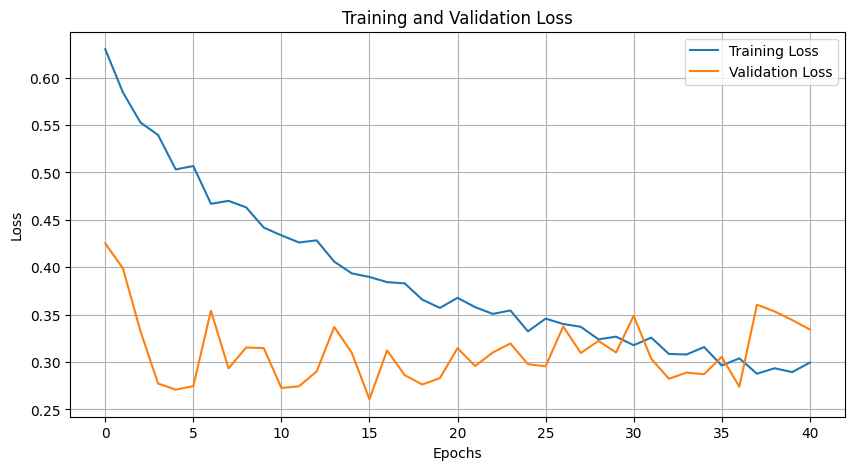

In [46]:
plt.figure(figsize=(10, 5))
plt.plot(historytlt.history['loss'], label='Training Loss')
plt.plot(historytlt.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
predictiontlt = modeltlt.predict(X_testtlt)
prediction_invtlt = scaler_outputtlt.inverse_transform(predictiontlt)
prediction_invtlt = prediction_invtlt.flatten()
y_test_invtlt = scaler_outputtlt.inverse_transform(y_testtlt)

valuestlt = np.array(ytestsettlt[window_size:])
valuestlt = valuestlt.flatten()

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


In [48]:
from sklearn.metrics import r2_score

# Example (replace with your actual y_test and y_pred arrays)
r2 = r2_score(y_test_invtlt, prediction_invtlt)
print(f'R-squared: {r2:.4f}')
mae=mean_absolute_error(y_test_invtlt, prediction_invtlt)
print(f'MAE: {mae:.4f}')


R-squared: -0.0343
MAE: 3.7209


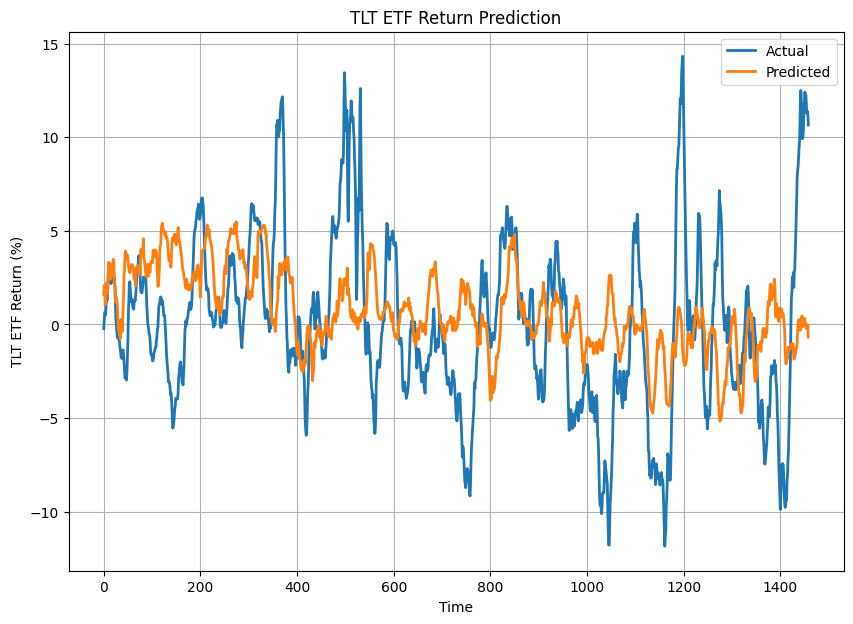

In [49]:


# Example (replace with your actual y_test and y_pred arrays)
# Plot results
plt.figure(figsize=(10, 7))
plt.plot(y_test_invtlt, label='Actual', linewidth=2)
plt.plot(prediction_invtlt, label='Predicted', linewidth=2)
plt.title('TLT ETF Return Prediction')
plt.xlabel('Time')
plt.ylabel('TLT ETF Return (%)')
plt.legend()
plt.grid(True)
plt.show()


In [50]:
df_predictionstlt = pd.DataFrame(
    {"Date": test_timetlt, "Pred RNN": prediction_invtlt, "Actual_values": valuestlt}
)
df_predictionstlt.Date = pd.to_datetime(df_predictionstlt.Date, format="%Y-%m-%d")
df_predictionstlt.head()

,Date,Pred RNN,Actual_values
0,2018-02-07,1.612025,-0.225899
1,2018-02-08,2.080931,0.231794
2,2018-02-09,1.744088,0.643714
3,2018-02-12,1.049003,0.634525
4,2018-02-13,1.090995,0.515505


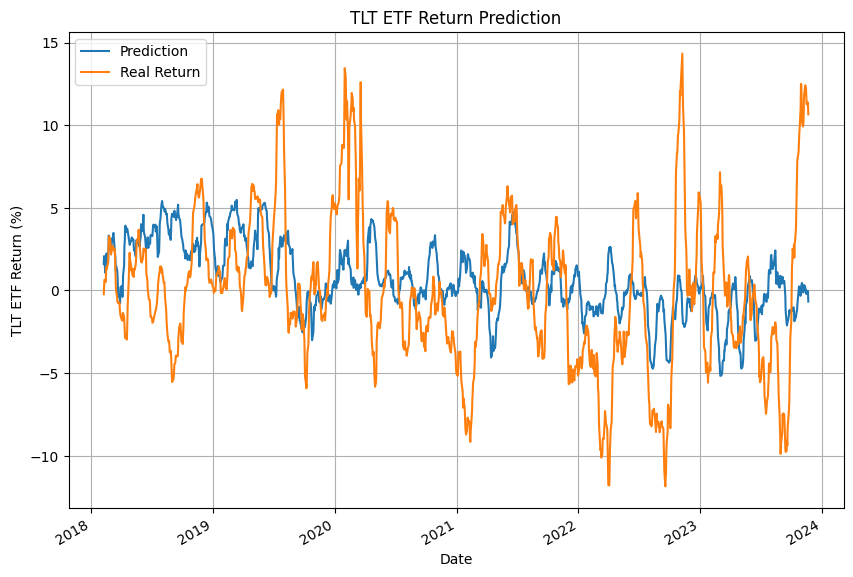

In [51]:
import matplotlib.pyplot as plt

plt_1 = plt.figure(figsize=(10, 7))
ax = plt.gca()
df_predictionstlt.plot(x="Date", y="Pred RNN", label="Prediction", ax=ax)
df_predictionstlt.plot(x="Date", y="Actual_values", label="Real Return", ax=ax)
plt.title('TLT ETF Return Prediction')
plt.xlabel('Date')
plt.ylabel('TLT ETF Return (%)')
plt.legend()
plt.grid(True)

plt.show()

 ## Cash-like → iShares 1-3 Year Treasury Bond ETF. Symbol: “SHY”

In [52]:

# Download shy data from 2014 to 2022
vshy1 = yf.download('SHY', start='2010-01-01', end='2023-12-31')

# Use only the 'Adj Close' for simplicity
#vshy1 = vshy1[['Close']].rename(columns={'Close, shy': 'Close'})
vshy1.columns = vshy1.columns.droplevel(1)
vshy1['Open_diff'] = vshy1['Open'].diff()
vshy1['Returns'] = vshy1['Close'].pct_change()
vshy1['Returns'] = vshy1['Returns']*100
vshy1['MA7'] = vshy1['Returns'].rolling(window=7).mean().pct_change()
vshy1['MA11'] = vshy1['Returns'].rolling(window=11).mean().pct_change()
vshy1['MA21'] = vshy1['Returns'].rolling(window=21).mean().pct_change()
vshy1['MA31'] = vshy1['Returns'].rolling(window=31).mean().pct_change()
vshy1['VA7'] = vshy1['Close'].rolling(window=5).std()
vshy1['VA11'] = vshy1['Close'].rolling(window=11).std()
vshy1['VA21'] = vshy1['Close'].rolling(window=21).std()
vshy1['VA31'] = vshy1['Close'].rolling(window=31).std()

returns = vshy1['Returns'].dropna()

garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# === Shift vshy1 to align with GARCH output ===
vshy1 = vshy1.iloc[1:].copy()  # Drop first row to match returns length


vshy1['GARCH_vol'] = garch_result.conditional_volatility

# === Optional: Forward fill any possible edge NaNs ===
vshy1['GARCH_vol'] = vshy1['GARCH_vol'].fillna(method='bfill')
vshy1['GARCH_vol']=vshy1['GARCH_vol']*100
# # === Add Volatility Regime Indicator ===
vshy1['Volatility_Regime'] = (vshy1['GARCH_vol'] > vshy1['GARCH_vol'].rolling(window=3).median()).astype(int)
vshy1['Volatility_Regime1'] = (vshy1['GARCH_vol'] > vshy1['GARCH_vol'].rolling(window=5).median()).astype(int)
vshy1['Volatility_Regime2'] =  (vshy1['GARCH_vol'] > vshy1['GARCH_vol'].rolling(window=10).median()).astype(int)
vshy1['Volatility_Regime3'] = (vshy1['GARCH_vol'] > vshy1['GARCH_vol'].rolling(window=15).median()).astype(int)
vshy1['Volatility_Regime4'] =  (vshy1['GARCH_vol'] > vshy1['GARCH_vol'].rolling(window=25).median()).astype(int)
# # One-hot encode the Volatility_Regime column
volatility_dummies = pd.get_dummies(vshy1['Volatility_Regime'], prefix='Volatility_Regime')
vshy1['Noise1'] = vshy1['Close'] - vshy1['Close'].rolling(window=3).mean()
vshy1['GARCH2'] =  vshy1['GARCH_vol'].astype(int).rolling(window=5).max()
vshy1['GARCH3'] =   vshy1['GARCH_vol'].astype(int).rolling(window=5).min()
vshy1['GARCH4'] =   vshy1['GARCH_vol'].rolling(window=10).max()
vshy1['GARCH5'] =   vshy1['GARCH_vol'].rolling(window=10).min()
#vshy1['Noise6'] = vshy1['Close'] - vshy1['Close'].astype(int).rolling(window=7).mean()
#vshy1['Noise7'] =  vshy1['Close']-vshy1['GARCH_vol'].astype(int).rolling(window=11).mean()
# # Concatenate the one-hot columns back to the dataframe
vshy1 = pd.concat([vshy1, volatility_dummies], axis=1)

# === Define Volatility Regimes (4 Classes) ===
quantiles = vshy1['GARCH_vol'].quantile([0.2, 0.3, 0.5, 0.7,0.8])

def classify_volatility(vol):
    if vol <= quantiles[0.2]:
        return "Very Low"
    elif vol <= quantiles[0.3]:
        return "Low"
    elif vol <= quantiles[0.5]:
        return "Medium"
    elif vol <= quantiles[0.7]:
        return "High"
    elif vol <= quantiles[0.8]:
        return "Very High"
    else:
        return "Very Very High"

vshy1['Volatility_Regime'] = vshy1['GARCH_vol'].apply(classify_volatility)

# === One-Hot Encode the 4 Classes ===
volatility_dummies = pd.get_dummies(vshy1['Volatility_Regime'], prefix='Volatility_Regime')

# === Add One-Hot Columns to DataFrame ===
vshy1 = pd.concat([vshy1, volatility_dummies], axis=1)



# Drop the original 'Volatility_Regime' column if you don't need it anymore
vshy1 = vshy1.drop(columns=['Volatility_Regime'])
# === Add GARCH Residuals ===
vshy1['GARCH_residuals3'] = vshy1['Returns']-vshy1['GARCH_vol'].shift(3)
vshy1['GARCH_residuals10'] = vshy1['Returns']-vshy1['GARCH_vol'].shift(10)
vshy1['GARCH_residuals20'] = vshy1['Returns']-vshy1['GARCH_vol'].shift(20)
vshy1['GARCH_residuals30'] = vshy1['Returns']-vshy1['GARCH_vol'].shift(30)
# === Add Rolling Volatility (alternative to GARCH if you want) ===
vshy1['RollingVolatility_11d'] = vshy1['Returns'].rolling(window=11).std()
vshy1['RollingVolatility_21d'] = vshy1['Returns'].rolling(window=21).std()
vshy1['RollingVolatility_5d'] = vshy1['Returns'].rolling(window=5).std()
#del vshy1["Volume"]

vshy1['Return+25'] = vshy1['Close'].shift(-25) / vshy1['Close'] - 1
vshy1['Return+25'] = vshy1['Return+25']*100
vshy1['Return+25_Denoised']= vshy1['Return+25'].ewm(span=5, adjust=False).mean()
vshy1['Noise'] = vshy1['Return+25'] - vshy1['Return+25_Denoised']
vshy1['Output'] = vshy1['Return+25_Denoised']
#vshy1["Output"] = vshy1['Return+25']
vshy1=pd.DataFrame(vshy1)
# Create additional features

# Split into training, validation, and test
vtrainshy1 = vshy1.loc['2010-01-01':'2017-12-31']
vtestshy1 = vshy1.loc['2018-01-01':'2023-12-30']
vtestshy1=vtestshy1[:-25]
# Create Validation Set (20% of Training Data)
vval_size1 = int(0.2 * len(vtrainshy1))
vtrainshy_set1 = vtrainshy1.iloc[:-vval_size1]
vvalshy_set1 = vtrainshy1.iloc[-vval_size1:]

# Confirm Data Split
print ()
print(f"Training Set: {vtrainshy_set1.index.min()} to {vtrainshy_set1.index.max()}")
print(f"Validation Set: {vvalshy_set1.index.min()} to {vvalshy_set1.index.max()}")
print(f"Test Set: {vtestshy1.index.min()} to {vtestshy1.index.max()}")

[*********************100%***********************]  1 of 1 completed


Training Set: 2010-01-05 00:00:00 to 2016-05-26 00:00:00
Validation Set: 2016-05-27 00:00:00 to 2017-12-29 00:00:00
Test Set: 2018-01-02 00:00:00 to 2023-11-22 00:00:00



/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.006624. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
<ipython-input-52-24e1480caaf2>:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vshy1['GARCH_vol'] = vshy1['GARCH_vol'].fillna(method='bfill')


In [53]:
# Drop NaN values
vtrainshy_set1.dropna(inplace=True)
vvalshy_set1.dropna(inplace=True)
vtestshy1.dropna(inplace=True)
# Prepare features
featuresshy = ['Open', 'Open_diff','Returns', 'MA7', 'MA11','MA21','MA31',
             'VA7', 'VA11','VA21','VA31', 'GARCH_vol',
             'Volatility_Regime1','Volatility_Regime2', 'Volatility_Regime3', 'Volatility_Regime4',
            'Volatility_Regime_0','Volatility_Regime_1',
             'Noise1',
               'GARCH2','GARCH3',
              'GARCH4','GARCH5',
             'GARCH_residuals10', 'GARCH_residuals3',
             'GARCH_residuals20','GARCH_residuals30',
              'RollingVolatility_5d','RollingVolatility_11d',
             'RollingVolatility_21d',
            'Volatility_Regime_Very Low',
            'Volatility_Regime_Low',
            'Volatility_Regime_Medium',
            'Volatility_Regime_High',
            'Volatility_Regime_Very High','Volatility_Regime_Very Very High'
            ]
target = 'Output'

<ipython-input-53-92a5f6318497>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vtrainshy_set1.dropna(inplace=True)
<ipython-input-53-92a5f6318497>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vvalshy_set1.dropna(inplace=True)


In [54]:
nfeatshy3=vtrainshy_set1.shape[1]-1
nfeatshy3
window_size = 25  # How many daily prices do I want to incorporate in the input sequence for the network?

test_timeshy = vtestshy1.index[window_size :]
test_timeshy[:5]

DatetimeIndex(['2018-02-07', '2018-02-08', '2018-02-09', '2018-02-12',
               '2018-02-13'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [55]:
Xtrainshy, Xvalshy,Xtestshy = vtrainshy_set1.iloc[:, 0:nfeatshy3], vvalshy_set1.iloc[:,0:nfeatshy3],vtestshy1.iloc[:,0:nfeatshy3]
ytrainshy, yvalshy, ytestshy = vtrainshy_set1.iloc[:, -1], vvalshy_set1.iloc[:, -1],vtestshy1.iloc[:,-1]
Xtrainshy = Xtrainshy.astype("float32")
Xvalshy = Xvalshy.astype("float32")
Xtestshy = Xtestshy.astype("float32")
ytrainshy = ytrainshy.astype("float32")
yvalshy = yvalshy.astype("float32")
ytestshy = ytestshy.astype("float32")


In [56]:
Xtestshy.tail(5)

,Close,High,Low,Open,Volume,Open_diff,Returns,MA7,MA11,MA21,...,GARCH_residuals3,GARCH_residuals10,GARCH_residuals20,GARCH_residuals30,RollingVolatility_11d,RollingVolatility_21d,RollingVolatility_5d,Return+25,Return+25_Denoised,Noise
Date,,,,,,,,,,,,,,,,,,,,,
2023-11-16,77.239883,77.277870,77.230392,77.230392,4086500.0,0.085482,0.172433,0.566730,-0.101578,0.190675,...,-11.864455,-12.905687,-12.268688,-12.390454,0.184294,0.151496,0.213362,1.377373,1.395567,-0.018194
2023-11-17,77.182907,77.230392,77.163918,77.220894,3381800.0,-0.009501,-0.073765,-0.180487,-0.193303,-0.195104,...,-10.877295,-11.689464,-12.636943,-12.032948,0.187411,0.152533,0.224999,1.402716,1.397950,0.004766
2023-11-20,77.192390,77.201889,77.173393,77.192390,6247300.0,-0.028501,0.012287,0.718675,-0.721918,-0.171446,...,-19.992344,-15.842580,-13.199868,-11.334831,0.169828,0.150134,0.226155,1.514040,1.436647,0.077394
2023-11-21,77.239883,77.277870,77.220894,77.239883,2590400.0,0.047493,0.061525,0.096142,2.464598,-0.000338,...,-19.518194,-16.294899,-11.959002,-16.526043,0.157513,0.150132,0.135165,1.439245,1.437513,0.001732
2023-11-22,77.249359,77.277847,77.201881,77.277847,4803300.0,0.037962,0.012268,-0.059018,-0.178409,0.051487,...,-18.910242,-14.827297,-10.735531,-14.961057,0.156944,0.149623,0.090048,1.476293,1.450440,0.025853


In [57]:
training_time = Xtrainshy.index
training_time
test_time = Xtestshy.index
test_time
n_featuresshy = Xtrainshy.shape[1]
n_featuresshy

43

In [58]:
for col in Xtrainshy.columns:
     print ("col:",col," :",Xtrainshy[col].max())

col: Close  : 72.96163177490234
col: High  : 72.97876739501953
col: Low  : 72.93589782714844
col: Open  : 72.9701919555664
col: Volume  : 54448200.0
col: Open_diff  : 0.179860457777977
col: Returns  : 0.23904164135456085
col: MA7  : 8426.75390625
col: MA11  : 2823.820556640625
col: MA21  : 291.1446838378906
col: MA31  : 4849.52197265625
col: VA7  : 0.1258966028690338
col: VA11  : 0.14332300424575806
col: VA21  : 0.17763516306877136
col: VA31  : 0.199578195810318
col: GARCH_vol  : 13.71882152557373
col: Volatility_Regime1  : 1.0
col: Volatility_Regime2  : 1.0
col: Volatility_Regime3  : 1.0
col: Volatility_Regime4  : 1.0
col: Noise1  : 0.1301727294921875
col: GARCH2  : 13.0
col: GARCH3  : 10.0
col: GARCH4  : 13.71882152557373
col: GARCH5  : 9.475014686584473
col: Volatility_Regime_0  : 1.0
col: Volatility_Regime_1  : 1.0
col: Volatility_Regime_High  : 1.0
col: Volatility_Regime_Low  : 1.0
col: Volatility_Regime_Medium  : 1.0
col: Volatility_Regime_Very High  : 1.0
col: Volatility_Regime_

In [59]:
# Third, we proceed with scaling inputs to the model. Note how this is specially important now (compare to past tasks) because we are no longer dealing with returns, but with prices!
scaler_inputshy = MinMaxScaler(feature_range=(-1, 1))
scaler_inputshy.fit(Xtrainshy[featuresshy])
X_trainshy_scaled = scaler_inputshy.transform(Xtrainshy[featuresshy])
X_valshy_scaled =scaler_inputshy.transform(Xvalshy[featuresshy])
X_testshy_scaled = scaler_inputshy.transform(Xtestshy[featuresshy])

In [60]:
mean_retshy = np.mean(ytrainshy)

scaler_outputshy = MinMaxScaler(feature_range=(-1, 1))
ytrainsetshy = ytrainshy.values.reshape(len(ytrainshy), 1)
yvalsetshy = yvalshy.values.reshape(len(yvalshy), 1)
ytestsetshy = ytestshy.values.reshape(len(ytestshy), 1)
scaler_outputshy.fit(ytrainsetshy)
y_trainshy_scaled = scaler_outputshy.transform(ytrainsetshy)
y_valshy_scaled = scaler_outputshy.transform(yvalsetshy)
y_testshy_scaled = scaler_outputshy.transform(ytestsetshy)

In [61]:
X_trainshy = []
y_trainshy = []
X_valshy=[]
y_valshy=[]
for i in range(window_size, y_trainshy_scaled.shape[0]):
    X_trainshy.append(X_trainshy_scaled[i - window_size : i, :])
    y_trainshy.append(y_trainshy_scaled[i])
for i in range(window_size, y_valshy_scaled.shape[0]):
    X_valshy.append(X_valshy_scaled[i - window_size : i, :])
    y_valshy.append(y_valshy_scaled[i])
X_trainshy, y_trainshy = np.array(X_trainshy), np.array(y_trainshy)
X_valshy, y_valshy = np.array(X_valshy), np.array(y_valshy)
print ()
print("Size of X vector in training:", X_trainshy.shape)
print("Size of Y vector in training:", y_trainshy.shape)
print ()
print("Size of X vector in Validation:", X_valshy.shape)
print("Size of Y vector in Validation:", y_valshy.shape)
X_testshy = []
y_testshy = y_testshy_scaled[window_size:]

for i in range(window_size, y_testshy_scaled.shape[0]):
    X_testshy.append(X_testshy_scaled[i - window_size : i, :])


X_testshy, y_testshy = np.array(X_testshy), np.array(y_testshy)
print("Size of X vector in test:", X_testshy.shape)
print("Size of Y vector in test:", y_testshy.shape)



Size of X vector in training: (1554, 25, 36)
Size of Y vector in training: (1554, 1)

Size of X vector in Validation: (377, 25, 36)
Size of Y vector in Validation: (377, 1)
Size of X vector in test: (1459, 25, 36)
Size of Y vector in test: (1459, 1)


In [62]:
def fluctuation_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # Difference between consecutive days (fluctuations)
    fluct_true = y_true[:, 1:] - y_true[:, :-1]
    fluct_pred = y_pred[:, 1:] - y_pred[:, :-1]

    # Penalize difference between actual and predicted fluctuations
    fluct_penalty = tf.reduce_mean(tf.square(fluct_true - fluct_pred))

    # Combine both losses
def build_advanced_model(window_size, num_features):
    inputs = Input(shape=(window_size, num_features))

    # 1️⃣ Local feature extraction (short-term fluctuations)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    # 2️⃣ Long-term memory (trend)
    x = LSTM(64, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
   # x = LSTM(128, return_sequences=False)(x)
    # 3️⃣ Transformer-like Attention Block (for importance weighting)
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x, x)
    attn = Add()([x, attn])
    attn = LayerNormalization()(attn)

    # 4️⃣ More dense layers to learn complex mapping
    x = GlobalAveragePooling1D()(attn)
    x = Dense(128, activation='tanh')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='tanh')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='linear')(x)  # Predict 25-day return

    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=fluctuation_loss, metrics=['mae'])

    return model

# Build and Compile
modelshy = build_advanced_model(X_trainshy.shape[1],X_trainshy.shape[2])
modelshy.summary()




Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 25, 36)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 25, 32)         │          3,488 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 25, 32)         │            128 │ conv1d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_9 (Dropout)       │ (None, 25, 32)         │              0 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_5 (Conv1D)         │ (None, 25, 32)         │          3,104 │ dropout_9[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 25, 32)         │            128 │ conv1d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_10 (Dropout)      │ (None, 25, 32)         │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_5 (LSTM)             │ (None, 25, 64)         │         24,832 │ dropout_10[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_6 (LSTM)             │ (None, 25, 128)        │         98,816 │ lstm_5[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 25, 128)        │         33,088 │ lstm_6[0][0],          │
│ (MultiHeadAttention)      │                        │                │ lstm_6[0][0],          │
│                           │                        │                │ lstm_6[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 25, 128)        │              0 │ lstm_6[0][0],          │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 25, 128)        │            256 │ add_2[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d… │ (None, 128)            │              0 │ layer_normalization_2… │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 128)            │         16,512 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_12 (Dropout)      │ (None, 128)            │              0 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)      

 Total params: 188,673 (737.00 KB)

 Trainable params: 188,545 (736.50 KB)

 Non-trainable params: 128 (512.00 B)

In [63]:
def custom_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    fluct_penalty = tf.reduce_mean(tf.square(tf.abs(y_true - y_pred) - tf.abs(y_true.shift(1) - y_true)))
    return mse + 0.5 * fluct_penalty
hp_lr = 1e-4
modelshy.compile(
     optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr), loss="mean_absolute_error", metrics=["mean_absolute_error"]
 )

es = EarlyStopping(
    monitor="val_loss", mode="min", verbose=1, patience=25, restore_best_weights=True
)

In [64]:

# fit the models
historyshy=modelshy.fit(
    X_trainshy,
    y_trainshy,
    validation_data=(X_valshy, y_valshy),
    epochs=500,
    batch_size=64,
    verbose=1,
    callbacks=[es],
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - loss: 0.6500 - mean_absolute_error: 0.6500 - val_loss: 0.3729 - val_mean_absolute_error: 0.3729
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.5937 - mean_absolute_error: 0.5937 - val_loss: 0.3954 - val_mean_absolute_error: 0.3954
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.5604 - mean_absolute_error: 0.5604 - val_loss: 0.3806 - val_mean_absolute_error: 0.3806
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.5440 - mean_absolute_error: 0.5440 - val_loss: 0.3491 - val_mean_absolute_error: 0.3491
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.5295 - mean_absolute_error: 0.5295 - val_loss: 0.2723 - val_mean_absolute_error: 0.2723
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.4984 - mean_absolute_error: 0.4984 - val_loss: 0.2849 - val_mean_absolute_error: 0.2849
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.4982 - mean_absolute_error: 0.4

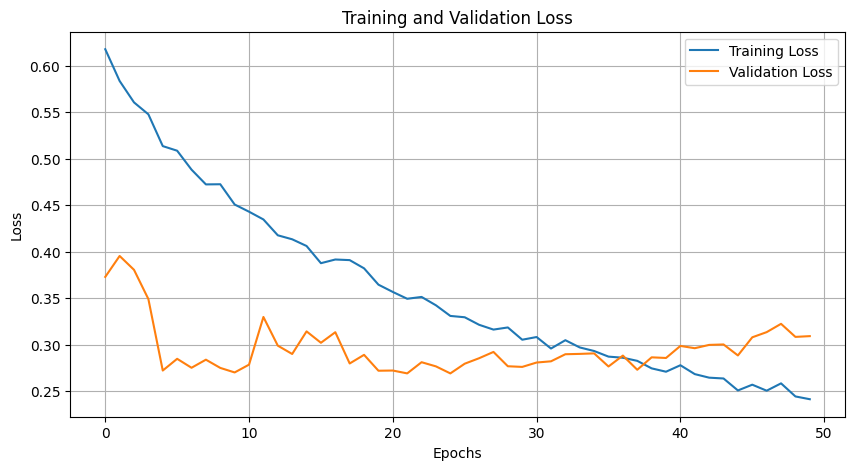

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(historyshy.history['loss'], label='Training Loss')
plt.plot(historyshy.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
predictionshy = modelshy.predict(X_testshy)
prediction_invshy = scaler_outputshy.inverse_transform(predictionshy)
prediction_invshy = prediction_invshy.flatten()
y_test_invshy = scaler_outputshy.inverse_transform(y_testshy)

valuesshy = np.array(y_test_invshy)
valuesshy = valuesshy.flatten()

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


In [67]:
from sklearn.metrics import r2_score, mean_absolute_error

# Example (replace with your actual y_test and y_pred arrays)
r2 = r2_score(y_test_invshy, prediction_invshy)
print(f'R-squared: {r2:.4f}')
mae = mean_absolute_error(y_test_invshy, prediction_invshy)
print(f'Mean Absolute Error (MAE): {mae:.4f}')



R-squared: -0.1823
Mean Absolute Error (MAE): 0.4095


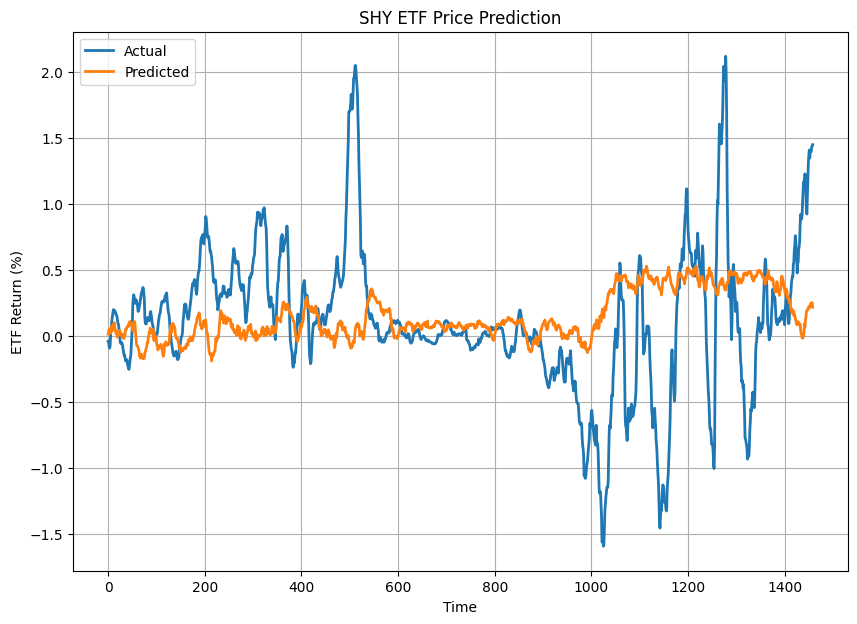

In [68]:


# Example (replace with your actual y_test and y_pred arrays)
# Plot results
plt.figure(figsize=(10, 7))
plt.plot(y_test_invshy, label='Actual', linewidth=2)
plt.plot(prediction_invshy, label='Predicted', linewidth=2)
plt.title('SHY ETF Price Prediction')
plt.xlabel('Time')
plt.ylabel('ETF Return (%)')
plt.legend()
plt.grid(True)
plt.show()


In [69]:
df_predictionsshy = pd.DataFrame(
    {"Date": test_timeshy, "Pred RNN": prediction_invshy, "Actual_values": valuesshy}
)
df_predictionsshy.Date = pd.to_datetime(df_predictionsshy.Date, format="%Y-%m-%d")
df_predictionsshy.head()

,Date,Pred RNN,Actual_values
0,2018-02-07,0.014672,-0.039734
1,2018-02-08,0.029818,-0.044016
2,2018-02-09,0.051573,-0.074754
3,2018-02-12,0.042373,-0.091307
4,2018-02-13,0.019159,-0.078374


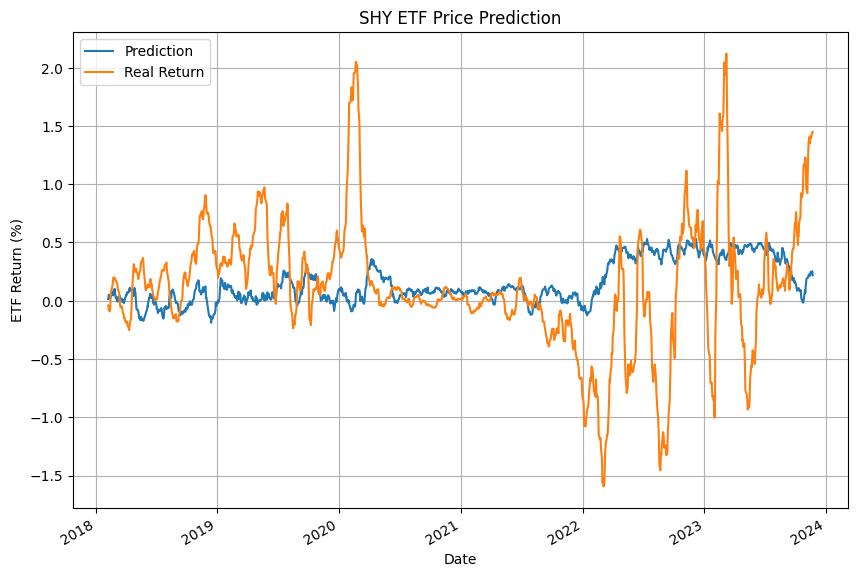

In [70]:
import matplotlib.pyplot as plt

plt_1 = plt.figure(figsize=(10, 7))
ax = plt.gca()
df_predictionsshy.plot(x="Date", y="Pred RNN", label="Prediction", ax=ax)
df_predictionsshy.plot(x="Date", y="Actual_values", label="Real Return", ax=ax)
plt.title('SHY ETF Price Prediction')
plt.xlabel('Date')
plt.ylabel('ETF Return (%)')
plt.legend()
plt.grid(True)

plt.show()

## Precious metals (Gold) 🡪 SPDR Gold Shares. Symbol: “GLD”

In [71]:

# Download gld data from 2014 to 2022
vgld1 = yf.download('GLD', start='2010-01-01', end='2023-12-31')

# Use only the 'Adj Close' for simplicity
#vgld1 = vgld1[['Close']].rename(columns={'Close, gld': 'Close'})
vgld1.columns = vgld1.columns.droplevel(1)
vgld1['Open_diff'] = vgld1['Open'].diff()

vgld1['Returns'] = vgld1['Close'].pct_change()
vgld1['Returns'] = vgld1['Returns']*100
vgld1['MA7'] = vgld1['Close'].rolling(window=5).mean()
vgld1['MA11'] = vgld1['Returns'].rolling(window=11).mean()
vgld1['MA21'] = vgld1['Returns'].rolling(window=21).mean()
vgld1['MA31'] = vgld1['Returns'].rolling(window=31).mean()
vgld1['VA7'] = vgld1['Close'].rolling(window=5).std()
vgld1['VA11'] = vgld1['Close'].rolling(window=11).std()
vgld1['VA21'] = vgld1['Close'].rolling(window=21).std()
vgld1['VA31'] = vgld1['Close'].rolling(window=31).std()


returns = vgld1['Returns'].dropna()

garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# === Shift vgld1 to align with GARCH output ===
vgld1 = vgld1.iloc[1:].copy()  # Drop first row to match returns length


vgld1['GARCH_vol'] = garch_result.conditional_volatility

# === Optional: Forward fill any possible edge NaNs ===
vgld1['GARCH_vol'] = vgld1['GARCH_vol'].fillna(method='bfill')
vgld1['GARCH_vol']=vgld1['GARCH_vol']*100
# # === Add Volatility Regime Indicator ===
vgld1['Volatility_Regime'] = (vgld1['GARCH_vol'] > vgld1['GARCH_vol'].rolling(window=3).median()).astype(int)
vgld1['Volatility_Regime5'] = (vgld1['GARCH_vol'] > vgld1['GARCH_vol'].rolling(window=5).median()).astype(int)
vgld1['Volatility_Regime1'] =  (vgld1['GARCH_vol'] > vgld1['GARCH_vol'].rolling(window=10).median()).astype(int)
vgld1['Volatility_Regime2'] = (vgld1['GARCH_vol'] > vgld1['GARCH_vol'].rolling(window=15).median()).astype(int)
vgld1['Volatility_Regime3'] =  (vgld1['GARCH_vol'] > vgld1['GARCH_vol'].rolling(window=25).median()).astype(int)
# # One-hot encode the Volatility_Regime column
volatility_dummies = pd.get_dummies(vgld1['Volatility_Regime'], prefix='Volatility_Regime')
vgld1['Noise1'] = vgld1['Close'] - vgld1['Close'].rolling(window=3).mean()
vgld1['GARCH2'] = vgld1['GARCH_vol'].astype(int).rolling(window=5).max()
vgld1['GARCH3'] =  vgld1['GARCH_vol'].astype(int).rolling(window=5).min()
vgld1['GARCH4'] =  vgld1['GARCH_vol'].rolling(window=10).max()
vgld1['GARCH5'] = vgld1['GARCH_vol'].rolling(window=10).min()
#vgld1['Noise6'] = vgld1['Returns'] - vgld1['Close'] - vgld1['Close'].astype(int).rolling(window=7).mean()
#vgld1['Noise7'] =  vgld1['Close']-vgld1['GARCH_vol'].astype(int).rolling(window=11).mean()
# # Concatenate the one-hot columns back to the dataframe
vgld1 = pd.concat([vgld1, volatility_dummies], axis=1)

# === Define Volatility Regimes (4 Classes) ===
quantiles = vgld1['GARCH_vol'].quantile([0.2, 0.3, 0.5, 0.7,0.8])

def classify_volatility(vol):
    if vol <= quantiles[0.2]:
        return "Very Low"
    elif vol <= quantiles[0.3]:
        return "Low"
    elif vol <= quantiles[0.5]:
        return "Medium"
    elif vol <= quantiles[0.7]:
        return "High"
    elif vol <= quantiles[0.8]:
        return "Very High"
    else:
        return "Very Very High"

vgld1['Volatility_Regime'] = vgld1['GARCH_vol'].apply(classify_volatility)

# === One-Hot Encode the 4 Classes ===
volatility_dummies = pd.get_dummies(vgld1['Volatility_Regime'], prefix='Volatility_Regime')

# === Add One-Hot Columns to DataFrame ===
vgld1 = pd.concat([vgld1, volatility_dummies], axis=1)



# Drop the original 'Volatility_Regime' column if you don't need it anymore
vgld1 = vgld1.drop(columns=['Volatility_Regime'])
# === Add GARCH Residuals ===
vgld1['GARCH_residuals3'] = vgld1['Returns'] - vgld1['GARCH_vol'].shift(3)
vgld1['GARCH_residuals10'] = vgld1['Returns'] -vgld1['GARCH_vol'].shift(5)
vgld1['GARCH_residuals20'] = vgld1['Returns'] -vgld1['GARCH_vol'].shift(10)
vgld1['GARCH_residuals30'] = vgld1['Returns'] -vgld1['GARCH_vol'].shift(30)
# === Add Rolling Volatility (alternative to GARCH if you want) ===
vgld1['RollingVolatility_11d'] = vgld1['Returns'].rolling(window=11).std()
vgld1['RollingVolatility_21d'] = vgld1['Returns'].rolling(window=21).std()
vgld1['RollingVolatility_5d'] = vgld1['Returns'].rolling(window=5).std()
#del vgld1["Volume"]

vgld1['Return+25'] = vgld1['Close'].shift(-25) / vgld1['Close'] - 1
vgld1['Return+25'] = vgld1['Return+25']*100
vgld1['Return+25_Denoised']= vgld1['Return+25'].ewm(span=5, adjust=False).mean()
vgld1['Noise'] = vgld1['Return+25'] - vgld1['Return+25_Denoised']
#vshy1['Output'] = vshy1['Return+25_Denoised']
vgld1["Output"] = vgld1['Return+25_Denoised']

vgld1=pd.DataFrame(vgld1)
# Create additional features

# Split into training, validation, and test
vtraingld1 = vgld1.loc['2010-01-01':'2017-12-31']
vtestgld1 = vgld1.loc['2018-01-01':'2023-12-30']
vtestgld1=vtestgld1[:-25]
# Create Validation Set (20% of Training Data)
vval_size1 = int(0.2 * len(vtraingld1))
vtraingld_set1 = vtraingld1.iloc[:-vval_size1]
vvalgld_set1 = vtraingld1.iloc[-vval_size1:]

# Confirm Data Split
print ()
print(f"Training Set: {vtraingld_set1.index.min()} to {vtraingld_set1.index.max()}")
print(f"Validation Set: {vvalgld_set1.index.min()} to {vvalgld_set1.index.max()}")
print(f"Test Set: {vtestgld1.index.min()} to {vtestgld1.index.max()}")

[*********************100%***********************]  1 of 1 completed


Training Set: 2010-01-05 00:00:00 to 2016-05-26 00:00:00
Validation Set: 2016-05-27 00:00:00 to 2017-12-29 00:00:00
Test Set: 2018-01-02 00:00:00 to 2023-11-22 00:00:00



<ipython-input-71-9ff4b7fcef87>:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vgld1['GARCH_vol'] = vgld1['GARCH_vol'].fillna(method='bfill')


In [72]:
# Drop NaN values
vtraingld_set1.dropna(inplace=True)
vvalgld_set1.dropna(inplace=True)
vtestgld1.dropna(inplace=True)
# Prepare features
featuresgld = ['Open', 'Open_diff','Returns', 'MA7', 'MA11','MA21','MA31',
             'VA7', 'VA11','VA21','VA31', 'GARCH_vol',
            'Volatility_Regime1','Volatility_Regime2', 'Volatility_Regime3', 'Volatility_Regime5',
            'Volatility_Regime_0','Volatility_Regime_1','Noise1','GARCH2','GARCH3',
            'GARCH4','GARCH5',
            'GARCH_residuals10', 'GARCH_residuals3',
            'GARCH_residuals20','GARCH_residuals30',
            'RollingVolatility_5d','RollingVolatility_11d',
            'RollingVolatility_21d',
            'Volatility_Regime_Very Low',
            'Volatility_Regime_Low',
            'Volatility_Regime_Medium',
            'Volatility_Regime_High',
            'Volatility_Regime_Very High','Volatility_Regime_Very Very High'
            ]
target = 'Close'

<ipython-input-72-a4d42c308832>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vtraingld_set1.dropna(inplace=True)
<ipython-input-72-a4d42c308832>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vvalgld_set1.dropna(inplace=True)


In [73]:
nfeatgld3=vtraingld_set1.shape[1]-1
nfeatgld3
window_size = 25  # How many daily prices do I want to incorporate in the input sequence for the network?

test_timegld = vtestgld1.index[window_size :]
test_timegld[:5]

DatetimeIndex(['2018-02-07', '2018-02-08', '2018-02-09', '2018-02-12',
               '2018-02-13'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [74]:
Xtraingld, Xvalgld,Xtestgld = vtraingld_set1.iloc[:, 0:nfeatgld3], vvalgld_set1.iloc[:,0:nfeatgld3],vtestgld1.iloc[:,0:nfeatgld3]
ytraingld, yvalgld, ytestgld = vtraingld_set1.iloc[:, -1], vvalgld_set1.iloc[:, -1],vtestgld1.iloc[:,-1]
Xtraingld = Xtraingld.astype("float32")
Xvalgld = Xvalgld.astype("float32")
Xtestgld = Xtestgld.astype("float32")
ytraingld = ytraingld.astype("float32")
yvalgld = yvalgld.astype("float32")
ytestgld = ytestgld.astype("float32")


In [75]:
training_time = Xtraingld.index
training_time
test_time = Xtestgld.index
test_time
n_featuresgld = Xtraingld.shape[1]
n_featuresgld

43

In [76]:
# Third, we proceed with scaling inputs to the model. Note how this is specially important now (compare to past tasks) because we are no longer dealing with returns, but with prices!
scaler_inputgld = MinMaxScaler(feature_range=(-1, 1))
scaler_inputgld.fit(Xtraingld[featuresgld])
X_traingld_scaled = scaler_inputgld.transform(Xtraingld[featuresgld])
X_valgld_scaled =scaler_inputgld.transform(Xvalgld[featuresgld])
X_testgld_scaled = scaler_inputgld.transform(Xtestgld[featuresgld])


In [77]:
mean_retgld = np.mean(ytraingld)

scaler_outputgld = MinMaxScaler(feature_range=(-1, 1))
ytrainsetgld = ytraingld.values.reshape(len(ytraingld), 1)
yvalsetgld = yvalgld.values.reshape(len(yvalgld), 1)
ytestsetgld = ytestgld.values.reshape(len(ytestgld), 1)
scaler_outputgld.fit(ytrainsetgld)
y_traingld_scaled = scaler_outputgld.transform(ytrainsetgld)
y_valgld_scaled = scaler_outputgld.transform(yvalsetgld)
y_testgld_scaled = scaler_outputgld.transform(ytestsetgld)

In [78]:
X_traingld = []
y_traingld = []
X_valgld=[]
y_valgld=[]
for i in range(window_size, y_traingld_scaled.shape[0]):
    X_traingld.append(X_traingld_scaled[i - window_size : i, :])
    y_traingld.append(y_traingld_scaled[i])
for i in range(window_size, y_valgld_scaled.shape[0]):
    X_valgld.append(X_valgld_scaled[i - window_size : i, :])
    y_valgld.append(y_valgld_scaled[i])
X_traingld, y_traingld = np.array(X_traingld), np.array(y_traingld)
X_valgld, y_valgld = np.array(X_valgld), np.array(y_valgld)
print ()
print("Size of X vector in training:", X_traingld.shape)
print("Size of Y vector in training:", y_traingld.shape)
print ()
print("Size of X vector in Validation:", X_valgld.shape)
print("Size of Y vector in Validation:", y_valgld.shape)
X_testgld = []
y_testgld = y_testgld_scaled[window_size:]

for i in range(window_size, y_testgld_scaled.shape[0]):
    X_testgld.append(X_testgld_scaled[i - window_size : i, :])


X_testgld, y_testgld = np.array(X_testgld), np.array(y_testgld)
print("Size of X vector in test:", X_testgld.shape)
print("Size of Y vector in test:", y_testgld.shape)
print("Number of features in the model: ", n_featuresgld)


Size of X vector in training: (1555, 25, 36)
Size of Y vector in training: (1555, 1)

Size of X vector in Validation: (377, 25, 36)
Size of Y vector in Validation: (377, 1)
Size of X vector in test: (1459, 25, 36)
Size of Y vector in test: (1459, 1)
Number of features in the model:  43


In [79]:
def fluctuation_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # Difference between consecutive days (fluctuations)
    fluct_true = y_true[:, 1:] - y_true[:, :-1]
    fluct_pred = y_pred[:, 1:] - y_pred[:, :-1]

    # Penalize difference between actual and predicted fluctuations
    fluct_penalty = tf.reduce_mean(tf.square(fluct_true - fluct_pred))

    # Combine both losses
def build_advanced_model(window_size, num_features):
    inputs = Input(shape=(window_size, num_features))

    # 1️⃣ Local feature extraction (short-term fluctuations)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    # 2️⃣ Long-term memory (trend)
    x = LSTM(64, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
   # x = LSTM(128, return_sequences=False)(x)
    # 3️⃣ Transformer-like Attention Block (for importance weighting)
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x, x)
    attn = Add()([x, attn])
    attn = LayerNormalization()(attn)

    # 4️⃣ More dense layers to learn complex mapping
    x = GlobalAveragePooling1D()(attn)
    x = Dense(128, activation='tanh')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='tanh')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='linear')(x)  # Predict 25-day return

    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=fluctuation_loss, metrics=['mae'])

    return model

# Build and Compile
modelgld = build_advanced_model(X_traingld.shape[1],X_traingld.shape[2])
modelgld.summary()




Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 25, 36)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_6 (Conv1D)         │ (None, 25, 32)         │          3,488 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 25, 32)         │            128 │ conv1d_6[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_14 (Dropout)      │ (None, 25, 32)         │              0 │ batch_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_7 (Conv1D)         │ (None, 25, 32)         │          3,104 │ dropout_14[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 25, 32)         │            128 │ conv1d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_15 (Dropout)      │ (None, 25, 32)         │              0 │ batch_normalization_7… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_7 (LSTM)             │ (None, 25, 64)         │         24,832 │ dropout_15[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_8 (LSTM)             │ (None, 25, 128)        │         98,816 │ lstm_7[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_2    │ (None, 25, 128)        │         33,088 │ lstm_8[0][0],          │
│ (MultiHeadAttention)      │                        │                │ lstm_8[0][0],          │
│                           │                        │                │ lstm_8[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 25, 128)        │              0 │ lstm_8[0][0],          │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_3     │ (None, 25, 128)        │            256 │ add_3[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d… │ (None, 128)            │              0 │ layer_normalization_3… │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 128)            │         16,512 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_17 (Dropout)      │ (None, 128)            │              0 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)      

 Total params: 188,673 (737.00 KB)

 Trainable params: 188,545 (736.50 KB)

 Non-trainable params: 128 (512.00 B)

In [80]:
def custom_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    fluct_penalty = tf.reduce_mean(tf.square(tf.abs(y_true - y_pred) - tf.abs(y_true.shift(1) - y_true)))
    return mse + 0.5 * fluct_penalty
hp_lr = 1e-4
modelgld.compile(
     optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr), loss="mean_absolute_error", metrics=["mean_absolute_error"]
 )

es = EarlyStopping(
    monitor="val_loss", mode="min", verbose=1, patience=25, restore_best_weights=True
)

In [81]:

# fit the models
historygld=modelgld.fit(
    X_traingld,
    y_traingld,
    validation_data=(X_valgld, y_valgld),
    epochs=500,
    batch_size=64,
    verbose=1,
    callbacks=[es],
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - loss: 0.7520 - mean_absolute_error: 0.7520 - val_loss: 0.2797 - val_mean_absolute_error: 0.2797
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - loss: 0.6717 - mean_absolute_error: 0.6717 - val_loss: 0.3680 - val_mean_absolute_error: 0.3680
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.6200 - mean_absolute_error: 0.6200 - val_loss: 0.3189 - val_mean_absolute_error: 0.3189
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.6198 - mean_absolute_error: 0.6198 - val_loss: 0.3048 - val_mean_absolute_error: 0.3048
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - loss: 0.5602 - mean_absolute_error: 0.5602 - val_loss: 0.2953 - val_mean_absolute_error: 0.2953
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.5491 - mean_absolute_error: 0.5491 - val_loss: 0.2908 - val_mean_absolute_error: 0.2908
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.5405 - mean_absolute_error: 0.

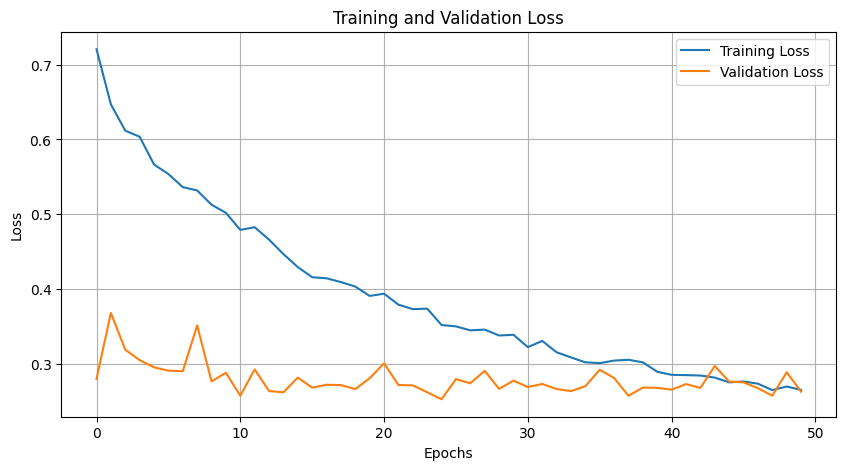

In [82]:
plt.figure(figsize=(10, 5))
plt.plot(historygld.history['loss'], label='Training Loss')
plt.plot(historygld.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [83]:
predictiongld = modelgld.predict(X_testgld)
prediction_invgld = scaler_outputgld.inverse_transform(predictiongld)
prediction_invgld = prediction_invgld.flatten()
y_test_invgld = scaler_outputgld.inverse_transform(y_testgld)

valuesgld = np.array(ytestsetgld[window_size:])
valuesgld = valuesgld.flatten()

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


In [84]:
from sklearn.metrics import r2_score

# Example (replace with your actual y_test and y_pred arrays)
r2 = r2_score(y_test_invgld, prediction_invgld)
print(f'R-squared: {r2:.4f}')
mae = mean_absolute_error(y_test_invgld, prediction_invgld)
print(f'Mean Absolute Error (MAE): {mae:.4f}')



R-squared: -0.4711
Mean Absolute Error (MAE): 3.7169


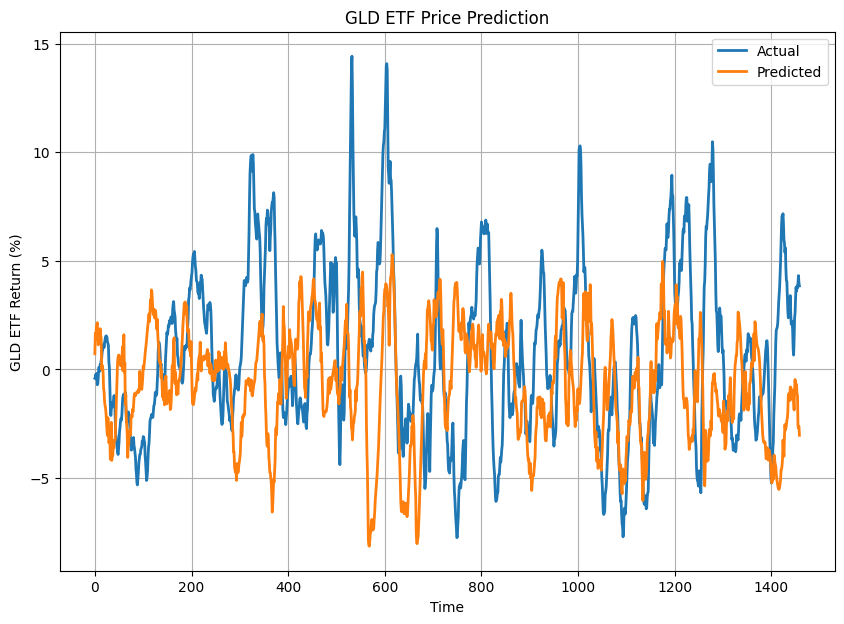

In [85]:


# Example (replace with your actual y_test and y_pred arrays)
# Plot results
plt1=plt.figure(figsize=(10, 7))
plt.plot(y_test_invgld, label='Actual', linewidth=2)
plt.plot(prediction_invgld, label='Predicted', linewidth=2)
plt.title('GLD ETF Price Prediction')
plt.xlabel('Time')
plt.ylabel('GLD ETF Return (%)')
plt.legend()
plt.grid(True)
plt.show()


In [86]:
df_predictionsgld = pd.DataFrame(
    {"Date": test_timegld.values, "Pred RNN": prediction_invgld, "Actual_values": valuesgld}
)
df_predictionsgld.Date = pd.to_datetime(df_predictionsgld.Date, format="%Y-%m-%d")
df_predictionsgld.head()

,Date,Pred RNN,Actual_values
0,2018-02-07,0.723248,-0.407712
1,2018-02-08,1.677728,-0.373159
2,2018-02-09,1.377764,-0.222055
3,2018-02-12,1.970335,-0.429871
4,2018-02-13,2.056257,-0.180827


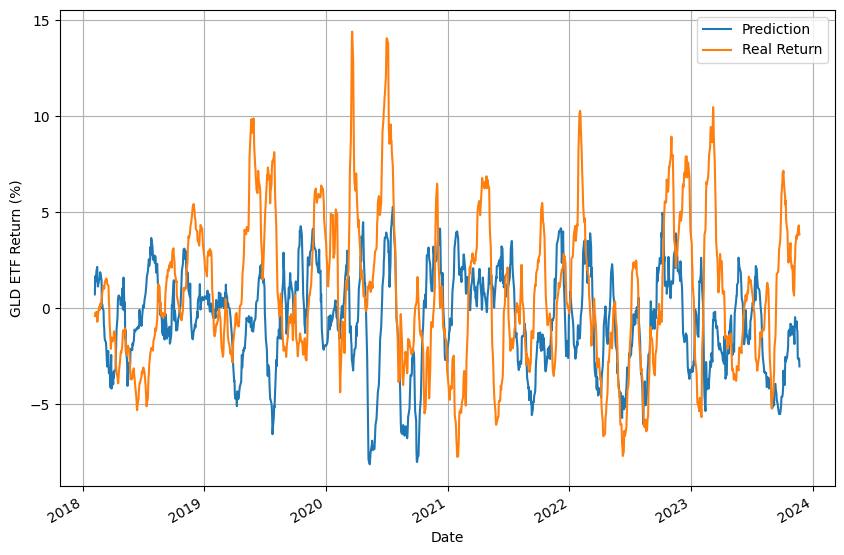

In [87]:

plt_1 = plt.figure(figsize=(10, 7))
ax = plt.gca()
df_predictionsgld.plot(x="Date", y="Pred RNN", label="Prediction", ax=ax)
df_predictionsgld.plot(x="Date", y="Actual_values", label="Real Return", ax=ax)
plt.xlabel('Date')
plt.ylabel('GLD ETF Return (%)')
plt.legend()
plt.grid(True)

plt.show()

## Crude Oil → Invesco DB Oil Fund. Symbol: “DBO”


In [88]:

# Download dbo data from 2014 to 2022
vdbo1 = yf.download('DBO', start='2010-01-01', end='2023-12-31')

# Use only the 'Adj Close' for simplicity
#vdbo1 = vdbo1[['Close']].rename(columns={'Close, dbo': 'Close'})
vdbo1.columns = vdbo1.columns.droplevel(1)
vdbo1['Open_diff'] = vdbo1['Open'].diff()

vdbo1['Returns'] = vdbo1['Close'].pct_change()
vdbo1['Returns'] = vdbo1['Returns']*100
vdbo1['MA7'] = vdbo1['Returns'].rolling(window=5).mean().pct_change()
vdbo1['MA11'] = vdbo1['Returns'].rolling(window=11).mean().pct_change()
vdbo1['MA21'] = vdbo1['Returns'].rolling(window=21).mean().pct_change()
vdbo1['MA31'] = vdbo1['Returns'].rolling(window=31).mean().pct_change()
vdbo1['VA7'] = vdbo1['Close'].rolling(window=5).std().pct_change()
vdbo1['VA11'] = vdbo1['Close'].rolling(window=11).std().pct_change()
vdbo1['VA21'] = vdbo1['Close'].rolling(window=21).std().pct_change()
vdbo1['VA31'] = vdbo1['Close'].rolling(window=31).std().pct_change()


returns = vdbo1['Returns'].dropna()

garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

# === Shift vdbo1 to align with GARCH output ===
vdbo1 = vdbo1.iloc[1:].copy()  # Drop first row to match returns length


vdbo1['GARCH_vol'] = garch_result.conditional_volatility

# === Optional: Forward fill any possible edge NaNs ===
vdbo1['GARCH_vol'] = vdbo1['GARCH_vol'].fillna(method='bfill')
vdbo1['GARCH_vol']=vdbo1['GARCH_vol']*100
# # === Add Volatility Regime Indicator ===
vdbo1['Volatility_Regime'] = (vdbo1['GARCH_vol'] > vdbo1['GARCH_vol'].rolling(window=3).median()).astype(int)
vdbo1['Volatility_Regime5'] = (vdbo1['GARCH_vol'] > vdbo1['GARCH_vol'].rolling(window=5).median()).astype(int)
vdbo1['Volatility_Regime1'] =  (vdbo1['GARCH_vol'] > vdbo1['GARCH_vol'].rolling(window=10).median()).astype(int)
vdbo1['Volatility_Regime2'] = (vdbo1['GARCH_vol'] > vdbo1['GARCH_vol'].rolling(window=15).median()).astype(int)
vdbo1['Volatility_Regime3'] =  (vdbo1['GARCH_vol'] > vdbo1['GARCH_vol'].rolling(window=25).median()).astype(int)
# # One-hot encode the Volatility_Regime column
volatility_dummies = pd.get_dummies(vdbo1['Volatility_Regime'], prefix='Volatility_Regime')
vdbo1['Noise1'] = vdbo1['Close'] - vdbo1['Close'].rolling(window=3).mean()
vdbo1['GARCH2'] = vdbo1['GARCH_vol'].astype(int).rolling(window=5).max()
vdbo1['GARCH3'] = vdbo1['GARCH_vol'].astype(int).rolling(window=5).min()
vdbo1['GARCH4'] = vdbo1['GARCH_vol'].rolling(window=10).max()
vdbo1['GARCH5'] = vdbo1['GARCH_vol'].rolling(window=10).min()
#vdbo1['Noise6'] = vdbo1['Close'] - vdbo1['Close'].astype(int).rolling(window=7).mean()
#vdbo1['Noise7'] =  vdbo1['Close']-vdbo1['GARCH_vol'].astype(int).rolling(window=11).mean()
# # Concatenate the one-hot columns back to the dataframe
vdbo1 = pd.concat([vdbo1, volatility_dummies], axis=1)

# === Define Volatility Regimes (4 Classes) ===
quantiles = vdbo1['GARCH_vol'].quantile([0.2, 0.3, 0.5, 0.7,0.8])

def classify_volatility(vol):
    if vol <= quantiles[0.2]:
        return "Very Low"
    elif vol <= quantiles[0.3]:
        return "Low"
    elif vol <= quantiles[0.5]:
        return "Medium"
    elif vol <= quantiles[0.7]:
        return "High"
    elif vol <= quantiles[0.8]:
        return "Very High"
    else:
        return "Very Very High"

vdbo1['Volatility_Regime'] = vdbo1['GARCH_vol'].apply(classify_volatility)

# === One-Hot Encode the 4 Classes ===
volatility_dummies = pd.get_dummies(vdbo1['Volatility_Regime'], prefix='Volatility_Regime')

# === Add One-Hot Columns to DataFrame ===
vdbo1 = pd.concat([vdbo1, volatility_dummies], axis=1)



# Drop the original 'Volatility_Regime' column if you don't need it anymore
vdbo1 = vdbo1.drop(columns=['Volatility_Regime'])
# === Add GARCH Residuals ===
vdbo1['GARCH_residuals3'] = vdbo1['Returns'].shift(3) - vdbo1['GARCH_vol']
vdbo1['GARCH_residuals10'] = vdbo1['Returns'].shift(5) - vdbo1['GARCH_vol']
vdbo1['GARCH_residuals20'] = vdbo1['Returns'].shift(10) - vdbo1['GARCH_vol']
vdbo1['GARCH_residuals30'] = vdbo1['Returns'].shift(30) - vdbo1['GARCH_vol']
# === Add Rolling Volatility (alternative to GARCH if you want) ===
vdbo1['RollingVolatility_11d'] = vdbo1['Returns'].rolling(window=11).std()
vdbo1['RollingVolatility_21d'] = vdbo1['Returns'].rolling(window=21).std()
vdbo1['RollingVolatility_5d'] = vdbo1['Returns'].rolling(window=5).std()
#del vdbo1["Volume"]

vdbo1['Return+25'] = vdbo1['Close'].shift(-25) / vdbo1['Close'] - 1
vdbo1['Return+25'] = vdbo1['Return+25']*100
vdbo1['Return+25_Denoised']= vdbo1['Return+25'].ewm(span=5, adjust=False).mean()
vdbo1['Noise'] = vdbo1['Return+25'] - vdbo1['Return+25_Denoised']
vdbo1['Output'] = vdbo1['Return+25_Denoised']

vdbo1=pd.DataFrame(vdbo1)
# Create additional features

# Split into training, validation, and test
vtraindbo1 = vdbo1.loc['2010-01-01':'2017-12-31']
vtestdbo1 = vdbo1.loc['2018-01-01':'2023-12-30']
vtestdbo1 =vtestdbo1 [:-25]
# Create Validation Set (20% of Training Data)
vval_size1 = int(0.2 * len(vtraindbo1))
vtraindbo_set1 = vtraindbo1.iloc[:-vval_size1]
vvaldbo_set1 = vtraindbo1.iloc[-vval_size1:]

# Confirm Data Split
print ()
print(f"Training Set: {vtraindbo_set1.index.min()} to {vtraindbo_set1.index.max()}")
print(f"Validation Set: {vvaldbo_set1.index.min()} to {vvaldbo_set1.index.max()}")
print(f"Test Set: {vtestdbo1.index.min()} to {vtestdbo1.index.max()}")

[*********************100%***********************]  1 of 1 completed


Training Set: 2010-01-05 00:00:00 to 2016-05-26 00:00:00
Validation Set: 2016-05-27 00:00:00 to 2017-12-29 00:00:00
Test Set: 2018-01-02 00:00:00 to 2023-11-22 00:00:00



<ipython-input-88-508a2169f42c>:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  vdbo1['GARCH_vol'] = vdbo1['GARCH_vol'].fillna(method='bfill')


In [89]:
# Drop NaN values
vtraindbo_set1.dropna(inplace=True)
vvaldbo_set1.dropna(inplace=True)
vtestdbo1.dropna(inplace=True)
# Prepare features
featuresdbo = ['Open', 'Open_diff','Returns', 'MA7', 'MA11','MA21','MA31',
             'VA7', 'VA11','VA21','VA31', 'GARCH_vol',
            'Volatility_Regime1','Volatility_Regime2', 'Volatility_Regime3', 'Volatility_Regime5',
            'Volatility_Regime_0','Volatility_Regime_1','Noise1',
            'GARCH2','GARCH3',
            'GARCH4','GARCH5',
            'GARCH_residuals10', 'GARCH_residuals3',
            'GARCH_residuals20','GARCH_residuals30',
            'RollingVolatility_5d','RollingVolatility_11d',
            'RollingVolatility_21d',
            'Volatility_Regime_Very Low',
            'Volatility_Regime_Low',
            'Volatility_Regime_Medium',
            'Volatility_Regime_High',
            'Volatility_Regime_Very High','Volatility_Regime_Very Very High'
            ]
target = 'Output'

<ipython-input-89-0a79f18f17db>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vtraindbo_set1.dropna(inplace=True)
<ipython-input-89-0a79f18f17db>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vvaldbo_set1.dropna(inplace=True)


In [90]:
nfeatdbo3=vtraindbo_set1.shape[1]-1
nfeatdbo3
window_size = 25  # How many daily prices do I want to incorporate in the input sequence for the network?

test_time = vtestdbo1.index[window_size :]
test_time[:5]

DatetimeIndex(['2018-02-07', '2018-02-08', '2018-02-09', '2018-02-12',
               '2018-02-13'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [91]:
Xtraindbo, Xvaldbo,Xtestdbo = vtraindbo_set1.iloc[:, 0:nfeatdbo3], vvaldbo_set1.iloc[:,0:nfeatdbo3],vtestdbo1.iloc[:,0:nfeatdbo3]
ytraindbo, yvaldbo, ytestdbo = vtraindbo_set1.iloc[:, -1], vvaldbo_set1.iloc[:, -1],vtestdbo1.iloc[:,-1]
Xtraindbo = Xtraindbo.astype("float32")
Xvaldbo = Xvaldbo.astype("float32")
Xtestdbo = Xtestdbo.astype("float32")
ytraindbo = ytraindbo.astype("float32")
yvaldbo = yvaldbo.astype("float32")
ytestdbo = ytestdbo.astype("float32")


In [92]:
training_time = Xtraindbo.index
training_time
test_timedbo = Xtestdbo.index[window_size:]
test_timedbo
n_featuresdbo = Xtraindbo.shape[1]
n_featuresdbo

43

In [93]:
# Third, we proceed with scaling inputs to the model. Note how this is specially important now (compare to past tasks) because we are no longer dealing with returns, but with prices!
scaler_inputdbo = MinMaxScaler(feature_range=(-1, 1))
scaler_inputdbo.fit(Xtraindbo[featuresdbo])
X_traindbo_scaled = scaler_inputdbo.transform(Xtraindbo[featuresdbo])
X_valdbo_scaled =scaler_inputdbo.transform(Xvaldbo[featuresdbo])
X_testdbo_scaled = scaler_inputdbo.transform(Xtestdbo[featuresdbo])


In [94]:
mean_retdbo = np.mean(ytraindbo)

scaler_outputdbo = MinMaxScaler(feature_range=(-1, 1))
ytrainsetdbo = ytraindbo.values.reshape(len(ytraindbo), 1)
yvalsetdbo = yvaldbo.values.reshape(len(yvaldbo), 1)
ytestsetdbo = ytestdbo.values.reshape(len(ytestdbo), 1)
scaler_outputdbo.fit(ytrainsetdbo)
y_traindbo_scaled = scaler_outputdbo.transform(ytrainsetdbo)
y_valdbo_scaled = scaler_outputdbo.transform(yvalsetdbo)
y_testdbo_scaled = scaler_outputdbo.transform(ytestsetdbo)

In [95]:
X_traindbo = []
y_traindbo = []
X_valdbo=[]
y_valdbo=[]
for i in range(window_size, y_traindbo_scaled.shape[0]):
    X_traindbo.append(X_traindbo_scaled[i - window_size : i, :])
    y_traindbo.append(y_traindbo_scaled[i])
for i in range(window_size, y_valdbo_scaled.shape[0]):
    X_valdbo.append(X_valdbo_scaled[i - window_size : i, :])
    y_valdbo.append(y_valdbo_scaled[i])
X_traindbo, y_traindbo = np.array(X_traindbo), np.array(y_traindbo)
X_valdbo, y_valdbo = np.array(X_valdbo), np.array(y_valdbo)
print ()
print("Size of X vector in training:", X_traindbo.shape)
print("Size of Y vector in training:", y_traindbo.shape)
print ()
print("Size of X vector in Validation:", X_valdbo.shape)
print("Size of Y vector in Validation:", y_valdbo.shape)
X_testdbo = []
y_testdbo = y_testdbo_scaled[window_size:]

for i in range(window_size, y_testdbo_scaled.shape[0]):
    X_testdbo.append(X_testdbo_scaled[i - window_size : i, :])


X_testdbo, y_testdbo = np.array(X_testdbo), np.array(y_testdbo)
print("Size of X vector in test:", X_testdbo.shape)
print("Size of Y vector in test:", y_testdbo.shape)
print("Number of features in the model: ", n_featuresdbo)


Size of X vector in training: (1554, 25, 36)
Size of Y vector in training: (1554, 1)

Size of X vector in Validation: (377, 25, 36)
Size of Y vector in Validation: (377, 1)
Size of X vector in test: (1459, 25, 36)
Size of Y vector in test: (1459, 1)
Number of features in the model:  43


In [96]:
def fluctuation_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # Difference between consecutive days (fluctuations)
    fluct_true = y_true[:, 1:] - y_true[:, :-1]
    fluct_pred = y_pred[:, 1:] - y_pred[:, :-1]

    # Penalize difference between actual and predicted fluctuations
    fluct_penalty = tf.reduce_mean(tf.square(fluct_true - fluct_pred))

    # Combine both losses
def build_advanced_model(window_size, num_features):
    inputs = Input(shape=(window_size, num_features))

    # 1️⃣ Local feature extraction (short-term fluctuations)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(32, kernel_size=3, padding='causal', activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    # 2️⃣ Long-term memory (trend)
    x = LSTM(64, return_sequences=True)(x)
    x = LSTM(128, return_sequences=True)(x)
   # x = LSTM(128, return_sequences=False)(x)
    # 3️⃣ Transformer-like Attention Block (for importance weighting)
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x, x)
    attn = Add()([x, attn])
    attn = LayerNormalization()(attn)

    # 4️⃣ More dense layers to learn complex mapping
    x = GlobalAveragePooling1D()(attn)
    x = Dense(128, activation='tanh')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='tanh')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='linear')(x)  # Predict 25-day return

    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss=fluctuation_loss, metrics=['mae'])

    return model

# Build and Compile
modeldbo = build_advanced_model(X_traindbo.shape[1],X_traindbo.shape[2])
modeldbo.summary()




Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 25, 36)         │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_8 (Conv1D)         │ (None, 25, 32)         │          3,488 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 25, 32)         │            128 │ conv1d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_19 (Dropout)      │ (None, 25, 32)         │              0 │ batch_normalization_8… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_9 (Conv1D)         │ (None, 25, 32)         │          3,104 │ dropout_19[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 25, 32)         │            128 │ conv1d_9[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_20 (Dropout)      │ (None, 25, 32)         │              0 │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_9 (LSTM)             │ (None, 25, 64)         │         24,832 │ dropout_20[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_10 (LSTM)            │ (None, 25, 128)        │         98,816 │ lstm_9[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_3    │ (None, 25, 128)        │         33,088 │ lstm_10[0][0],         │
│ (MultiHeadAttention)      │                        │                │ lstm_10[0][0],         │
│                           │                        │                │ lstm_10[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 25, 128)        │              0 │ lstm_10[0][0],         │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_4     │ (None, 25, 128)        │            256 │ add_4[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d… │ (None, 128)            │              0 │ layer_normalization_4… │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 128)            │         16,512 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_22 (Dropout)      │ (None, 128)            │              0 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)     

 Total params: 188,673 (737.00 KB)

 Trainable params: 188,545 (736.50 KB)

 Non-trainable params: 128 (512.00 B)

In [97]:
def custom_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    fluct_penalty = tf.reduce_mean(tf.square(tf.abs(y_true - y_pred) - tf.abs(y_true.shift(1) - y_true)))
    return mse + 0.5 * fluct_penalty
hp_lr = 1e-4
modeldbo.compile(
     optimizer=tf.keras.optimizers.Adam(learning_rate=hp_lr), loss="mean_absolute_error", metrics=["mean_absolute_error"]
)

es = EarlyStopping(
    monitor="val_loss", mode="min", verbose=1, patience=25, restore_best_weights=True
)

In [98]:

# fit the models
historydbo=modeldbo.fit(
    X_traindbo,
    y_traindbo,
    validation_data=(X_valdbo, y_valdbo),
    epochs=500,
    batch_size=64,
    verbose=1,
    callbacks=[es],
)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - loss: 0.6177 - mean_absolute_error: 0.6177 - val_loss: 0.2921 - val_mean_absolute_error: 0.2921
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.5564 - mean_absolute_error: 0.5564 - val_loss: 0.2683 - val_mean_absolute_error: 0.2683
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 0.5281 - mean_absolute_error: 0.5281 - val_loss: 0.2788 - val_mean_absolute_error: 0.2788
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.5377 - mean_absolute_error: 0.5377 - val_loss: 0.2735 - val_mean_absolute_error: 0.2735
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.5177 - mean_absolute_error: 0.5177 - val_loss: 0.2591 - val_mean_absolute_error: 0.2591
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.4995 - mean_absolute_error: 0.4995 - val_loss: 0.3054 - val_mean_absolute_error: 0.3054
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - loss: 0.4847 - mean_absolute_error: 0.

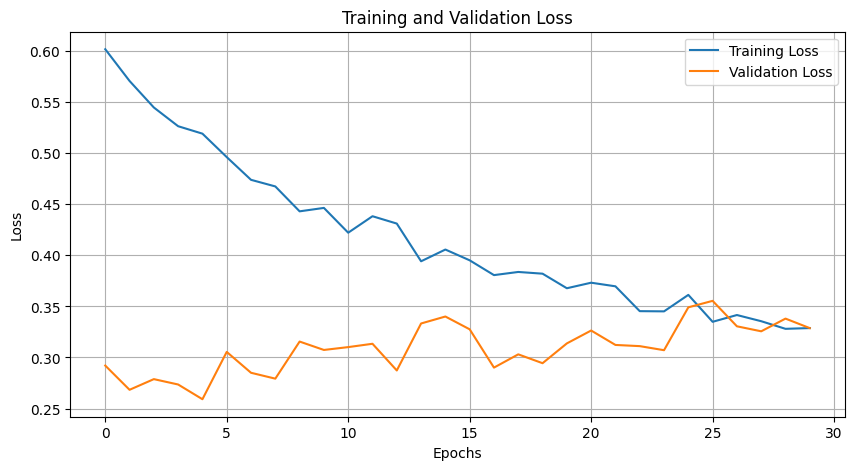

In [99]:
plt.figure(figsize=(10, 5))
plt.plot(historydbo.history['loss'], label='Training Loss')
plt.plot(historydbo.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
predictiondbo = modeldbo.predict(X_testdbo)
prediction_invdbo = scaler_outputdbo.inverse_transform(predictiondbo)
prediction_invdbo = prediction_invdbo.flatten()
y_test_invdbo = scaler_outputdbo.inverse_transform(y_testdbo)

valuesdbo = np.array(ytestsetdbo[window_size:])
valuesdbo = valuesdbo.flatten()

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


In [101]:


# Example (replace with your actual y_test and y_pred arrays)
r2 = r2_score(y_test_invdbo, prediction_invdbo)
print(f'R-squared: {r2:.4f}')
mae= mean_absolute_error(y_test_invdbo, prediction_invdbo)
print(f'Mean Absolute Error (MAE): {mae:.4f}')


R-squared: -0.0339
Mean Absolute Error (MAE): 7.7663


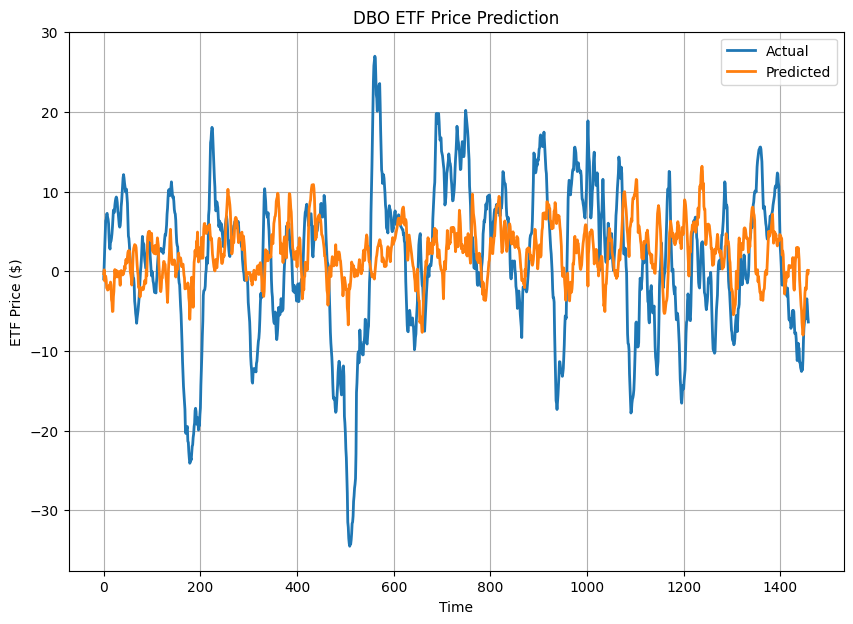

In [102]:


# Example (replace with your actual y_test and y_pred arrays)
# Plot results
plt.figure(figsize=(10, 7))
plt.plot(y_test_invdbo, label='Actual', linewidth=2)
plt.plot(prediction_invdbo, label='Predicted', linewidth=2)
plt.title('DBO ETF Price Prediction')
plt.xlabel('Time')
plt.ylabel('ETF Price ($)')
plt.legend()
plt.grid(True)
plt.show()


In [103]:
df_predictionsdbo = pd.DataFrame(
    {"Date": test_timedbo.values, "Pred RNN": prediction_invdbo, "Actual_values": valuesdbo}
)
df_predictionsdbo.Date = pd.to_datetime(df_predictionsdbo.Date, format="%Y-%m-%d")
df_predictionsdbo.head()

,Date,Pred RNN,Actual_values
0,2018-02-07,-0.312275,-0.971826
1,2018-02-08,0.177025,1.005815
2,2018-02-09,-1.227942,2.855246
3,2018-02-12,-0.742830,4.475209
4,2018-02-13,-0.612707,6.366069


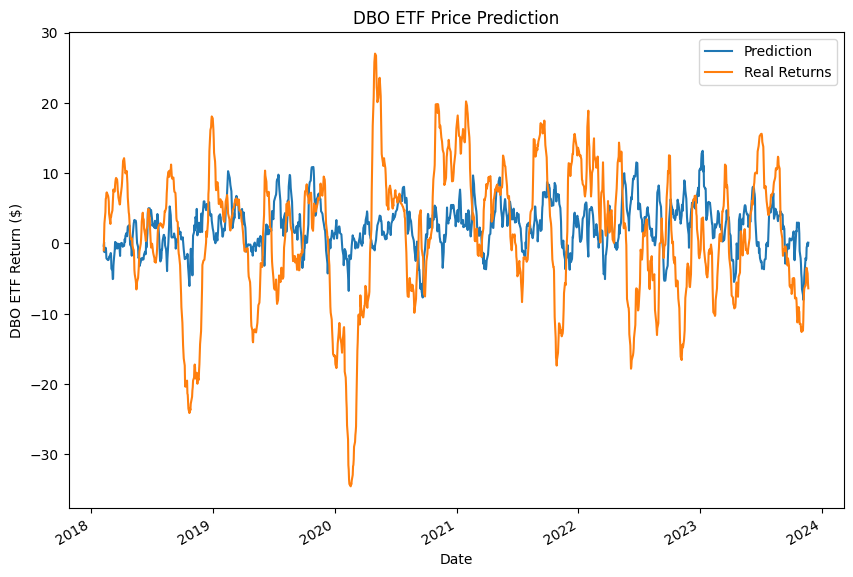

In [104]:

plt_1 = plt.figure(figsize=(10, 7))
ax = plt.gca()
df_predictionsdbo.plot(x="Date", y="Pred RNN", label="Prediction", ax=ax)
df_predictionsdbo.plot(x="Date", y="Actual_values", label="Real Returns", ax=ax)
plt.title('DBO ETF Price Prediction')
plt.xlabel('Date')
plt.ylabel('DBO ETF Return ($)')
plt.legend()
plt.grid(True)
plt.grid()
plt.show()

In [105]:
df_predictions = pd.DataFrame(
    {"Date": test_timespy.values,
     "Pred RNN(SPY)": pred_final.astype(float), #"Actual_valuesSPY": valuesspy},
     "Pred RNN(TLT)": prediction_invtlt.astype(float), #"Actual_valuesTLT": valuestlt},
   #  "Pred RNN(SHY)": y_final_predshy.flatten().astype(float), # "Actual_valuesSHY": ytestshy_final2.flatten()
     "Pred RNN(GLD)": prediction_invgld.astype(float), #"Actual_valuesGLD": valuesgld,
    "Pred RNN(DBO)": prediction_invdbo.astype(float), #"Actual_valuesDBO": valuesdbo}

    }
)
df_predictions.Date = pd.to_datetime(df_predictions.Date, format="%Y-%m-%d")

In [106]:
df_predictions2 = pd.DataFrame(
    {"Date": test_timespy.values,
     "Pred RNN(SPY)": actual_final.astype(float), #"Actual_valuesSPY": valuesspy},
     "Pred RNN(TLT)": prediction_invtlt.astype(float), #"Actual_valuesTLT": valuestlt},
     "Pred RNN(SHY)": prediction_invshy.flatten().astype(float), # "Actual_valuesSHY": ytestshy_final2.flatten()
     "Pred RNN(GLD)": prediction_invgld.astype(float), #"Actual_valuesGLD": valuesgld,
    "Pred RNN(DBO)": prediction_invdbo.astype(float), #"Actual_valuesDBO": valuesdbo}

    }
)
df_predictions2.Date = pd.to_datetime(df_predictions2.Date, format="%Y-%m-%d")

In [107]:
df_actuals = pd.DataFrame(
    {
        "Date": test_timespy.values,
        "Actual_valuesSPY": actual_final.astype(float),
        "Actual_valuesTLT": valuestlt.astype(float),
       # "Actual_valuesSHY": valuesshy.astype(float),
        "Actual_valuesGLD": valuesgld.astype(float),
        "Actual_valuesDBO": valuesdbo.astype(float),

      }
)
df_actuals.Date = pd.to_datetime(df_predictions.Date, format="%Y-%m-%d")

In [108]:
df_actuals2 = pd.DataFrame(
    {
        "Date": test_timespy.values,
        "Actual_valuesSPY": actual_final.astype(float),
        "Actual_valuesTLT": valuestlt.astype(float),
        "Actual_valuesSHY": valuesshy.astype(float),
        "Actual_valuesGLD": valuesgld.astype(float),
        "Actual_valuesDBO": valuesdbo.astype(float),

    }
)
df_actuals2.Date = pd.to_datetime(df_predictions2.Date, format="%Y-%m-%d")

In [109]:
df_predictions2.head()

,Date,Pred RNN(SPY),Pred RNN(TLT),Pred RNN(SHY),Pred RNN(GLD),Pred RNN(DBO)
0,2018-02-07,2.738443,1.612025,0.014672,0.723248,-0.312275
1,2018-02-08,6.857955,2.080931,0.029818,1.677728,0.177025
2,2018-02-09,3.852126,1.744088,0.051573,1.377764,-1.227942
3,2018-02-12,2.523250,1.049003,0.042373,1.970335,-0.742830
4,2018-02-13,2.072550,1.090995,0.019159,2.056257,-0.612707


In [110]:
df_actuals=df_actuals.set_index("Date")
df_actuals2=df_actuals2.set_index("Date")

In [111]:
#df_predictions=df_predictions.set_index("Date")
df_predictions2=df_predictions2.set_index("Date")

In [112]:
df_predictions=df_predictions.set_index("Date")

In [113]:
df_predictions.columns=["SPY","TLT","GLD","DBO"]
df_actuals.columns=["SPY","TLT","GLD","DBO"]

In [114]:
df_predictions2.columns=["SPY","TLT","SHY","GLD","DBO"]
df_actuals2.columns=["SPY","TLT","SHY","GLD","DBO"]

## Strategy1: Taking position based on top2 or bottom 2 ETFs

In [115]:
def trading_strategy(predictions, asset_names, rebalance_days=25):
    """
    predictions: DataFrame with predicted returns for each asset over time.
    asset_names: List of asset names (columns in predictions).
    rebalance_days: Frequency of rebalancing (default=25 days).

    Returns a DataFrame with long/short positions for each asset.
    """
    # Ensure predictions are numeric
    predictions = predictions.apply(pd.to_numeric, errors='coerce')

    # Create positions DataFrame with the same DateTimeIndex and asset names, initialized with 0's.
    positions = pd.DataFrame(0, index=predictions.index, columns=asset_names)

    # Iterate over the predictions in steps of rebalance_days.
    for i in range(0, len(predictions), rebalance_days):
        # Check if there are enough days left for a full rebalance period.
        if i + rebalance_days > len(predictions):
            break

        # Get the predictions for the current rebalancing day.
        pred_row = predictions.iloc[i]

        # Select the top 2 assets for long positions and bottom 2 for short positions.
        top_assets = pred_row.nlargest(2).index
        bottom_assets = pred_row.nsmallest(2).index

        # Use the corresponding date from the predictions index.
        current_date = predictions.index[i]

        # Assign positions: +1 for long (equal weight) and -1 for short (equal weight).
        positions.loc[current_date, top_assets] = 1 / len(top_assets)
        positions.loc[current_date, bottom_assets] = -1 / len(bottom_assets)

    return positions

In [116]:
# Get trading positions
positions2 = trading_strategy(df_predictions2, df_predictions2.columns)

# Display sample positions
print(positions2.head(30))

            SPY  TLT  SHY  GLD  DBO
Date                               
2018-02-07  0.5  0.5 -0.5  0.0 -0.5
2018-02-08  0.0  0.0  0.0  0.0  0.0
2018-02-09  0.0  0.0  0.0  0.0  0.0
2018-02-12  0.0  0.0  0.0  0.0  0.0
2018-02-13  0.0  0.0  0.0  0.0  0.0
2018-02-14  0.0  0.0  0.0  0.0  0.0
2018-02-15  0.0  0.0  0.0  0.0  0.0
2018-02-16  0.0  0.0  0.0  0.0  0.0
2018-02-20  0.0  0.0  0.0  0.0  0.0
2018-02-21  0.0  0.0  0.0  0.0  0.0
2018-02-22  0.0  0.0  0.0  0.0  0.0
2018-02-23  0.0  0.0  0.0  0.0  0.0
2018-02-26  0.0  0.0  0.0  0.0  0.0
2018-02-27  0.0  0.0  0.0  0.0  0.0
2018-02-28  0.0  0.0  0.0  0.0  0.0
2018-03-01  0.0  0.0  0.0  0.0  0.0
2018-03-02  0.0  0.0  0.0  0.0  0.0
2018-03-05  0.0  0.0  0.0  0.0  0.0
2018-03-06  0.0  0.0  0.0  0.0  0.0
2018-03-07  0.0  0.0  0.0  0.0  0.0
2018-03-08  0.0  0.0  0.0  0.0  0.0
2018-03-09  0.0  0.0  0.0  0.0  0.0
2018-03-12  0.0  0.0  0.0  0.0  0.0
2018-03-13  0.0  0.0  0.0  0.0  0.0
2018-03-14  0.0  0.0  0.0  0.0  0.0
2018-03-15 -0.5  0.5  0.5 -0

<ipython-input-115-326f2a743225>:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[current_date, top_assets] = 1 / len(top_assets)
<ipython-input-115-326f2a743225>:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[current_date, top_assets] = 1 / len(top_assets)
<ipython-input-115-326f2a743225>:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[current_date, bottom_assets] = -1 / len(bottom_assets)
<ipython-input-115-326f2a7

In [117]:
# Get trading positions
positions = trading_strategy(df_predictions, df_predictions.columns)

# Display sample positions
print(positions.head(30))

<ipython-input-115-326f2a743225>:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[current_date, top_assets] = 1 / len(top_assets)
<ipython-input-115-326f2a743225>:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[current_date, top_assets] = 1 / len(top_assets)
<ipython-input-115-326f2a743225>:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[current_date, bottom_assets] = -1 / len(bottom_assets)
<ipython-input-115-326f2a7

            SPY  TLT  GLD  DBO
Date                          
2018-02-07  0.5  0.5 -0.5 -0.5
2018-02-08  0.0  0.0  0.0  0.0
2018-02-09  0.0  0.0  0.0  0.0
2018-02-12  0.0  0.0  0.0  0.0
2018-02-13  0.0  0.0  0.0  0.0
2018-02-14  0.0  0.0  0.0  0.0
2018-02-15  0.0  0.0  0.0  0.0
2018-02-16  0.0  0.0  0.0  0.0
2018-02-20  0.0  0.0  0.0  0.0
2018-02-21  0.0  0.0  0.0  0.0
2018-02-22  0.0  0.0  0.0  0.0
2018-02-23  0.0  0.0  0.0  0.0
2018-02-26  0.0  0.0  0.0  0.0
2018-02-27  0.0  0.0  0.0  0.0
2018-02-28  0.0  0.0  0.0  0.0
2018-03-01  0.0  0.0  0.0  0.0
2018-03-02  0.0  0.0  0.0  0.0
2018-03-05  0.0  0.0  0.0  0.0
2018-03-06  0.0  0.0  0.0  0.0
2018-03-07  0.0  0.0  0.0  0.0
2018-03-08  0.0  0.0  0.0  0.0
2018-03-09  0.0  0.0  0.0  0.0
2018-03-12  0.0  0.0  0.0  0.0
2018-03-13  0.0  0.0  0.0  0.0
2018-03-14  0.0  0.0  0.0  0.0
2018-03-15  0.5  0.5 -0.5 -0.5
2018-03-16  0.0  0.0  0.0  0.0
2018-03-19  0.0  0.0  0.0  0.0
2018-03-20  0.0  0.0  0.0  0.0
2018-03-21  0.0  0.0  0.0  0.0


In [118]:
# Plot the strategy's positions over time
def plot_positions(positions):
    plt.figure(figsize=(12, 6))
    for asset in positions.columns:
        plt.plot(positions.index, positions[asset], label=asset)
    plt.axhline(0, color='black', linewidth=1, linestyle='dashed')
    plt.legend()
    plt.title("Trading Strategy Positions Over Time")
    plt.xlabel("Days")
    plt.ylabel("Position Size")
    plt.show()



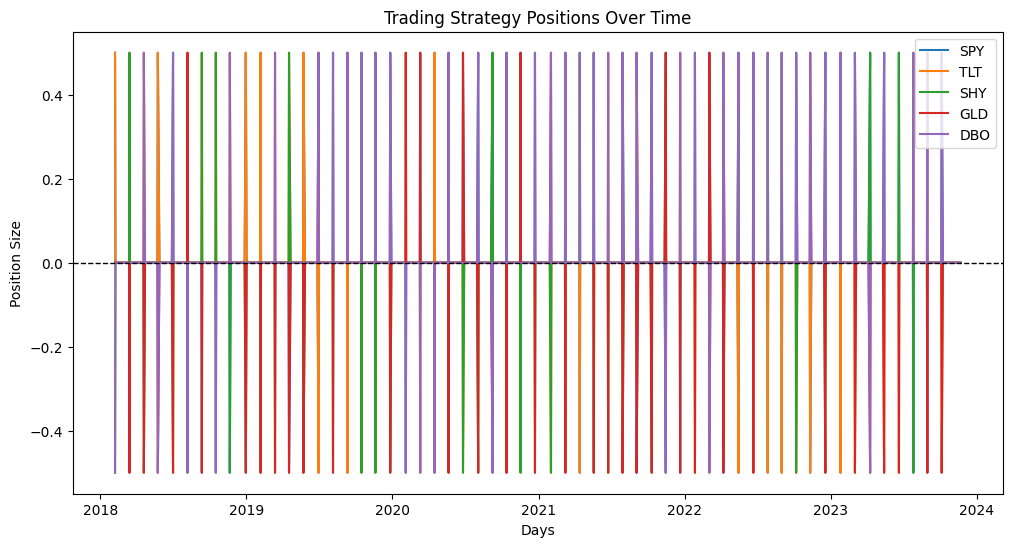

In [119]:
plot_positions(positions2)


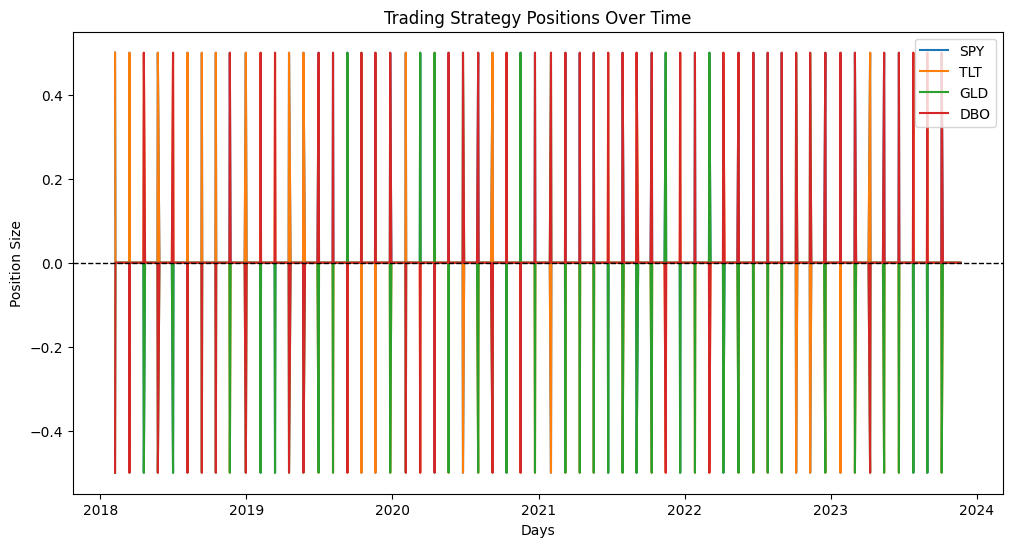

In [120]:
plot_positions(positions)

In [121]:
def plot_cumulative_returns(positions, df_returns):
    """
    Computes and plots cumulative returns of the trading strategy.

    Parameters:
      positions: DataFrame of positions (weights) with DateTimeIndex and asset columns.
      df_returns: DataFrame of daily returns with DateTimeIndex and matching asset columns.

    The strategy's daily return is calculated as the sum over assets of
    (forward-filled position * asset return). Cumulative return is computed as the product of (1 + daily_return).
    """
    # Ensure both DataFrames are aligned on dates
    positions = positions.reindex(df_returns.index).fillna(0)  # Align and fill positions
    df_returns = df_returns.reindex(positions.index).fillna(0)
    #df_returns = df_returns.loc[positions.index]

    # Forward-fill positions so that positions persist until next rebalancing.
    positions_ff = positions.ffill()

    # Compute daily strategy returns as the weighted sum of asset returns.
    # (Assuming positions represent weights.)
    strategy_daily_return = (positions_ff * df_returns).sum(axis=1)

    # Compute cumulative returns. Starting with an initial value of 1.
    cumulative_returns = (1 + strategy_daily_return).cumprod() - 1

    # Plot the cumulative returns
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_returns.index, cumulative_returns, label="Strategy Cumulative Return", color="blue")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.title("Cumulative Returns of Trading Strategy")
    plt.legend()
    plt.grid(True)
    plt.show()

    return cumulative_returns


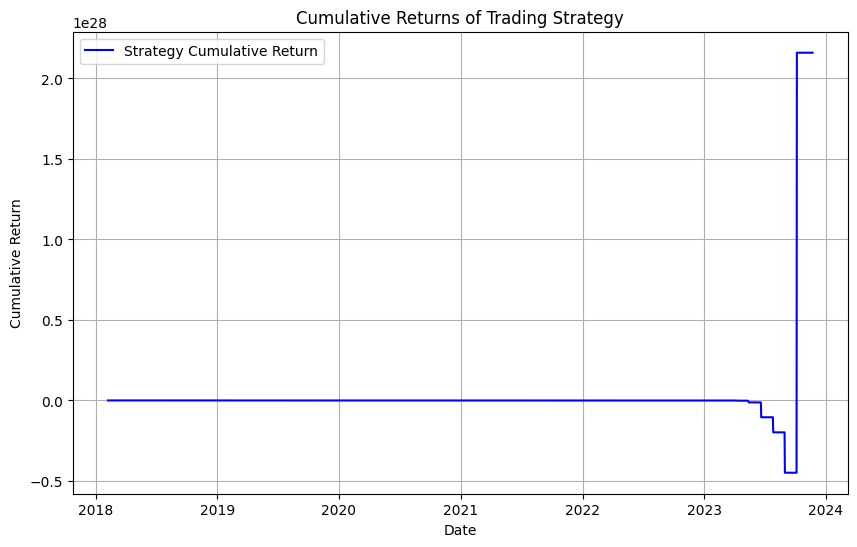

,0
Date,
2018-02-07,1.946042e+00
2018-02-08,1.946042e+00
2018-02-09,1.946042e+00
2018-02-12,1.946042e+00
2018-02-13,1.946042e+00
...,...
2023-11-16,2.159995e+28
2023-11-17,2.159995e+28
2023-11-20,2.159995e+28


In [122]:
plot_cumulative_returns(positions, df_actuals)

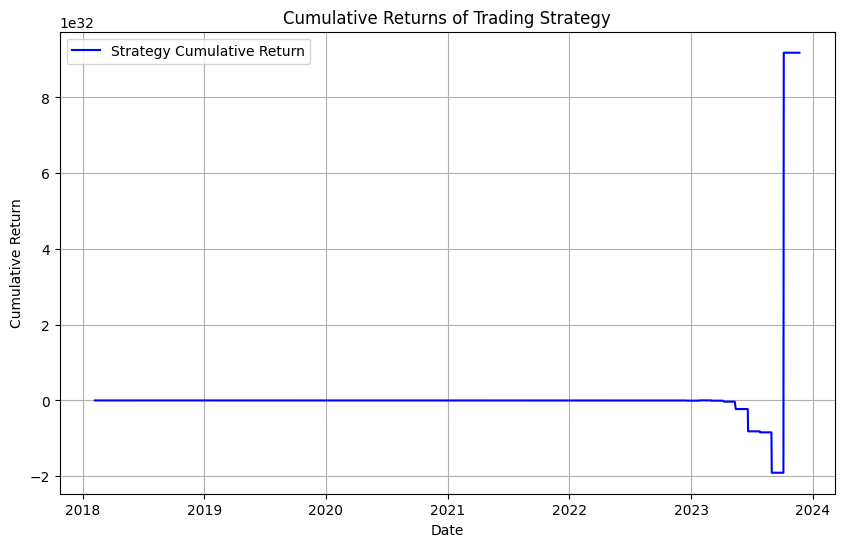

,0
Date,
2018-02-07,1.762053e+00
2018-02-08,1.762053e+00
2018-02-09,1.762053e+00
2018-02-12,1.762053e+00
2018-02-13,1.762053e+00
...,...
2023-11-16,9.182328e+32
2023-11-17,9.182328e+32
2023-11-20,9.182328e+32


In [123]:
plot_cumulative_returns(positions2, df_actuals2)

#Strategy2: Selecting Postive for Long and negative return for Short

In [124]:
def improved_trading_strategy(predictions, asset_names, rebalance_days=25, min_trend_threshold=0.02):
    """
    Trading strategy that selects the top 2 long and bottom 2 short assets while ensuring consistent indexing.

    Parameters:
    - predictions: DataFrame of predicted returns (index as DateTime)
    - asset_names: List of asset names
    - rebalance_days: Frequency of rebalancing (default: 25 days)
    - min_trend_threshold: Minimum absolute return required for an asset to be considered (default: 2%)

    Returns:
    - positions: DataFrame with long/short positions for each asset
    """
    predictions = predictions.apply(pd.to_numeric, errors='coerce')  # Ensure numeric values
    positions = pd.DataFrame(index=predictions.index, columns=asset_names).fillna(0)  # Initialize positions

    for i in range(0, len(predictions), rebalance_days):
        if i + rebalance_days > len(predictions):
            break  # Stop if out of bounds

        date = predictions.index[i]  # Ensure date index consistency
        pred_window = predictions.iloc[i]
        pred_window=pred_window[(pred_window > 0) | (pred_window < 0)]

        # Filter out low-return assets to avoid noise
        filtered_assets = pred_window[abs(pred_window) > min_trend_threshold]

        if len(filtered_assets) >= 4:  # Ensure at least 4 assets remain
            top_assets = filtered_assets.nlargest(2).index
            bottom_assets = filtered_assets.nsmallest(2).index
        else:
            top_assets = pred_window.nlargest(2).index
            bottom_assets = pred_window.nsmallest(2).index

        # Assign positions: +1 for long, -1 for short (equal weight)
        positions.loc[date, top_assets] = 1 / len(top_assets)
        positions.loc[date, bottom_assets] = -1/  len(bottom_assets)

    return positions

def plot_cumulative_returns2(positions, df_returns):
    """
    positions: DataFrame with strategy positions
    df_returns: DataFrame with actual asset returns

    Plots cumulative return of the strategy.
    """
    positions = positions.reindex(df_returns.index).fillna(0)  # Align and fill positions
    df_returns = df_returns.reindex(positions.index).fillna(0)
    positions_ff = positions.ffill()

    #portfolio_returns = (positions_ff.shift(1) * df_returns).sum(axis=1)
    portfolio_returns = (positions_ff * df_returns).sum(axis=1)
    cumulative_returns = (1 + portfolio_returns).cumprod()

    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_returns, label="Strategy Cumulative Return", color='b')
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.title("Cumulative Returns of Trading Strategy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [125]:

# Example Usage
positions3 = improved_trading_strategy(df_predictions2, ["SPY", "TLT", "SHY", "GLD", "DBO"])


<ipython-input-124-b40d993ce1e9>:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positions = pd.DataFrame(index=predictions.index, columns=asset_names).fillna(0)  # Initialize positions
<ipython-input-124-b40d993ce1e9>:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[date, top_assets] = 1 / len(top_assets)
<ipython-input-124-b40d993ce1e9>:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[date

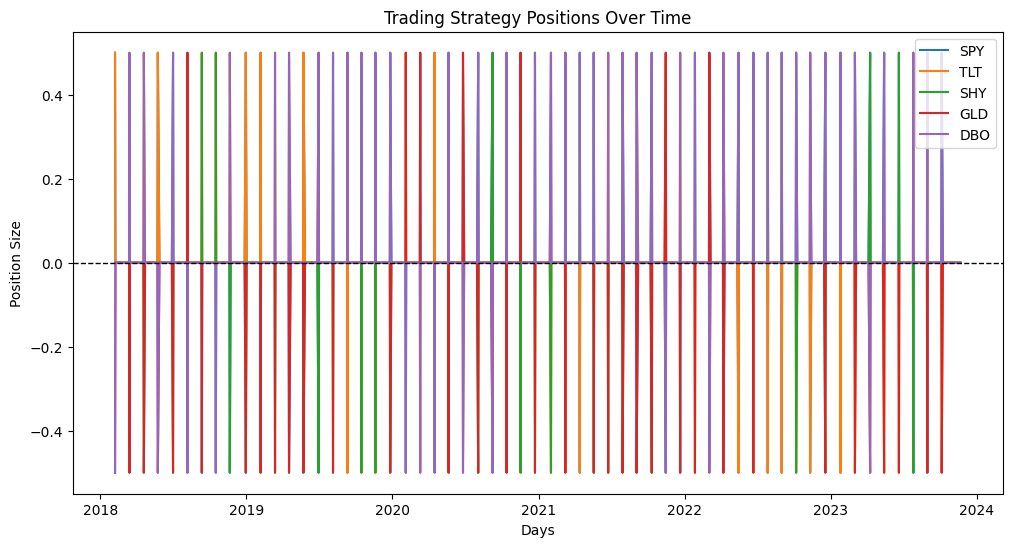

In [126]:
plot_positions(positions3)

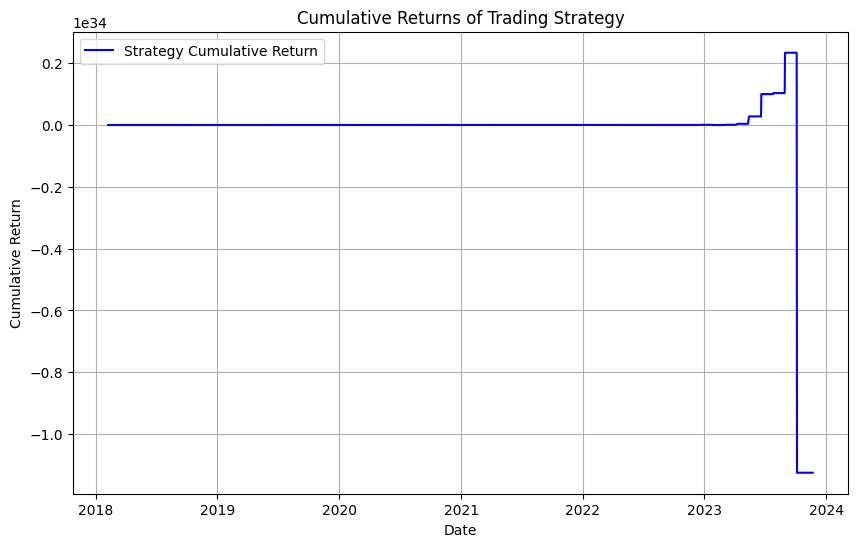

,0
Date,
2018-02-07,1.946042e+00
2018-02-08,1.946042e+00
2018-02-09,1.946042e+00
2018-02-12,1.946042e+00
2018-02-13,1.946042e+00
...,...
2023-11-16,-1.125160e+34
2023-11-17,-1.125160e+34
2023-11-20,-1.125160e+34


In [127]:
plot_cumulative_returns(positions3, df_actuals2)

## Strategy3: EArly Exit and USing threshold for volatility and trend

In [128]:
def early_exit_trading_strategy(predictions: pd.DataFrame, df_returns: pd.DataFrame, asset_names: list,
                                rebalance_days: int = 25, min_trend_threshold: float = 0.02,
                                min_volatility_threshold: float = 0.01, early_exit_threshold: float = 0.05):
    """
    Implements a trading strategy with early exits if an asset gains/losses more than a threshold before 25-day rebalance.
    """
    # Ensure all data is numeric
    predictions = predictions[asset_names].apply(pd.to_numeric, errors='coerce')
    df_returns = df_returns[asset_names].apply(pd.to_numeric, errors='coerce')

    # Initialize position tracking DataFrame
    positions = pd.DataFrame(index=predictions.index, columns=asset_names).fillna(0)
    rolling_volatility = df_returns.rolling(window=25).std()

    # Track active positions & entry prices
    dates = predictions.index.tolist()
    current_positions = pd.Series(0, index=asset_names)
    entry_prices = pd.Series(np.nan, index=asset_names)

    # Loop through each trading day
    for i in range(len(dates)):
        date = dates[i]
        pred_window = predictions.loc[date]

        # Compute rolling volatility and filter out low-volatility assets
        volatile_assets = rolling_volatility.loc[date]
        volatile_assets = volatile_assets[volatile_assets > min_volatility_threshold]

        # Select assets with strong predicted trends
        filtered_assets = pred_window[abs(pred_window) > min_trend_threshold]
        valid_assets = filtered_assets.index.intersection(volatile_assets.index)

        # Rebalance or adjust positions
        if i % rebalance_days == 0 or (entry_prices.notna().any()):
            if len(valid_assets) >= 4:
                top_assets = filtered_assets.loc[valid_assets].nlargest(2).index
                bottom_assets = filtered_assets.loc[valid_assets].nsmallest(2).index
            else:
                top_assets = pred_window.nlargest(2).index
                bottom_assets = pred_window.nsmallest(2).index

            # Assign new positions
            current_positions[top_assets] = 1 / len(top_assets)
            current_positions[bottom_assets] = -1 / len(bottom_assets)
            entry_prices[top_assets] = df_returns.loc[date, top_assets]
            entry_prices[bottom_assets] = df_returns.loc[date, bottom_assets]

        # Early exit logic: If return exceeds threshold before 25 days, exit position
        if entry_prices.notna().any():
            cumulative_returns = (df_returns.loc[date] - entry_prices)  # Change since entry
            exit_assets = cumulative_returns[abs(cumulative_returns) > early_exit_threshold].index

            if not exit_assets.empty:
                current_positions[exit_assets] = 0  # Exit position
                entry_prices[exit_assets] = np.nan  # Reset entry price

        # Store position for the day
        positions.loc[date] = current_positions

    return positions

In [129]:
# Example Usage
positions4 = early_exit_trading_strategy(df_predictions2,df_actuals2, ["SPY", "TLT", "SHY", "GLD", "DBO"])
positions4

<ipython-input-128-18d0aa5d7980>:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  positions = pd.DataFrame(index=predictions.index, columns=asset_names).fillna(0)
<ipython-input-128-18d0aa5d7980>:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  current_positions[top_assets] = 1 / len(top_assets)
<ipython-input-128-18d0aa5d7980>:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  positions.loc[date] = current_positions
<ipy

,SPY,TLT,SHY,GLD,DBO
Date,,,,,
2018-02-07,0.5,0.5,-0.5,0.0,-0.5
2018-02-08,0.5,0.5,-0.5,0.0,-0.5
2018-02-09,0.5,0.5,-0.5,0.0,-0.5
2018-02-12,0.5,0.5,-0.5,0.5,-0.5
2018-02-13,0.5,0.0,-0.5,0.5,-0.5
...,...,...,...,...,...
2023-11-16,0.5,0.0,0.5,-0.5,-0.5
2023-11-17,0.5,0.0,0.5,-0.5,-0.5
2023-11-20,0.5,-0.5,0.5,-0.5,0.0


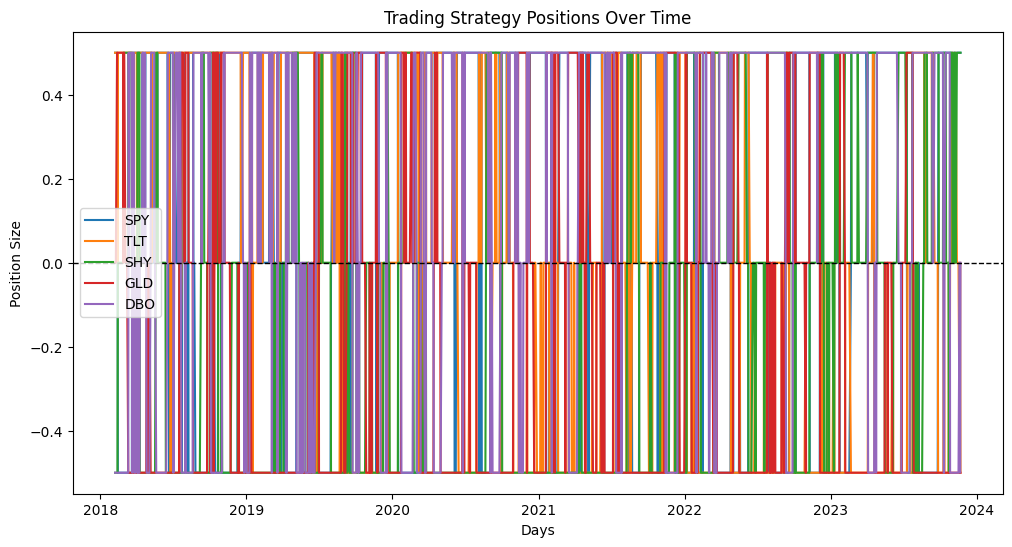

In [130]:
plot_positions(positions4)

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)
/usr/local/lib/python3.11/dist-packages/matplotlib/ticker.py:2176: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


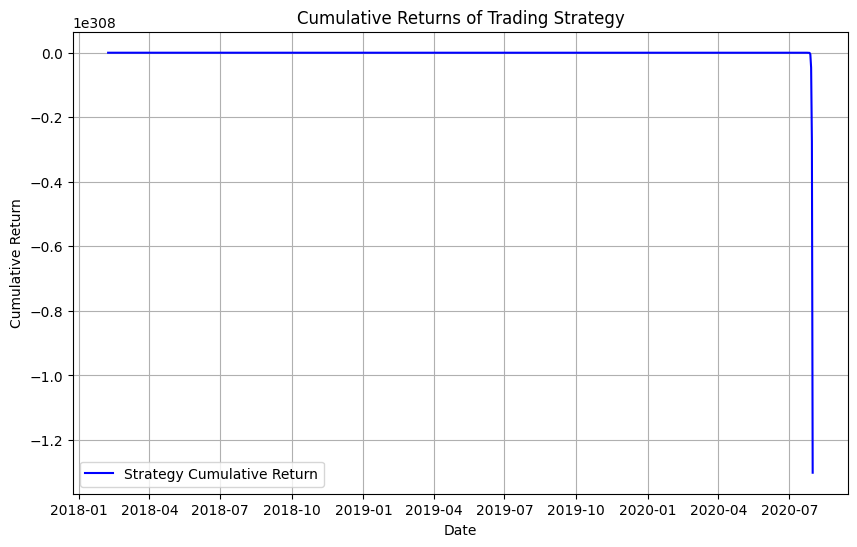

,0
Date,
2018-02-07,1.762053
2018-02-08,10.224912
2018-02-09,19.852227
2018-02-12,2.586618
2018-02-13,-5.296720
...,...
2023-11-16,inf
2023-11-17,inf
2023-11-20,-inf


In [131]:
plot_cumulative_returns(positions4, df_actuals2)

## Stratgey4: Buy and hold strategy

In [132]:
def buy_and_hold_no_rebal(df, initial_capital=1.0, weights=None):
    """
    df: DataFrame of daily returns for each asset (indexed by date).
    initial_capital: starting portfolio value.
    weights: dict or list of weights, e.g. {"SPY": 0.2, "TLT": 0.2, ...} or [0.2, 0.2, ...].
    """
    # If weights not provided, assume equal weighting among columns
    if weights is None:
        n_assets = df.shape[1]
        weights = np.repeat(1/n_assets, n_assets)
    elif isinstance(weights, dict):
        # Convert dict to list in same order as df columns
        weights = [weights[col] for col in df.columns]

    # Convert weights to np.array for easy math
    weights = np.array(weights)

    # Initial capital allocated to each asset
    asset_values = weights * initial_capital

    # Create a list to track total portfolio value over time
    portfolio_values = []

    for i, row in enumerate(df.values):
        if i == 0:
            # On the very first day, we already have asset_values
            portfolio_values.append(asset_values.sum())
        else:
            # Each asset grows by (1 + daily_return)
            asset_values = asset_values * (1.0 + row)
            # Record the total portfolio value
            portfolio_values.append(asset_values.sum())

    # Create a resulting DataFrame with daily portfolio value
    result = pd.DataFrame({
        "Portfolio_Value": portfolio_values
    }, index=df.index)

    # Compute daily and cumulative returns
    result["Daily_Return"] = result["Portfolio_Value"].pct_change().fillna(0.0)
    result["Cumulative_Return"] = (1 + result["Daily_Return"]).cumprod() - 1

    return result

# Example usage:
bh_result = buy_and_hold_no_rebal(df_actuals2)

<ipython-input-132-ae6f1444875b>:30: RuntimeWarning: overflow encountered in multiply
  asset_values = asset_values * (1.0 + row)
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
<ipython-input-132-ae6f1444875b>:40: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  result["Daily_Return"] = result["Portfolio_Value"].pct_change().fillna(0.0)


In [133]:
bh_result.head()

,Portfolio_Value,Daily_Return,Cumulative_Return
Date,,,
2018-02-07,1.000000,0.000000,0.000000
2018-02-08,2.535678,1.535678,1.535678
2018-02-09,9.851517,2.885161,8.851517
2018-02-12,36.212854,2.675866,35.212854
2018-02-13,146.121071,3.035061,145.121071


## Strategy: Monthly Rebalancing

In [134]:
def monthly_rebalance(df, initial_capital=1.0, weights=None, rebalance_freq="M"):
    """
    df: DataFrame of daily returns for each asset (indexed by date).
    initial_capital: starting portfolio value.
    weights: dict or list of weights (equal weighting by default).
    rebalance_freq: 'M' for monthly, 'Q' for quarterly, etc. (Pandas offset aliases).
    """
    if weights is None:
        n_assets = df.shape[1]
        weights = np.repeat(1/n_assets, n_assets)
    elif isinstance(weights, dict):
        # Convert dict to list in same order as df columns
        weights = [weights[col] for col in df.columns]
    weights = np.array(weights)

    # Group by year-month (or chosen frequency)
    # This creates groups of dates where rebalancing occurs at the *start* of each group
    df_groups = df.groupby(pd.Grouper(freq=rebalance_freq))

    portfolio_values = []
    current_portfolio_value = initial_capital
    asset_values = weights * current_portfolio_value

    # We’ll track the daily returns for final DataFrame
    daily_values = pd.DataFrame(index=df.index, columns=["Portfolio_Value", "Daily_Return"])

    # We will iterate group by group
    for _, group in df_groups:
        # On the *first day* of this group, we REBALANCE
        # Rebalance: set each asset to the fraction = weights * current_portfolio_value
        # But first, we need to ensure asset_values reflect any growth up to this date
        # Actually, if the group has at least 1 row, we treat the first row as the start
        # and subsequent days as "drifting"

        # We'll iterate daily within the group
        for i, (dt, row) in enumerate(group.iterrows()):
            if i == 0:
                # Rebalance at the start of the group
                current_portfolio_value = asset_values.sum()
                asset_values = weights * current_portfolio_value
            else:
                # Let it drift on subsequent days
                pass

            # Update asset_values by daily return
            asset_values = asset_values * (1.0 + row.values)
            current_portfolio_value = asset_values.sum()

            # Record daily portfolio value
            if i == 0:
                # The daily return is 0 on the rebalance day (comparing to prior day)
                # or you can skip the day-1 reference if it’s the very first date
                if daily_values.loc[dt, "Portfolio_Value"] is not np.nan:
                    # If it's not the very first day in the entire dataset, compute the daily return
                    prev_val = daily_values["Portfolio_Value"].ffill().iloc[-1]
                    daily_values.loc[dt, "Daily_Return"] = (current_portfolio_value / prev_val) - 1
                else:
                    daily_values.loc[dt, "Daily_Return"] = 0.0
            else:
                # For subsequent days, compare to previous day in the group
                prev_val = daily_values["Portfolio_Value"].ffill().iloc[-1]
                daily_values.loc[dt, "Daily_Return"] = (current_portfolio_value / prev_val) - 1

            daily_values.loc[dt, "Portfolio_Value"] = current_portfolio_value

    # Fill any missing portfolio_value forward
    daily_values["Portfolio_Value"] = daily_values["Portfolio_Value"].ffill()
    # Daily return also forward fill or fill with 0
    daily_values["Daily_Return"] = daily_values["Daily_Return"].fillna(0.0)

    # Compute cumulative return
    daily_values["Cumulative_Return"] = (1 + daily_values["Daily_Return"]).cumprod() - 1

    return daily_values

# Example usage:
monthly_result = monthly_rebalance(df_actuals2)

<ipython-input-134-5de3408eff87>:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_groups = df.groupby(pd.Grouper(freq=rebalance_freq))
<ipython-input-134-5de3408eff87>:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_val = daily_values["Portfolio_Value"].ffill().iloc[-1]
<ipython-input-134-5de3408eff87>:46: RuntimeWarning: overflow encountered in multiply
  asset_values = asset_values * (1.0 + row.values)
<ipython-input-134-5de3408eff87>:62: RuntimeWarning: invalid value encountered in scalar divide
  daily_values.loc[dt, "Daily_Return"] = (current_portfolio_value / prev_val) - 1
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return 

In [135]:
monthly_result.head()

,Portfolio_Value,Daily_Return,Cumulative_Return
Date,,,
2018-02-07,1.218654,0.000000,0.000000
2018-02-08,6.335167,4.198494,4.198494
2018-02-09,29.092396,3.592207,22.872559
2018-02-12,101.378058,2.484693,82.188531
2018-02-13,311.309446,2.070777,254.453457


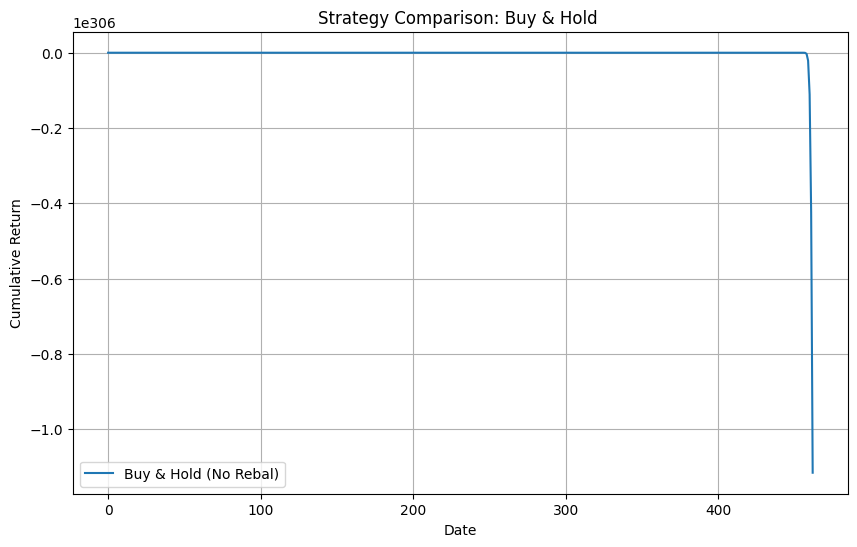

In [136]:
bh_result = bh_result.dropna()
bh_result_reset = bh_result.reset_index()
monthly_result = monthly_result.dropna()
monthly_result_reset = monthly_result.reset_index()
plt.figure(figsize=(10,6))
plt.plot(bh_result_reset.index, bh_result_reset["Cumulative_Return"]/100, label="Buy & Hold (No Rebal)")
#plt.plot(monthly_result_reset.index, monthly_result_reset["Cumulative_Return"], label="Monthly Rebal")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Strategy Comparison: Buy & Hold ")
plt.legend()
plt.grid(True)
plt.show()

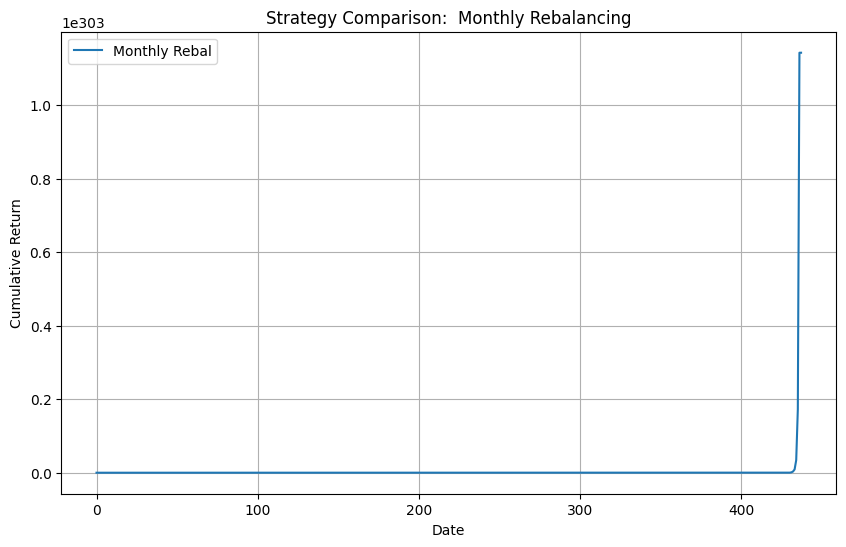

In [137]:
# bh_result = bh_result.dropna()
# bh_result_reset = bh_result.reset_index()
# monthly_result = monthly_result.dropna()
# monthly_result_reset = monthly_result.reset_index()
plt.figure(figsize=(10,6))
# plt.plot(bh_result_reset.index, bh_result_reset["Cumulative_Return"]/100, label="Buy & Hold (No Rebal)")
plt.plot(monthly_result_reset.index, monthly_result_reset["Cumulative_Return"], label="Monthly Rebal")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Strategy Comparison:  Monthly Rebalancing")
plt.legend()
plt.grid(True)
plt.show()

In [138]:
print(len(bh_result.index), len(bh_result["Cumulative_Return"]))

754 754


##Strategy: Take long positon for all Positive Return and Short for all negative retunrs

In [139]:
def predictive_strategy_backtest(act_returns, pred_returns, initial_capital=1.0):
    """
    act_returns: DataFrame of actual returns (daily) for each asset.
    pred_returns: DataFrame of predicted returns for each asset.
    The strategy: for each asset, if predicted return > 0, we take a long position (weight = +1/N),
              if predicted return <= 0, we either take a short position (weight = -1/N) or remain flat.
              (Here, for illustration, we assume a binary long/short signal.)
    """
    n_assets = act_returns.shape[1]
    # Define weights: equal weighting if long, negative equal weighting if short
    positions = pred_returns.copy() * 0  # initialize

    # Example rule: if predicted return > 0, long; else, short.
    # (You can modify this rule as needed.)
    for col in act_returns.columns:
        positions[col] = np.where(pred_returns[col] > 0, 1/n_assets, -1/n_assets)

    # Compute daily portfolio returns:
    # Multiply the positions with actual returns. Assume positions are taken at the start of the day.
    daily_strategy_return = (positions * act_returns).sum(axis=1)

    # Compute portfolio value over time
    portfolio_value = (1 + daily_strategy_return).cumprod()

    # Create a DataFrame for results
    result = pd.DataFrame({
        "Portfolio_Value": portfolio_value,
        "Daily_Return": daily_strategy_return,
        "Cumulative_Return": portfolio_value - 1
    }, index=act_returns.index)

    return result

# Run the predictive strategy backtest
pred_strategy_result = predictive_strategy_backtest(df_predictions2, df_actuals2)

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


In [140]:
pred_strategy_result.head()

,Portfolio_Value,Daily_Return,Cumulative_Return
Date,,,
2018-02-07,1.140155,0.140155,0.140155
2018-02-08,2.829492,1.481673,1.829492
2018-02-09,4.492630,0.587787,3.492630
2018-02-12,5.226470,0.163343,4.226470
2018-02-13,5.723426,0.095085,4.723426


## Step-3

a)

In [141]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

In [142]:
# Define a function to create the multi-output model
def create_multi_output_model(input_shapes):
    inputs = []
    lstm_layers = []

    # Create separate input and LSTM layers for each ETF
    for shape in input_shapes:
        input_layer = Input(shape=shape)
        lstm_layer = LSTM(50, return_sequences=False)(input_layer)
        inputs.append(input_layer)
        lstm_layers.append(lstm_layer)

    # Concatenate all the LSTM outputs
    concatenated = Concatenate()(lstm_layers)

    # Add dense layers on top of the concatenated output
    dense1 = Dense(50, activation='relu')(concatenated)
    dense2 = Dense(25, activation='relu')(dense1)

    # Create an output for each ETF
    outputs = []
    for _ in range(len(input_shapes)):
        outputs.append(Dense(1)(dense2))

    # Create the model
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Prepare the data for multi-output model
def prepare_data(returns, n_lags):
    X, y = [], []
    for i in range(len(returns) - n_lags):
        X.append(returns[i:i + n_lags])
        y.append(returns[i + n_lags])
    return np.array(X), np.array(y)

n_lags = 25
etf_symbols = ["SPY", "TLT", "SHY", "GLD", "DBO"]
etf_data = yf.download(etf_symbols, '2010-01-01', '2023-12-31')['Close']

[*********************100%***********************]  5 of 5 completed


b)

In [143]:
input_shapes = [(n_lags, 1) for _ in range(len(etf_symbols))]
X_data = []
y_data = []

for etf in etf_symbols:
    etf_returns = etf_data[etf].pct_change().dropna().values
    X, y = prepare_data(etf_returns, n_lags=n_lags)
    X_data.append(X)
    y_data.append(y)

# Convert lists to numpy arrays for training
X_data = [np.array(X) for X in X_data]
y_data = [np.array(y) for y in y_data]

# Spliting the data into training and testing sets (20% test size)
split_data_X = [train_test_split(X, test_size=0.2, shuffle=False) for X in X_data]
X_train = [X[0] for X in split_data_X]  # Extract training data
X_test = [X[1] for X in split_data_X]  # Extract testing data

split_data_y = [train_test_split(y, test_size=0.2, shuffle=False) for y in y_data]
y_train = [y[0] for y in split_data_y]
y_test = [y[1] for y in split_data_y]

# Creating multi-output model
multi_output_model = create_multi_output_model(input_shapes)

# Model Training
multi_output_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model (in-sample and out-of-sample)
in_sample_loss = multi_output_model.evaluate(X_train, y_train)
out_sample_loss = multi_output_model.evaluate(X_test, y_test)

print(f"In-Sample Loss (Multi-Output Model): {in_sample_loss}")
print(f"Out-of-Sample Loss (Multi-Output Model): {out_sample_loss}")

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - dense_16_loss: 1.1230e-04 - dense_17_loss: 8.7211e-05 - dense_18_loss: 3.1749e-06 - dense_19_loss: 1.0093e-04 - dense_20_loss: 3.5656e-04 - loss: 6.6016e-04 - val_dense_16_loss: 1.2442e-04 - val_dense_17_loss: 1.3113e-04 - val_dense_18_loss: 1.9744e-06 - val_dense_19_loss: 7.6950e-05 - val_dense_20_loss: 4.4499e-04 - val_loss: 7.8084e-04
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - dense_16_loss: 1.3174e-04 - dense_17_loss: 9.0479e-05 - dense_18_loss: 1.0958e-06 - dense_19_loss: 9.2506e-05 - dense_20_loss: 3.2620e-04 - loss: 6.4193e-04 - val_dense_16_loss: 1.3369e-04 - val_dense_17_loss: 1.3054e-04 - val_dense_18_loss: 1.9663e-06 - val_dense_19_loss: 7.6898e-05 - val_dense_20_loss: 4.4689e-04 - val_loss: 7.9127e-04
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - dense_16_loss: 1.3027e-04 - dense_17_loss: 8.8377e-05 - dense_18_loss: 1.6272e-06 - dense_19_loss: 1.0463e-04 - dense_20_loss: 3.4999e-04 - loss: 6.7490e-04 - 

c)

In [144]:
# Initialize portfolio returns
portfolio_returns_multi = []

# Loop over the out-of-sample period in steps of 25 days
for i in range(0, len(y_test[0]), 25):
    predictions = {}

    # Collect predictions from the multi-output model
    preds = multi_output_model.predict([X[i:i+25] for X in X_test])

    for j, etf in enumerate(etf_symbols):
        predictions[etf] = preds[j].mean()

    # Sort assets by predicted performance
    sorted_assets = sorted(predictions.items(), key=lambda x: x[1], reverse=True)

    # Go long on the top 2 and short the bottom 2
    long_assets = [x[0] for x in sorted_assets[:2]]
    short_assets = [x[0] for x in sorted_assets[-2:]]

    # Calculate portfolio return (simplified example)
    portfolio_return = (
        sum([y_test[etf_symbols.index(asset)][i:i+25].mean() for asset in long_assets])
        - sum([y_test[etf_symbols.index(asset)][i:i+25].mean() for asset in short_assets])
    )
    portfolio_returns_multi.append(portfolio_return)

# Convert portfolio returns to a DataFrame
portfolio_returns_multi = pd.DataFrame(portfolio_returns_multi, columns=["Portfolio Return"])
print(portfolio_returns_multi.describe())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━

d)

In [145]:
# Initialize portfolio returns
portfolio_returns_multi = []

# Loop over the out-of-sample period in steps of 25 days
for i in range(0, len(y_test[0]), 25):
    predictions = {}

    # Collect predictions from the multi-output model
    preds = multi_output_model.predict([X[i:i+25] for X in X_test])

    for j, etf in enumerate(etf_symbols):
        predictions[etf] = preds[j].mean()

    # Sort assets by predicted performance
    sorted_assets = sorted(predictions.items(), key=lambda x: x[1], reverse=True)

    # Go long on the top 3 and short the bottom 2
    long_assets = [x[0] for x in sorted_assets[:3]]
    short_assets = [x[0] for x in sorted_assets[-2:]]

    # Calculate portfolio return (simplified example)
    portfolio_return = (
        sum([y_test[etf_symbols.index(asset)][i:i+25].mean() for asset in long_assets])
        - sum([y_test[etf_symbols.index(asset)][i:i+25].mean() for asset in short_assets])
    )
    portfolio_returns_multi.append(portfolio_return)

# Convert portfolio returns to a DataFrame
portfolio_returns_df = pd.DataFrame(portfolio_returns_multi, columns=["Portfolio Return"])

# Print summary statistics for portfolio returns
print("Portfolio Returns Summary:")
print(portfolio_returns_df.describe())

# Calculate and print the final portfolio return
final_portfolio_return = portfolio_returns_df["Portfolio Return"].tail(1).values[0]
print(f"Final Portfolio Return: {final_portfolio_return}")

# Calculate Buy-and-Hold Returns for comparison
bh_returns = []
for symbol in etf_symbols:
    bh_ret = y_data[etf_symbols.index(symbol)].mean()  # Assuming y_data contains total returns
    bh_returns.append(bh_ret)

# Total Buy-and-Hold return
total_bh_return = sum(bh_returns)
print(f"Total Buy-and-Hold Return: {total_bh_return}")

# Compute and print additional performance metrics (optional)
# Mean return
mean_portfolio_return = portfolio_returns_df["Portfolio Return"].mean()
print(f"Mean Portfolio Return: {mean_portfolio_return}")

# Standard deviation
std_portfolio_return = portfolio_returns_df["Portfolio Return"].std()
print(f"Standard Deviation of Portfolio Return: {std_portfolio_return}")

# Sharpe Ratio (assuming risk-free rate is 0 for simplicity)
sharpe_ratio = mean_portfolio_return / std_portfolio_return if std_portfolio_return != 0 else np.nan
print(f"Sharpe Ratio: {sharpe_ratio}")

# Total returns comparison with Buy-and-Hold strategy
print(f"Portfolio vs Buy-and-Hold Return Comparison:")
print(f"Portfolio Return: {final_portfolio_return}")
print(f"Buy-and-Hold Return: {total_bh_return}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━